In [1]:
# ============================================================
# Notebook 12
# PHASE 1 FINAL SYNTHESIS
#
# Step 1: Project / artifact preflight
#
# PURPOSE
# -------
#
# Notebook 12 is the final Phase-1 synthesis notebook.
#
# It will NOT:
#
#   - train models
#   - tune hyperparameters
#   - select architectures
#   - modify frozen TEST predictions
#   - use TEST performance to redesign Phase-1 models
#
#
# Instead, it will:
#
#   1. Load already-saved artifacts from earlier notebooks.
#   2. Reconstruct the complete Phase-1 experiment.
#   3. Build master model / feature / horizon comparisons.
#   4. Synthesize F0 -> F4 ablations.
#   5. Treat F3 -> F4 as the core novelty comparison.
#   6. Combine all-row, daylight, and bootstrap evidence.
#   7. Produce final paper-ready tables and figures.
#   8. State supported conclusions and limitations.
#
#
# IMPORTANT
# ---------
#
# Phase-1 experimental results are FROZEN.
#
# Notebook 11 final checkpoint:
#
#   phase1-notebook11-final
#
# No model training occurs in this notebook.
# ============================================================


from pathlib import Path

import json
import platform

import numpy as np
import pandas as pd


print(
    "=" * 72
)

print(
    "NOTEBOOK 12 — PHASE 1 FINAL SYNTHESIS"
)

print(
    "STEP 1: PROJECT / ARTIFACT PREFLIGHT"
)

print(
    "=" * 72
)


# ============================================================
# 1. Locate the project root robustly
#
# The notebook may be launched from:
#
#   Project/
#
# or:
#
#   Project/notebooks/
#
# Therefore we search upward for a directory containing both:
#
#   notebooks/
#   results/
# ============================================================

def find_project_root(
    start_path,
):
    """
    Search the current path and its parents for the project
    directory containing both 'notebooks' and 'results'.
    """

    start_path = (
        Path(
            start_path
        )
        .resolve()
    )


    candidates = [
        start_path,
        *start_path.parents,
    ]


    for candidate in (
        candidates
    ):

        notebooks_candidate = (
            candidate
            /
            "notebooks"
        )


        results_candidate = (
            candidate
            /
            "results"
        )


        if (
            notebooks_candidate.exists()
            and
            results_candidate.exists()
        ):

            return candidate


    raise FileNotFoundError(
        "Could not locate project root containing both "
        "'notebooks/' and 'results/'."
    )


PROJECT_ROOT = find_project_root(
    Path.cwd()
)


NOTEBOOKS_DIR = (
    PROJECT_ROOT
    /
    "notebooks"
)


RESULTS_DIR = (
    PROJECT_ROOT
    /
    "results"
)


# ============================================================
# 2. Create a dedicated Notebook 12 output directory
#
# This directory will contain synthesis artifacts ONLY.
#
# Earlier notebook outputs remain untouched.
# ============================================================

NOTEBOOK12_RESULTS_DIR = (
    RESULTS_DIR
    /
    "notebook12_phase1_final_synthesis"
)


NOTEBOOK12_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


print(
    "\nProject root:"
)

print(
    " ",
    PROJECT_ROOT,
)


print(
    "\nNotebook directory:"
)

print(
    " ",
    NOTEBOOKS_DIR,
)


print(
    "\nResults root:"
)

print(
    " ",
    RESULTS_DIR,
)


print(
    "\nNotebook 12 output directory:"
)

print(
    " ",
    NOTEBOOK12_RESULTS_DIR,
)


# ============================================================
# 3. Freeze Notebook 12 scientific policy
# ============================================================

NOTEBOOK12_PROTOCOL = {

    "phase":
        "Phase 1 final synthesis",


    "training_allowed":
        False,


    "hyperparameter_tuning_allowed":
        False,


    "architecture_selection_allowed":
        False,


    "test_driven_model_redesign_allowed":
        False,


    "prediction_clipping_allowed":
        False,


    "primary_forecast_target":
        "P_Solar",


    "forecast_horizons_minutes": [
        15,
        30,
        60,
    ],


    "feature_families": [
        "F0",
        "F1",
        "F2",
        "F3",
        "F4",
    ],


    "core_novelty_comparison":
        "F3 -> F4",


    "core_novelty_interpretation":
        (
            "Categorical Panchang representation beyond "
            "continuous lunar / Sun-Moon astronomical controls"
        ),


    "daylight_definition":
        "valid-time solar elevation > 0 degrees",


    "primary_metrics": [
        "MAE",
        "RMSE",
        "R2",
    ],


    "causal_claim_allowed":
        False,


    "cross_architecture_effect_size_averaging":
        False,


    "notebook11_frozen_git_tag":
        "phase1-notebook11-final",
}


print(
    "\nNotebook 12 scientific policy:"
)


display(
    pd.DataFrame(
        [
            NOTEBOOK12_PROTOCOL
        ]
    )
)


# ============================================================
# 4. Inventory top-level result directories
#
# This is deliberately discovery-only.
#
# We do NOT assume the output-folder names from earlier
# notebooks. The next cells will use this inventory to locate
# the canonical Phase-1 artifacts.
# ============================================================

result_directory_rows = []


for path in sorted(
    RESULTS_DIR.iterdir()
):

    if not path.is_dir():

        continue


    files = [
        file_path

        for file_path in path.rglob(
            "*"
        )

        if file_path.is_file()
    ]


    total_bytes = int(
        sum(
            file_path.stat().st_size

            for file_path in (
                files
            )
        )
    )


    result_directory_rows.append(
        {
            "directory":
                path.name,

            "file_count":
                len(
                    files
                ),

            "total_size_MB":
                (
                    total_bytes
                    /
                    (
                        1024
                        **
                        2
                    )
                ),
        }
    )


result_directory_inventory = pd.DataFrame(
    result_directory_rows
)


if not result_directory_inventory.empty:

    result_directory_inventory = (
        result_directory_inventory
        .sort_values(
            "directory"
        )
        .reset_index(
            drop=True
        )
    )


print(
    "\n"
    +
    "=" * 72
)

print(
    "PHASE-1 RESULTS DIRECTORY INVENTORY"
)

print(
    "=" * 72
)


display(
    result_directory_inventory
)


# ============================================================
# 5. Inventory existing notebooks
#
# This helps establish exactly which notebooks constitute
# Phase 1 before we build the master synthesis.
# ============================================================

notebook_inventory = sorted(
    [
        path.name

        for path in (
            NOTEBOOKS_DIR.glob(
                "*.ipynb"
            )
        )
    ]
)


print(
    "\n"
    +
    "=" * 72
)

print(
    "NOTEBOOK INVENTORY"
)

print(
    "=" * 72
)


for notebook_name in (
    notebook_inventory
):

    print(
        " ",
        notebook_name
    )


# ============================================================
# 6. Verify Notebook 11 final synthesis inputs
#
# Notebook 11 is our most recent frozen experimental stage.
# These key files must exist before Phase-1 synthesis begins.
# ============================================================

NOTEBOOK11_RESULTS_DIR = (
    RESULTS_DIR
    /
    "notebook11_deep_learning_models"
)


NOTEBOOK11_REQUIRED_INPUTS = [

    "notebook11_final_result_matrix.csv",

    "lstm_gru_bilstm_tcn_f3_f4_comparison.csv",

    "lstm_gru_bilstm_tcn_f3_f4_consensus.csv",

    "notebook11_frozen_epoch_matrix.csv",

    "notebook11_environment_versions.csv",

    "notebook11_final_reproducibility_audit.json",
]


notebook11_input_audit_rows = []


for filename in (
    NOTEBOOK11_REQUIRED_INPUTS
):

    file_path = (
        NOTEBOOK11_RESULTS_DIR
        /
        filename
    )


    notebook11_input_audit_rows.append(
        {
            "artifact":
                filename,

            "exists":
                file_path.exists(),

            "bytes":
                (
                    file_path.stat().st_size
                    if file_path.exists()
                    else
                    0
                ),
        }
    )


notebook11_input_audit = pd.DataFrame(
    notebook11_input_audit_rows
)


print(
    "\n"
    +
    "=" * 72
)

print(
    "NOTEBOOK 11 FROZEN INPUT AUDIT"
)

print(
    "=" * 72
)


display(
    notebook11_input_audit
)


assert (
    notebook11_input_audit[
        "exists"
    ]
    .all()
), (
    "One or more required frozen Notebook 11 artifacts "
    "are missing."
)


assert (
    (
        notebook11_input_audit[
            "bytes"
        ]
        >
        0
    )
    .all()
)


# ============================================================
# 7. Environment checkpoint
# ============================================================

print(
    "\n"
    +
    "=" * 72
)

print(
    "NOTEBOOK 12 ENVIRONMENT CHECKPOINT"
)

print(
    "=" * 72
)


print(
    "Python:",
    platform.python_version(),
)


print(
    "NumPy:",
    np.__version__,
)


print(
    "pandas:",
    pd.__version__,
)


# ============================================================
# 8. Final preflight checkpoint
# ============================================================

print(
    "\n"
    +
    "=" * 72
)

print(
    "NOTEBOOK 12 PREFLIGHT: PASSED"
)

print(
    "=" * 72
)


print(
    "Project root located: YES"
)


print(
    "Results directory located: YES"
)


print(
    "Notebook 12 results directory ready: YES"
)


print(
    "Notebook 11 frozen inputs available: YES"
)


print(
    "Model training permitted: NO"
)


print(
    "Hyperparameter tuning permitted: NO"
)


print(
    "TEST-driven redesign permitted: NO"
)


print(
    "\nNext step:"
)


print(
    "Map all previous Phase-1 notebook/result artifacts "
    "and identify the canonical inputs for the master synthesis."
)

NOTEBOOK 12 — PHASE 1 FINAL SYNTHESIS
STEP 1: PROJECT / ARTIFACT PREFLIGHT

Project root:
  /Users/siddharthgupta/Downloads/NSUT/Semester 1/MTITC102 AI and Machine Learning/Project

Notebook directory:
  /Users/siddharthgupta/Downloads/NSUT/Semester 1/MTITC102 AI and Machine Learning/Project/notebooks

Results root:
  /Users/siddharthgupta/Downloads/NSUT/Semester 1/MTITC102 AI and Machine Learning/Project/results

Notebook 12 output directory:
  /Users/siddharthgupta/Downloads/NSUT/Semester 1/MTITC102 AI and Machine Learning/Project/results/notebook12_phase1_final_synthesis

Notebook 12 scientific policy:


,phase,training_allowed,hyperparameter_tuning_allowed,architecture_selection_allowed,test_driven_model_redesign_allowed,prediction_clipping_allowed,primary_forecast_target,forecast_horizons_minutes,feature_families,core_novelty_comparison,core_novelty_interpretation,daylight_definition,primary_metrics,causal_claim_allowed,cross_architecture_effect_size_averaging,notebook11_frozen_git_tag
0,Phase 1 final synthesis,False,False,False,False,False,P_Solar,"[15, 30, 60]","[F0, F1, F2, F3, F4]",F3 -> F4,Categorical Panchang representation beyond con...,valid-time solar elevation > 0 degrees,"[MAE, RMSE, R2]",False,False,phase1-notebook11-final



PHASE-1 RESULTS DIRECTORY INVENTORY


,directory,file_count,total_size_MB
0,notebook09_primary_experiment,14,24.779773
1,notebook10_secondary_ml_models,48,72.189632
2,notebook11_deep_learning_models,331,87.028464
3,notebook12_phase1_final_synthesis,0,0.000000



NOTEBOOK INVENTORY
  01_eda_60min.ipynb
  02_eda_5min.ipynb
  03_eda_1min.ipynb
  04_eda_1sec.ipynb
  05_cross_resolution_comparison.ipynb
  06_preprocessing_feature_engineering.ipynb
  07_astronomical_feature_engineering.ipynb
  08_vedic_calendar_features.ipynb
  09_modelling_dataset_and_protocol.ipynb
  10_secondary_ml_models.ipynb
  11_deep_learning_models.ipynb
  12_phase1_final_synthesis.ipynb

NOTEBOOK 11 FROZEN INPUT AUDIT


,artifact,exists,bytes
0,notebook11_final_result_matrix.csv,True,5051
1,lstm_gru_bilstm_tcn_f3_f4_comparison.csv,True,2282
2,lstm_gru_bilstm_tcn_f3_f4_consensus.csv,True,580
3,notebook11_frozen_epoch_matrix.csv,True,262
4,notebook11_environment_versions.csv,True,187
5,notebook11_final_reproducibility_audit.json,True,1761



NOTEBOOK 12 ENVIRONMENT CHECKPOINT
Python: 3.12.14
NumPy: 2.0.2
pandas: 3.0.5

NOTEBOOK 12 PREFLIGHT: PASSED
Project root located: YES
Results directory located: YES
Notebook 12 results directory ready: YES
Notebook 11 frozen inputs available: YES
Model training permitted: NO
Hyperparameter tuning permitted: NO
TEST-driven redesign permitted: NO

Next step:
Map all previous Phase-1 notebook/result artifacts and identify the canonical inputs for the master synthesis.


In [2]:
# ============================================================
# Notebook 12
# Step 2: Map frozen Phase-1 result artifacts
#
# PURPOSE
# -------
#
# Identify the VERSION-CONTROLLED result artifacts produced by:
#
#       Notebook 09 — primary experiment
#       Notebook 10 — secondary ML models
#       Notebook 11 — deep-learning models
#
#
# Why use Git-tracked artifacts?
# ------------------------------
#
# Notebook 11 also contains large LOCAL reproducibility files:
#
#       *_predictions.csv
#       *_test_alignment.csv
#       bootstrap replicate/distribution files
#
# These were intentionally excluded from Git.
#
# Notebook 12 should preferentially synthesize from frozen,
# version-controlled summary artifacts rather than depending
# on those local intermediate files.
#
#
# This cell:
#
#       - performs NO training
#       - modifies NO previous result
#       - makes NO model-selection decision
#
# It only inventories and inspects artifacts.
# ============================================================


import subprocess
from pathlib import Path

import pandas as pd


print(
    "=" * 76
)

print(
    "NOTEBOOK 12 — STEP 2"
)

print(
    "FROZEN PHASE-1 ARTIFACT MAPPING"
)

print(
    "=" * 76
)


# ============================================================
# 1. Result directories that contain the experimental phases
# ============================================================

PHASE1_RESULT_DIRECTORIES = {

    "Notebook 09":
        RESULTS_DIR
        /
        "notebook09_primary_experiment",

    "Notebook 10":
        RESULTS_DIR
        /
        "notebook10_secondary_ml_models",

    "Notebook 11":
        RESULTS_DIR
        /
        "notebook11_deep_learning_models",
}


for (
    notebook_label,
    directory_path,
) in PHASE1_RESULT_DIRECTORIES.items():

    assert (
        directory_path.exists()
    ), (
        f"Missing result directory for "
        f"{notebook_label}: {directory_path}"
    )


print(
    "Phase-1 result directories: FOUND"
)


# ============================================================
# 2. Verify that the current project is a Git repository
# ============================================================

git_root = Path(
    subprocess.check_output(
        [
            "git",
            "rev-parse",
            "--show-toplevel",
        ],
        cwd=
            PROJECT_ROOT,
        text=True,
    ).strip()
).resolve()


assert (
    git_root
    ==
    PROJECT_ROOT.resolve()
)


print(
    "Git repository root verified:",
    git_root,
)


# ============================================================
# 3. Retrieve only VERSION-CONTROLLED result artifacts
#
# This deliberately excludes ignored local files.
# ============================================================

tracked_result_files = []


for (
    notebook_label,
    directory_path,
) in PHASE1_RESULT_DIRECTORIES.items():

    relative_directory = (
        directory_path
        .relative_to(
            PROJECT_ROOT
        )
    )


    git_output = subprocess.check_output(
        [
            "git",
            "ls-files",
            str(
                relative_directory
            ),
        ],
        cwd=
            PROJECT_ROOT,
        text=True,
    )


    tracked_paths = [
        PROJECT_ROOT
        /
        line.strip()

        for line in (
            git_output.splitlines()
        )

        if line.strip()
    ]


    for file_path in (
        tracked_paths
    ):

        assert (
            file_path.exists()
        ), (
            f"Tracked artifact missing locally: "
            f"{file_path}"
        )


        tracked_result_files.append(
            {
                "source_notebook":
                    notebook_label,

                "file_path":
                    file_path,

                "relative_path":
                    str(
                        file_path.relative_to(
                            PROJECT_ROOT
                        )
                    ),

                "filename":
                    file_path.name,

                "suffix":
                    file_path.suffix.lower(),

                "bytes":
                    int(
                        file_path.stat().st_size
                    ),

                "size_KB":
                    (
                        file_path.stat().st_size
                        /
                        1024.0
                    ),
            }
        )


tracked_artifact_inventory = pd.DataFrame(
    tracked_result_files
)


assert (
    not
    tracked_artifact_inventory.empty
)


# ============================================================
# 4. Count tracked artifacts by notebook
# ============================================================

tracked_counts = (
    tracked_artifact_inventory
    .groupby(
        "source_notebook"
    )
    .agg(
        tracked_files=(
            "filename",
            "count",
        ),

        tracked_size_MB=(
            "bytes",
            lambda values:
                values.sum()
                /
                (
                    1024
                    **
                    2
                ),
        ),
    )
    .reset_index()
)


print(
    "\n"
    +
    "=" * 76
)

print(
    "VERSION-CONTROLLED RESULT COUNTS"
)

print(
    "=" * 76
)


display(
    tracked_counts
)


# ============================================================
# 5. Inspect ALL Notebook 09 tracked artifacts
#
# Notebook 09 has only a small number of files, so we show
# everything.
# ============================================================

notebook09_inventory = (
    tracked_artifact_inventory.loc[
        tracked_artifact_inventory[
            "source_notebook"
        ]
        ==
        "Notebook 09"
    ][
        [
            "filename",
            "suffix",
            "size_KB",
        ]
    ]
    .sort_values(
        "filename"
    )
    .reset_index(
        drop=True
    )
)


print(
    "\n"
    +
    "=" * 76
)

print(
    "NOTEBOOK 09 — ALL TRACKED RESULT ARTIFACTS"
)

print(
    "=" * 76
)


display(
    notebook09_inventory
)


# ============================================================
# 6. Inspect ALL Notebook 10 tracked artifacts
#
# There are more than Notebook 09, but still few enough that
# seeing the filenames is useful for identifying the canonical
# secondary-ML result files.
# ============================================================

notebook10_inventory = (
    tracked_artifact_inventory.loc[
        tracked_artifact_inventory[
            "source_notebook"
        ]
        ==
        "Notebook 10"
    ][
        [
            "filename",
            "suffix",
            "size_KB",
        ]
    ]
    .sort_values(
        "filename"
    )
    .reset_index(
        drop=True
    )
)


print(
    "\n"
    +
    "=" * 76
)

print(
    "NOTEBOOK 10 — ALL TRACKED RESULT ARTIFACTS"
)

print(
    "=" * 76
)


display(
    notebook10_inventory
)


# ============================================================
# 7. Notebook 11:
#
# It contains hundreds of compact tracked artifacts.
# Instead of printing all of them, identify likely FINAL /
# CONSOLIDATED / PUBLICATION / AUDIT artifacts.
# ============================================================

CANONICAL_NAME_TOKENS = [

    "final",

    "complete",

    "summary",

    "comparison",

    "consensus",

    "publication",

    "result_matrix",

    "frozen_epoch",

    "reproducibility",

    "environment",

    "selected_architecture",

    "ablation",
]


def likely_canonical_artifact(
    filename,
):

    filename_lower = (
        filename.lower()
    )


    return any(
        token
        in
        filename_lower

        for token in (
            CANONICAL_NAME_TOKENS
        )
    )


notebook11_canonical_candidates = (
    tracked_artifact_inventory.loc[
        (
            tracked_artifact_inventory[
                "source_notebook"
            ]
            ==
            "Notebook 11"
        )
        &
        (
            tracked_artifact_inventory[
                "filename"
            ]
            .map(
                likely_canonical_artifact
            )
        )
    ][
        [
            "filename",
            "suffix",
            "size_KB",
        ]
    ]
    .sort_values(
        "filename"
    )
    .reset_index(
        drop=True
    )
)


print(
    "\n"
    +
    "=" * 76
)

print(
    "NOTEBOOK 11 — LIKELY CANONICAL / FINAL ARTIFACTS"
)

print(
    "=" * 76
)


display(
    notebook11_canonical_candidates
)


# ============================================================
# 8. Inspect CSV schemas WITHOUT loading full datasets
#
# We inspect only:
#
#       Notebook 09 CSVs
#       Notebook 10 CSVs
#
# plus the key final Notebook 11 CSVs.
#
# pd.read_csv(..., nrows=0) reads only the header.
# ============================================================

NOTEBOOK11_KEY_CSVS = [

    "notebook11_final_result_matrix.csv",

    "lstm_gru_bilstm_tcn_f3_f4_comparison.csv",

    "lstm_gru_bilstm_tcn_f3_f4_consensus.csv",

    "notebook11_frozen_epoch_matrix.csv",

    "notebook11_publication_f3_f4_table.csv",

    "notebook11_publication_architecture_summary.csv",

    "notebook11_publication_condition_summary.csv",
]


schema_candidate_paths = []


# ------------------------------------------------------------
# Every tracked CSV from Notebook 09 and Notebook 10.
# ------------------------------------------------------------

for notebook_label in [
    "Notebook 09",
    "Notebook 10",
]:

    matching_rows = (
        tracked_artifact_inventory.loc[
            (
                tracked_artifact_inventory[
                    "source_notebook"
                ]
                ==
                notebook_label
            )
            &
            (
                tracked_artifact_inventory[
                    "suffix"
                ]
                ==
                ".csv"
            )
        ]
    )


    for file_path in (
        matching_rows[
            "file_path"
        ]
    ):

        schema_candidate_paths.append(
            (
                notebook_label,
                file_path,
            )
        )


# ------------------------------------------------------------
# Only selected canonical Notebook 11 CSVs.
# ------------------------------------------------------------

for filename in (
    NOTEBOOK11_KEY_CSVS
):

    file_path = (
        NOTEBOOK11_RESULTS_DIR
        /
        filename
    )


    assert (
        file_path.exists()
    )


    schema_candidate_paths.append(
        (
            "Notebook 11",
            file_path,
        )
    )


# ============================================================
# 9. Build schema table
# ============================================================

schema_rows = []


for (
    notebook_label,
    file_path,
) in schema_candidate_paths:

    try:

        header = pd.read_csv(
            file_path,
            nrows=0,
        )


        columns = list(
            header.columns
        )


        schema_status = (
            "readable"
        )


    except Exception as exc:

        columns = []

        schema_status = (
            f"ERROR: "
            f"{type(exc).__name__}"
        )


    schema_rows.append(
        {
            "source_notebook":
                notebook_label,

            "filename":
                file_path.name,

            "schema_status":
                schema_status,

            "column_count":
                len(
                    columns
                ),

            "columns":
                " | ".join(
                    columns
                ),
        }
    )


phase1_csv_schema_inventory = pd.DataFrame(
    schema_rows
)


# ============================================================
# 10. Display Notebook 09 schemas
# ============================================================

print(
    "\n"
    +
    "=" * 76
)

print(
    "NOTEBOOK 09 — CSV SCHEMAS"
)

print(
    "=" * 76
)


display(
    phase1_csv_schema_inventory.loc[
        phase1_csv_schema_inventory[
            "source_notebook"
        ]
        ==
        "Notebook 09"
    ]
    .reset_index(
        drop=True
    )
)


# ============================================================
# 11. Display Notebook 10 schemas
# ============================================================

print(
    "\n"
    +
    "=" * 76
)

print(
    "NOTEBOOK 10 — CSV SCHEMAS"
)

print(
    "=" * 76
)


display(
    phase1_csv_schema_inventory.loc[
        phase1_csv_schema_inventory[
            "source_notebook"
        ]
        ==
        "Notebook 10"
    ]
    .reset_index(
        drop=True
    )
)


# ============================================================
# 12. Display key Notebook 11 schemas
# ============================================================

print(
    "\n"
    +
    "=" * 76
)

print(
    "NOTEBOOK 11 — KEY FINAL CSV SCHEMAS"
)

print(
    "=" * 76
)


display(
    phase1_csv_schema_inventory.loc[
        phase1_csv_schema_inventory[
            "source_notebook"
        ]
        ==
        "Notebook 11"
    ]
    .reset_index(
        drop=True
    )
)


# ============================================================
# 13. Persist the discovery inventories
#
# These become part of Notebook 12's reproducibility record.
# ============================================================

tracked_inventory_path = (
    NOTEBOOK12_RESULTS_DIR
    /
    "phase1_tracked_artifact_inventory.csv"
)


schema_inventory_path = (
    NOTEBOOK12_RESULTS_DIR
    /
    "phase1_csv_schema_inventory.csv"
)


tracked_artifact_inventory[
    [
        "source_notebook",
        "relative_path",
        "filename",
        "suffix",
        "bytes",
        "size_KB",
    ]
].to_csv(
    tracked_inventory_path,
    index=False,
)


phase1_csv_schema_inventory.to_csv(
    schema_inventory_path,
    index=False,
)


assert (
    tracked_inventory_path.exists()
)


assert (
    schema_inventory_path.exists()
)


# ============================================================
# 14. Final checkpoint
# ============================================================

print(
    "\n"
    +
    "=" * 76
)

print(
    "PHASE-1 ARTIFACT MAPPING: COMPLETE"
)

print(
    "=" * 76
)


print(
    "Notebook 09 tracked files:",
    int(
        tracked_counts.loc[
            tracked_counts[
                "source_notebook"
            ]
            ==
            "Notebook 09",
            "tracked_files",
        ].iloc[
            0
        ]
    ),
)


print(
    "Notebook 10 tracked files:",
    int(
        tracked_counts.loc[
            tracked_counts[
                "source_notebook"
            ]
            ==
            "Notebook 10",
            "tracked_files",
        ].iloc[
            0
        ]
    ),
)


print(
    "Notebook 11 tracked files:",
    int(
        tracked_counts.loc[
            tracked_counts[
                "source_notebook"
            ]
            ==
            "Notebook 11",
            "tracked_files",
        ].iloc[
            0
        ]
    ),
)


print(
    "\nLocal ignored Notebook 11 intermediates used "
    "as canonical synthesis inputs: NO"
)


print(
    "Previous results modified: NO"
)


print(
    "Model training performed: NO"
)


print(
    "\nArtifacts written:"
)


print(
    " ",
    tracked_inventory_path,
)


print(
    " ",
    schema_inventory_path,
)


print(
    "\nNext step:"
)


print(
    "Select the exact canonical Notebook 09 / 10 / 11 "
    "result tables and construct the Phase-1 master model inventory."
)

NOTEBOOK 12 — STEP 2
FROZEN PHASE-1 ARTIFACT MAPPING
Phase-1 result directories: FOUND
Git repository root verified: /Users/siddharthgupta/Downloads/NSUT/Semester 1/MTITC102 AI and Machine Learning/Project

VERSION-CONTROLLED RESULT COUNTS


,source_notebook,tracked_files,tracked_size_MB
0,Notebook 09,14,24.779773
1,Notebook 10,48,72.189632
2,Notebook 11,264,1.708883



NOTEBOOK 09 — ALL TRACKED RESULT ARTIFACTS


,filename,suffix,size_KB
0,baseline_results.csv,.csv,4.729492
1,experiment_protocol.json,.json,1.920898
2,final_f3_f4_test_summary.csv,.csv,0.934570
3,final_test_predictions_15min.csv,.csv,7614.449219
4,final_test_predictions_30min.csv,.csv,7600.750000
5,final_test_predictions_60min.csv,.csv,7586.372070
6,final_test_results.csv,.csv,9.466797
7,frozen_model_selection.csv,.csv,2.228516
8,hgbr_validation_selected.csv,.csv,2.330078
9,paired_block_bootstrap_distributions.csv.gz,.gz,2544.804688



NOTEBOOK 10 — ALL TRACKED RESULT ARTIFACTS


...


NOTEBOOK 10 — CSV SCHEMAS


,source_notebook,filename,schema_status,column_count,columns
0,Notebook 10,extra_trees_bootstrap_summary.csv,readable,13,model | horizon_minutes | scope | n_test_rows ...
1,Notebook 10,extra_trees_f3_f4_test_summary.csv,readable,7,horizon_minutes | f3_test_mae | f4_test_mae | ...
2,Notebook 10,extra_trees_final_test_results.csv,readable,21,model | horizon_minutes | feature_family | n_f...
3,Notebook 10,extra_trees_frozen_selection.csv,readable,9,horizon_minutes | feature_family | n_features ...
4,Notebook 10,extra_trees_results_manifest.csv,readable,3,filename | size_bytes | size_kb
5,Notebook 10,extra_trees_test_predictions_15min.csv,readable,9,issue_time | valid_time | daylight | target_P_...
6,Notebook 10,extra_trees_test_predictions_30min.csv,readable,9,issue_time | valid_time | daylight | target_P_...
7,Notebook 10,extra_trees_test_predictions_60min.csv,readable,9,issue_time | valid_time | daylight | target_P_...
8,Notebook 10,extra_trees_validation_summary.csv,readable,10,horizon_minutes | feature_family | n_features ...
9,Notebook 10,lightgbm_bootstrap_summary.csv,readable,15,model | horizon_minutes | scope | n_test_rows ...



NOTEBOOK 11 — KEY FINAL CSV SCHEMAS


,source_notebook,filename,schema_status,column_count,columns
0,Notebook 11,notebook11_final_result_matrix.csv,readable,9,model | horizon_minutes | feature_family | fro...
1,Notebook 11,lstm_gru_bilstm_tcn_f3_f4_comparison.csv,readable,8,model | horizon_minutes | scope | F3_to_F4_MAE...
2,Notebook 11,lstm_gru_bilstm_tcn_f3_f4_consensus.csv,readable,13,horizon_minutes | scope | models_compared | po...
3,Notebook 11,notebook11_frozen_epoch_matrix.csv,readable,7,model | horizon_minutes | F0 | F1 | F2 | F3 | F4
4,Notebook 11,notebook11_publication_f3_f4_table.csv,readable,6,horizon_minutes | scope | LSTM | GRU | BiLSTM ...
5,Notebook 11,notebook11_publication_architecture_summary.csv,readable,7,model | conditions | F4_lower_MAE_point_count ...
6,Notebook 11,notebook11_publication_condition_summary.csv,readable,8,horizon_minutes | scope | positive_point_estim...



PHASE-1 ARTIFACT MAPPING: COMPLETE
Notebook 09 tracked files: 14
Notebook 10 tracked files: 48
Notebook 11 tracked files: 264

Local ignored Notebook 11 intermediates used as canonical synthesis inputs: NO
Previous results modified: NO
Model training performed: NO

Artifacts written:
  /Users/siddharthgupta/Downloads/NSUT/Semester 1/MTITC102 AI and Machine Learning/Project/results/notebook12_phase1_final_synthesis/phase1_tracked_artifact_inventory.csv
  /Users/siddharthgupta/Downloads/NSUT/Semester 1/MTITC102 AI and Machine Learning/Project/results/notebook12_phase1_final_synthesis/phase1_csv_schema_inventory.csv

Next step:
Select the exact canonical Notebook 09 / 10 / 11 result tables and construct the Phase-1 master model inventory.


In [3]:
# ============================================================
# Notebook 12
# Step 3: Freeze canonical Phase-1 source tables
#         and build the master model inventory
#
# PURPOSE
# -------
#
# Cell 2 discovered all tracked artifacts.
#
# We now explicitly choose the SMALL, FINAL result tables that
# will serve as the canonical sources for Phase-1 synthesis.
#
#
# CANONICAL SOURCES
# -----------------
#
# Notebook 09:
#
#   baseline_results.csv
#       -> benchmark / baseline forecasting results
#
#   final_test_results.csv
#       -> final primary-model TEST results
#
#   paired_block_bootstrap_summary.csv
#       -> primary-model F3 -> F4 uncertainty evidence
#
#
# Notebook 10:
#
#   <model>_final_test_results.csv
#       -> final TEST results for each secondary ML model
#
#   <model>_bootstrap_summary.csv
#       -> F3 -> F4 uncertainty evidence
#
#
# Notebook 11:
#
#   notebook11_final_result_matrix.csv
#       -> final deep-learning TEST results
#
#   lstm_gru_bilstm_tcn_f3_f4_comparison.csv
#       -> deep-learning F3 -> F4 bootstrap evidence
#
#
# IMPORTANT
# ---------
#
# We do NOT use prediction-level files here.
#
# This cell does NOT yet merge numerical metrics across
# notebooks. First we audit:
#
#   - exact schemas
#   - model names
#   - horizons
#   - feature families
#   - scopes
#   - row counts
#
# Only after this audit will Cell 4 standardize all results
# into one Phase-1 master result table.
#
# NO model training occurs.
# ============================================================


import subprocess

import numpy as np
import pandas as pd


print(
    "=" * 78
)

print(
    "NOTEBOOK 12 — STEP 3"
)

print(
    "CANONICAL SOURCE FREEZE + MASTER MODEL INVENTORY"
)

print(
    "=" * 78
)


# ============================================================
# 1. Canonical directory aliases
# ============================================================

NB09_DIR = (
    RESULTS_DIR
    /
    "notebook09_primary_experiment"
)


NB10_DIR = (
    RESULTS_DIR
    /
    "notebook10_secondary_ml_models"
)


NB11_DIR = (
    RESULTS_DIR
    /
    "notebook11_deep_learning_models"
)


for directory_path in [
    NB09_DIR,
    NB10_DIR,
    NB11_DIR,
]:

    assert (
        directory_path.exists()
    )


# ============================================================
# 2. Freeze the canonical source-file map
#
# "role" describes exactly how Notebook 12 is allowed to use
# the artifact.
# ============================================================

CANONICAL_PHASE1_SOURCES = [

    # --------------------------------------------------------
    # Notebook 09 — primary experiment
    # --------------------------------------------------------

    {
        "source_notebook":
            "Notebook 09",

        "artifact_role":
            "baseline_results",

        "filename":
            "baseline_results.csv",

        "path":
            NB09_DIR
            /
            "baseline_results.csv",
    },

    {
        "source_notebook":
            "Notebook 09",

        "artifact_role":
            "final_test_results",

        "filename":
            "final_test_results.csv",

        "path":
            NB09_DIR
            /
            "final_test_results.csv",
    },

    {
        "source_notebook":
            "Notebook 09",

        "artifact_role":
            "f3_f4_bootstrap_summary",

        "filename":
            "paired_block_bootstrap_summary.csv",

        "path":
            NB09_DIR
            /
            "paired_block_bootstrap_summary.csv",
    },


    # --------------------------------------------------------
    # Notebook 10 — secondary ML models
    # --------------------------------------------------------

    {
        "source_notebook":
            "Notebook 10",

        "artifact_role":
            "final_test_results",

        "filename":
            "extra_trees_final_test_results.csv",

        "path":
            NB10_DIR
            /
            "extra_trees_final_test_results.csv",
    },

    {
        "source_notebook":
            "Notebook 10",

        "artifact_role":
            "f3_f4_bootstrap_summary",

        "filename":
            "extra_trees_bootstrap_summary.csv",

        "path":
            NB10_DIR
            /
            "extra_trees_bootstrap_summary.csv",
    },

    {
        "source_notebook":
            "Notebook 10",

        "artifact_role":
            "final_test_results",

        "filename":
            "random_forest_final_test_results.csv",

        "path":
            NB10_DIR
            /
            "random_forest_final_test_results.csv",
    },

    {
        "source_notebook":
            "Notebook 10",

        "artifact_role":
            "f3_f4_bootstrap_summary",

        "filename":
            "random_forest_bootstrap_summary.csv",

        "path":
            NB10_DIR
            /
            "random_forest_bootstrap_summary.csv",
    },

    {
        "source_notebook":
            "Notebook 10",

        "artifact_role":
            "final_test_results",

        "filename":
            "xgboost_final_test_results.csv",

        "path":
            NB10_DIR
            /
            "xgboost_final_test_results.csv",
    },

    {
        "source_notebook":
            "Notebook 10",

        "artifact_role":
            "f3_f4_bootstrap_summary",

        "filename":
            "xgboost_bootstrap_summary.csv",

        "path":
            NB10_DIR
            /
            "xgboost_bootstrap_summary.csv",
    },

    {
        "source_notebook":
            "Notebook 10",

        "artifact_role":
            "final_test_results",

        "filename":
            "lightgbm_final_test_results.csv",

        "path":
            NB10_DIR
            /
            "lightgbm_final_test_results.csv",
    },

    {
        "source_notebook":
            "Notebook 10",

        "artifact_role":
            "f3_f4_bootstrap_summary",

        "filename":
            "lightgbm_bootstrap_summary.csv",

        "path":
            NB10_DIR
            /
            "lightgbm_bootstrap_summary.csv",
    },


    # --------------------------------------------------------
    # Notebook 11 — deep learning
    # --------------------------------------------------------

    {
        "source_notebook":
            "Notebook 11",

        "artifact_role":
            "final_test_results",

        "filename":
            "notebook11_final_result_matrix.csv",

        "path":
            NB11_DIR
            /
            "notebook11_final_result_matrix.csv",
    },

    {
        "source_notebook":
            "Notebook 11",

        "artifact_role":
            "f3_f4_bootstrap_summary",

        "filename":
            "lstm_gru_bilstm_tcn_f3_f4_comparison.csv",

        "path":
            NB11_DIR
            /
            "lstm_gru_bilstm_tcn_f3_f4_comparison.csv",
    },
]


# ============================================================
# 3. Verify every chosen source:
#
#       - exists
#       - non-empty
#       - is Git tracked
#
# This makes the synthesis independent of accidental local
# untracked files.
# ============================================================

canonical_source_rows = []


for source_spec in (
    CANONICAL_PHASE1_SOURCES
):

    file_path = (
        source_spec[
            "path"
        ]
    )


    assert (
        file_path.exists()
    ), (
        f"Canonical source missing: "
        f"{file_path}"
    )


    assert (
        file_path.stat().st_size
        >
        0
    )


    relative_path = (
        file_path.relative_to(
            PROJECT_ROOT
        )
    )


    # --------------------------------------------------------
    # git ls-files --error-unmatch returns nonzero if the file
    # is not tracked.
    # --------------------------------------------------------

    tracking_check = subprocess.run(
        [
            "git",
            "ls-files",
            "--error-unmatch",
            str(
                relative_path
            ),
        ],
        cwd=
            PROJECT_ROOT,
        capture_output=True,
        text=True,
    )


    git_tracked = (
        tracking_check.returncode
        ==
        0
    )


    assert (
        git_tracked
    ), (
        f"Canonical synthesis source is not Git tracked: "
        f"{relative_path}"
    )


    canonical_source_rows.append(
        {
            "source_notebook":
                source_spec[
                    "source_notebook"
                ],

            "artifact_role":
                source_spec[
                    "artifact_role"
                ],

            "filename":
                source_spec[
                    "filename"
                ],

            "relative_path":
                str(
                    relative_path
                ),

            "bytes":
                int(
                    file_path.stat().st_size
                ),

            "git_tracked":
                git_tracked,
        }
    )


canonical_source_manifest = pd.DataFrame(
    canonical_source_rows
)


print(
    "\n"
    +
    "=" * 78
)

print(
    "CANONICAL PHASE-1 SOURCE MANIFEST"
)

print(
    "=" * 78
)


display(
    canonical_source_manifest
)


assert (
    canonical_source_manifest[
        "git_tracked"
    ]
    .all()
)


# ============================================================
# 4. Load canonical TEST-result tables
# ============================================================

nb09_final_results = pd.read_csv(
    NB09_DIR
    /
    "final_test_results.csv"
)


nb09_baseline_results = pd.read_csv(
    NB09_DIR
    /
    "baseline_results.csv"
)


nb10_final_result_files = {

    "Extra Trees":
        NB10_DIR
        /
        "extra_trees_final_test_results.csv",

    "Random Forest":
        NB10_DIR
        /
        "random_forest_final_test_results.csv",

    "XGBoost":
        NB10_DIR
        /
        "xgboost_final_test_results.csv",

    "LightGBM":
        NB10_DIR
        /
        "lightgbm_final_test_results.csv",
}


nb10_final_results = {

    display_name:
        pd.read_csv(
            file_path
        )

    for (
        display_name,
        file_path,
    ) in (
        nb10_final_result_files.items()
    )
}


nb11_final_results = pd.read_csv(
    NB11_DIR
    /
    "notebook11_final_result_matrix.csv"
)


# ============================================================
# 5. Helper:
#    summarize one raw canonical result table
# ============================================================

def summarize_result_table(
    source_name,
    dataframe,
):
    """
    Return an audit dictionary without altering the table.
    """

    summary = {

        "source":
            source_name,

        "rows":
            int(
                len(
                    dataframe
                )
            ),

        "columns":
            int(
                len(
                    dataframe.columns
                )
            ),

        "column_names":
            " | ".join(
                dataframe.columns.astype(
                    str
                )
            ),
    }


    # --------------------------------------------------------
    # Record common experimental dimensions when present.
    # --------------------------------------------------------

    for column_name in [
        "model",
        "baseline",
        "horizon_minutes",
        "feature_family",
        "scope",
        "split",
        "population",
    ]:

        if (
            column_name
            in
            dataframe.columns
        ):

            unique_values = (
                dataframe[
                    column_name
                ]
                .dropna()
                .astype(
                    str
                )
                .unique()
                .tolist()
            )


            summary[
                f"unique_{column_name}"
            ] = (
                " | ".join(
                    sorted(
                        unique_values
                    )
                )
            )


    return summary


# ============================================================
# 6. Build raw-result schema / content audit
# ============================================================

raw_result_audit_rows = []


raw_result_audit_rows.append(
    summarize_result_table(
        source_name=
            "Notebook 09 — final_test_results.csv",

        dataframe=
            nb09_final_results,
    )
)


raw_result_audit_rows.append(
    summarize_result_table(
        source_name=
            "Notebook 09 — baseline_results.csv",

        dataframe=
            nb09_baseline_results,
    )
)


for (
    model_display_name,
    dataframe,
) in (
    nb10_final_results.items()
):

    raw_result_audit_rows.append(
        summarize_result_table(
            source_name=(
                "Notebook 10 — "
                f"{model_display_name}"
            ),

            dataframe=
                dataframe,
        )
    )


raw_result_audit_rows.append(
    summarize_result_table(
        source_name=
            "Notebook 11 — final result matrix",

        dataframe=
            nb11_final_results,
    )
)


raw_result_table_audit = pd.DataFrame(
    raw_result_audit_rows
)


print(
    "\n"
    +
    "=" * 78
)

print(
    "RAW CANONICAL RESULT-TABLE AUDIT"
)

print(
    "=" * 78
)


display(
    raw_result_table_audit
)


# ============================================================
# 7. Print exact column names separately
#
# The next cell needs exact metric names, so avoid relying on
# truncated DataFrame display.
# ============================================================

print(
    "\n"
    +
    "=" * 78
)

print(
    "EXACT COLUMN NAMES"
)

print(
    "=" * 78
)


print(
    "\nNotebook 09 — final_test_results.csv"
)

print(
    list(
        nb09_final_results.columns
    )
)


print(
    "\nNotebook 09 — baseline_results.csv"
)

print(
    list(
        nb09_baseline_results.columns
    )
)


for (
    model_display_name,
    dataframe,
) in (
    nb10_final_results.items()
):

    print(
        f"\nNotebook 10 — {model_display_name}"
    )

    print(
        list(
            dataframe.columns
        )
    )


print(
    "\nNotebook 11 — final result matrix"
)

print(
    list(
        nb11_final_results.columns
    )
)


# ============================================================
# 8. Display first rows of each canonical result table
#
# This is deliberately small (head only).
#
# It lets us verify the semantics of the metric columns before
# standardizing them in Cell 4.
# ============================================================

print(
    "\n"
    +
    "=" * 78
)

print(
    "NOTEBOOK 09 — FINAL TEST RESULT SAMPLE"
)

print(
    "=" * 78
)


display(
    nb09_final_results.head(
        10
    )
)


print(
    "\n"
    +
    "=" * 78
)

print(
    "NOTEBOOK 09 — BASELINE RESULT SAMPLE"
)

print(
    "=" * 78
)


display(
    nb09_baseline_results.head(
        10
    )
)


for (
    model_display_name,
    dataframe,
) in (
    nb10_final_results.items()
):

    print(
        "\n"
        +
        "=" * 78
    )

    print(
        f"NOTEBOOK 10 — {model_display_name} SAMPLE"
    )

    print(
        "=" * 78
    )


    display(
        dataframe.head(
            5
        )
    )


print(
    "\n"
    +
    "=" * 78
)

print(
    "NOTEBOOK 11 — FINAL RESULT MATRIX SAMPLE"
)

print(
    "=" * 78
)


display(
    nb11_final_results.head(
        10
    )
)


# ============================================================
# 9. Fundamental horizon / feature-family audit
#
# Final model tables should cover:
#
#       horizons = {15, 30, 60}
#       features = {F0, F1, F2, F3, F4}
#
# for the model families where the full ablation was run.
# ============================================================

EXPECTED_HORIZONS = {
    15,
    30,
    60,
}


EXPECTED_FEATURE_FAMILIES = {
    "F0",
    "F1",
    "F2",
    "F3",
    "F4",
}


model_result_tables_for_grid_audit = [

    (
        "Notebook 09 final models",
        nb09_final_results,
    ),

    *[
        (
            f"Notebook 10 {model_name}",
            dataframe,
        )

        for (
            model_name,
            dataframe,
        ) in (
            nb10_final_results.items()
        )
    ],

    (
        "Notebook 11 deep learning",
        nb11_final_results,
    ),
]


grid_audit_rows = []


for (
    source_name,
    dataframe,
) in (
    model_result_tables_for_grid_audit
):

    assert (
        "horizon_minutes"
        in
        dataframe.columns
    )


    assert (
        "feature_family"
        in
        dataframe.columns
    )


    horizons_found = set(
        pd.to_numeric(
            dataframe[
                "horizon_minutes"
            ],
            errors=
                "raise",
        )
        .astype(
            int
        )
        .unique()
    )


    features_found = set(
        dataframe[
            "feature_family"
        ]
        .astype(
            str
        )
        .unique()
    )


    grid_audit_rows.append(
        {
            "source":
                source_name,

            "horizons_found":
                sorted(
                    horizons_found
                ),

            "features_found":
                sorted(
                    features_found
                ),

            "all_expected_horizons_present":
                (
                    horizons_found
                    ==
                    EXPECTED_HORIZONS
                ),

            "all_expected_feature_families_present":
                (
                    features_found
                    ==
                    EXPECTED_FEATURE_FAMILIES
                ),
        }
    )


phase1_grid_audit = pd.DataFrame(
    grid_audit_rows
)


print(
    "\n"
    +
    "=" * 78
)

print(
    "PHASE-1 HORIZON / FEATURE GRID AUDIT"
)

print(
    "=" * 78
)


display(
    phase1_grid_audit
)


# ============================================================
# 10. Build MODEL INVENTORY from the actual result tables
#
# Baselines are kept separate from trained forecasting models.
# ============================================================

model_inventory_rows = []


def add_models_to_inventory(
    dataframe,
    source_notebook,
    model_class,
    expected_display_name=None,
):

    assert (
        "model"
        in
        dataframe.columns
    )


    raw_models = sorted(
        dataframe[
            "model"
        ]
        .dropna()
        .astype(
            str
        )
        .unique()
        .tolist()
    )


    for raw_model_name in (
        raw_models
    ):

        model_inventory_rows.append(
            {
                "source_notebook":
                    source_notebook,

                "model_class":
                    model_class,

                "raw_model_name":
                    raw_model_name,

                "expected_display_name":
                    (
                        expected_display_name
                        if (
                            expected_display_name
                            is not
                            None
                        )
                        else
                        raw_model_name
                    ),

                "result_rows":
                    int(
                        (
                            dataframe[
                                "model"
                            ]
                            .astype(
                                str
                            )
                            ==
                            raw_model_name
                        )
                        .sum()
                    ),
            }
        )


# Notebook 09 primary models
add_models_to_inventory(
    dataframe=
        nb09_final_results,

    source_notebook=
        "Notebook 09",

    model_class=
        "Primary statistical / ML model",
)


# Notebook 10 secondary models
for (
    model_display_name,
    dataframe,
) in (
    nb10_final_results.items()
):

    add_models_to_inventory(
        dataframe=
            dataframe,

        source_notebook=
            "Notebook 10",

        model_class=
            "Secondary ML model",

        expected_display_name=
            model_display_name,
    )


# Notebook 11 deep-learning models
add_models_to_inventory(
    dataframe=
        nb11_final_results,

    source_notebook=
        "Notebook 11",

    model_class=
        "Deep-learning model",
)


phase1_model_inventory = pd.DataFrame(
    model_inventory_rows
)


print(
    "\n"
    +
    "=" * 78
)

print(
    "PHASE-1 TRAINED MODEL INVENTORY"
)

print(
    "=" * 78
)


display(
    phase1_model_inventory
)


# ============================================================
# 11. Baseline inventory
# ============================================================

assert (
    "baseline"
    in
    nb09_baseline_results.columns
)


phase1_baseline_inventory = pd.DataFrame(
    {
        "baseline":
            sorted(
                nb09_baseline_results[
                    "baseline"
                ]
                .dropna()
                .astype(
                    str
                )
                .unique()
            )
    }
)


print(
    "\n"
    +
    "=" * 78
)

print(
    "PHASE-1 BASELINE INVENTORY"
)

print(
    "=" * 78
)


display(
    phase1_baseline_inventory
)


# ============================================================
# 12. Save canonical source manifest + inventories
# ============================================================

canonical_source_manifest_path = (
    NOTEBOOK12_RESULTS_DIR
    /
    "phase1_canonical_source_manifest.csv"
)


model_inventory_path = (
    NOTEBOOK12_RESULTS_DIR
    /
    "phase1_model_inventory.csv"
)


baseline_inventory_path = (
    NOTEBOOK12_RESULTS_DIR
    /
    "phase1_baseline_inventory.csv"
)


grid_audit_path = (
    NOTEBOOK12_RESULTS_DIR
    /
    "phase1_horizon_feature_grid_audit.csv"
)


canonical_source_manifest.to_csv(
    canonical_source_manifest_path,
    index=False,
)


phase1_model_inventory.to_csv(
    model_inventory_path,
    index=False,
)


phase1_baseline_inventory.to_csv(
    baseline_inventory_path,
    index=False,
)


phase1_grid_audit.to_csv(
    grid_audit_path,
    index=False,
)


for output_path in [
    canonical_source_manifest_path,
    model_inventory_path,
    baseline_inventory_path,
    grid_audit_path,
]:

    assert (
        output_path.exists()
    )


    assert (
        output_path.stat().st_size
        >
        0
    )


# ============================================================
# 13. Final checkpoint
# ============================================================

print(
    "\n"
    +
    "=" * 78
)

print(
    "CANONICAL SOURCE + MODEL INVENTORY: COMPLETE"
)

print(
    "=" * 78
)


print(
    "Canonical source artifacts:",
    len(
        canonical_source_manifest
    ),
)


print(
    "Tracked canonical sources only: YES"
)


print(
    "Primary / ML / deep-learning result tables loaded: YES"
)


print(
    "Baseline table loaded separately: YES"
)


print(
    "Model training performed: NO"
)


print(
    "Previous result files modified: NO"
)


print(
    "\nNext step:"
)


print(
    "Standardize heterogeneous metric schemas and build the "
    "single Phase-1 master held-out TEST result matrix."
)

NOTEBOOK 12 — STEP 3
CANONICAL SOURCE FREEZE + MASTER MODEL INVENTORY

CANONICAL PHASE-1 SOURCE MANIFEST


,source_notebook,artifact_role,filename,relative_path,bytes,git_tracked
0,Notebook 09,baseline_results,baseline_results.csv,results/notebook09_primary_experiment/baseline...,4843,True
1,Notebook 09,final_test_results,final_test_results.csv,results/notebook09_primary_experiment/final_te...,9694,True
2,Notebook 09,f3_f4_bootstrap_summary,paired_block_bootstrap_summary.csv,results/notebook09_primary_experiment/paired_b...,2461,True
3,Notebook 10,final_test_results,extra_trees_final_test_results.csv,results/notebook10_secondary_ml_models/extra_t...,4275,True
4,Notebook 10,f3_f4_bootstrap_summary,extra_trees_bootstrap_summary.csv,results/notebook10_secondary_ml_models/extra_t...,1438,True
5,Notebook 10,final_test_results,random_forest_final_test_results.csv,results/notebook10_secondary_ml_models/random_...,4396,True
6,Notebook 10,f3_f4_bootstrap_summary,random_forest_bootstrap_summary.csv,results/notebook10_secondary_ml_models/random_...,1782,True
7,Notebook 10,final_test_results,xgboost_final_test_results.csv,results/notebook10_secondary_ml_models/xgboost...,4287,True
8,Notebook 10,f3_f4_bootstrap_summary,xgboost_bootstrap_summary.csv,results/notebook10_secondary_ml_models/xgboost...,1500,True
9,Notebook 10,final_test_results,lightgbm_final_test_results.csv,results/notebook10_secondary_ml_models/lightgb...,4437,True



RAW CANONICAL RESULT-TABLE AUDIT


,source,rows,columns,column_names,unique_model,unique_horizon_minutes,unique_feature_family,unique_scope,unique_baseline,unique_split
0,Notebook 09 — final_test_results.csv,60,11,model | horizon_minutes | feature_family | sco...,HGBR | Ridge,15 | 30 | 60,F0 | F1 | F2 | F3 | F4,all | daylight,NaN,NaN
1,Notebook 09 — baseline_results.csv,36,10,horizon_minutes | split | scope | baseline | n...,NaN,15 | 30 | 60,NaN,all | daylight,Daily Persistence | Persistence | Training Mean,test | validation
2,Notebook 10 — Extra Trees,15,21,model | horizon_minutes | feature_family | n_f...,ExtraTreesRegressor,15 | 30 | 60,F0 | F1 | F2 | F3 | F4,NaN,NaN,NaN
3,Notebook 10 — Random Forest,15,22,model | horizon_minutes | feature_family | n_f...,RandomForestRegressor,15 | 30 | 60,F0 | F1 | F2 | F3 | F4,NaN,NaN,NaN
4,Notebook 10 — XGBoost,15,22,model | horizon_minutes | feature_family | n_f...,XGBRegressor,15 | 30 | 60,F0 | F1 | F2 | F3 | F4,NaN,NaN,NaN
5,Notebook 10 — LightGBM,15,24,model | horizon_minutes | feature_family | n_f...,LGBMRegressor,15 | 30 | 60,F0 | F1 | F2 | F3 | F4,NaN,NaN,NaN
6,Notebook 11 — final result matrix,60,9,model | horizon_minutes | feature_family | fro...,BiLSTM | GRU | LSTM | TCN,15 | 30 | 60,F0 | F1 | F2 | F3 | F4,NaN,NaN,NaN



EXACT COLUMN NAMES

Notebook 09 — final_test_results.csv
['model', 'horizon_minutes', 'feature_family', 'scope', 'n_rows', 'selected_parameters', 'MAE_kW', 'RMSE_kW', 'nMAE_percent', 'nRMSE_percent', 'R2']

Notebook 09 — baseline_results.csv
['horizon_minutes', 'split', 'scope', 'baseline', 'n_rows', 'MAE_kW', 'RMSE_kW', 'nMAE_percent', 'nRMSE_percent', 'R2']

Notebook 10 — Extra Trees
['model', 'horizon_minutes', 'feature_family', 'n_features', 'n_estimators', 'max_features', 'min_samples_leaf', 'max_depth', 'test_rows', 'test_mae', 'test_rmse', 'test_nmae', 'test_nrmse', 'test_r2', 'daylight_test_rows', 'daylight_mae', 'daylight_rmse', 'daylight_nmae', 'daylight_nrmse', 'daylight_r2', 'fit_predict_seconds']

Notebook 10 — Random Forest
['model', 'horizon_minutes', 'feature_family', 'n_features', 'n_estimators', 'max_features', 'min_samples_leaf', 'max_depth', 'bootstrap', 'test_rows', 'test_mae', 'test_rmse', 'test_nmae', 'test_nrmse', 'test_r2', 'daylight_test_rows', 'daylight_mae'

...


PHASE-1 TRAINED MODEL INVENTORY


,source_notebook,model_class,raw_model_name,expected_display_name,result_rows
0,Notebook 09,Primary statistical / ML model,HGBR,HGBR,30
1,Notebook 09,Primary statistical / ML model,Ridge,Ridge,30
2,Notebook 10,Secondary ML model,ExtraTreesRegressor,Extra Trees,15
3,Notebook 10,Secondary ML model,RandomForestRegressor,Random Forest,15
4,Notebook 10,Secondary ML model,XGBRegressor,XGBoost,15
5,Notebook 10,Secondary ML model,LGBMRegressor,LightGBM,15
6,Notebook 11,Deep-learning model,BiLSTM,BiLSTM,15
7,Notebook 11,Deep-learning model,GRU,GRU,15
8,Notebook 11,Deep-learning model,LSTM,LSTM,15
9,Notebook 11,Deep-learning model,TCN,TCN,15



PHASE-1 BASELINE INVENTORY


,baseline
0,Daily Persistence
1,Persistence
2,Training Mean



CANONICAL SOURCE + MODEL INVENTORY: COMPLETE
Canonical source artifacts: 13
Tracked canonical sources only: YES
Primary / ML / deep-learning result tables loaded: YES
Baseline table loaded separately: YES
Model training performed: NO
Previous result files modified: NO

Next step:
Standardize heterogeneous metric schemas and build the single Phase-1 master held-out TEST result matrix.


In [5]:
# ============================================================
# Notebook 12
# Step 4 — PATCHED
#
# Build the canonical Phase-1 held-out TEST result matrix
#
#
# PATCH
# -----
#
# The first version completed all numerical construction and
# audits successfully, but failed during CSV read-back because
# the baseline DataFrame retained its original Notebook 09
# row indices:
#
#       0, 1, 2, 12, 13, 14, 24, 25, 26
#
# CSV files do not preserve pandas row indices when
# index=False, so the reloaded table had:
#
#       0, 1, 2, 3, 4, 5, 6, 7, 8
#
# There was NO metric mismatch.
#
# This patched version explicitly resets the index before
# persistence and performs the same frozen-result synthesis.
#
#
# NO:
#       - training
#       - tuning
#       - TEST-driven model selection
#       - prediction-level recomputation
# ============================================================


import numpy as np
import pandas as pd


print(
    "=" * 80
)

print(
    "NOTEBOOK 12 — STEP 4 — PATCHED"
)

print(
    "PHASE-1 MASTER HELD-OUT TEST RESULT MATRIX"
)

print(
    "=" * 80
)


# ============================================================
# 1. Canonical model metadata
# ============================================================

MODEL_METADATA = {

    "Ridge": {
        "display_name": "Ridge",
        "model_class": "Primary statistical / ML model",
        "source_notebook": "Notebook 09",
    },

    "HGBR": {
        "display_name": "HGBR",
        "model_class": "Primary statistical / ML model",
        "source_notebook": "Notebook 09",
    },

    "ExtraTreesRegressor": {
        "display_name": "Extra Trees",
        "model_class": "Secondary ML model",
        "source_notebook": "Notebook 10",
    },

    "RandomForestRegressor": {
        "display_name": "Random Forest",
        "model_class": "Secondary ML model",
        "source_notebook": "Notebook 10",
    },

    "XGBRegressor": {
        "display_name": "XGBoost",
        "model_class": "Secondary ML model",
        "source_notebook": "Notebook 10",
    },

    "LGBMRegressor": {
        "display_name": "LightGBM",
        "model_class": "Secondary ML model",
        "source_notebook": "Notebook 10",
    },

    "LSTM": {
        "display_name": "LSTM",
        "model_class": "Deep-learning model",
        "source_notebook": "Notebook 11",
    },

    "GRU": {
        "display_name": "GRU",
        "model_class": "Deep-learning model",
        "source_notebook": "Notebook 11",
    },

    "BiLSTM": {
        "display_name": "BiLSTM",
        "model_class": "Deep-learning model",
        "source_notebook": "Notebook 11",
    },

    "TCN": {
        "display_name": "TCN",
        "model_class": "Deep-learning model",
        "source_notebook": "Notebook 11",
    },
}


EXPECTED_DISPLAY_MODELS = [
    "Ridge",
    "HGBR",
    "Extra Trees",
    "Random Forest",
    "XGBoost",
    "LightGBM",
    "LSTM",
    "GRU",
    "BiLSTM",
    "TCN",
]


EXPECTED_HORIZONS_ORDERED = [
    15,
    30,
    60,
]


EXPECTED_FEATURE_ORDER = [
    "F0",
    "F1",
    "F2",
    "F3",
    "F4",
]


EXPECTED_TEST_ROWS = 26_496


# ============================================================
# 2. Standardize Notebook 09
#
# Use only:
#
#       scope == "all"
#
# for the universal cross-model F0-F4 matrix.
# ============================================================

nb09_all = (
    nb09_final_results.loc[
        nb09_final_results[
            "scope"
        ].astype(str)
        ==
        "all"
    ]
    .copy()
)


assert len(
    nb09_all
) == 30


nb09_standardized_rows = []


for _, row in nb09_all.iterrows():

    raw_model_name = str(
        row[
            "model"
        ]
    )


    assert (
        raw_model_name
        in
        MODEL_METADATA
    )


    metadata = (
        MODEL_METADATA[
            raw_model_name
        ]
    )


    nb09_standardized_rows.append(
        {
            "source_notebook":
                "Notebook 09",

            "source_artifact":
                "final_test_results.csv",

            "model_class":
                metadata[
                    "model_class"
                ],

            "raw_model_name":
                raw_model_name,

            "model":
                metadata[
                    "display_name"
                ],

            "horizon_minutes":
                int(
                    row[
                        "horizon_minutes"
                    ]
                ),

            "feature_family":
                str(
                    row[
                        "feature_family"
                    ]
                ),

            "scope":
                "all",

            "n_test_rows":
                int(
                    row[
                        "n_rows"
                    ]
                ),

            "MAE_kW":
                float(
                    row[
                        "MAE_kW"
                    ]
                ),

            "RMSE_kW":
                float(
                    row[
                        "RMSE_kW"
                    ]
                ),

            "R2":
                float(
                    row[
                        "R2"
                    ]
                ),
        }
    )


nb09_standardized = pd.DataFrame(
    nb09_standardized_rows
)


assert len(
    nb09_standardized
) == 30


print(
    "Notebook 09 standardized rows:",
    len(
        nb09_standardized
    ),
)


# ============================================================
# 3. Standardize Notebook 10
#
# Notebook 10 stores all-row and daylight metrics in the same
# source row.
#
# Universal matrix uses:
#
#       test_mae
#       test_rmse
#       test_r2
# ============================================================

NB10_SOURCE_ARTIFACTS = {

    "Extra Trees":
        "extra_trees_final_test_results.csv",

    "Random Forest":
        "random_forest_final_test_results.csv",

    "XGBoost":
        "xgboost_final_test_results.csv",

    "LightGBM":
        "lightgbm_final_test_results.csv",
}


nb10_standardized_rows = []


for (
    expected_display_name,
    dataframe,
) in nb10_final_results.items():

    assert len(
        dataframe
    ) == 15


    raw_models = (
        dataframe[
            "model"
        ]
        .astype(str)
        .unique()
    )


    assert len(
        raw_models
    ) == 1


    raw_model_name = str(
        raw_models[
            0
        ]
    )


    assert (
        raw_model_name
        in
        MODEL_METADATA
    )


    metadata = (
        MODEL_METADATA[
            raw_model_name
        ]
    )


    assert (
        metadata[
            "display_name"
        ]
        ==
        expected_display_name
    )


    for _, row in dataframe.iterrows():

        nb10_standardized_rows.append(
            {
                "source_notebook":
                    "Notebook 10",

                "source_artifact":
                    NB10_SOURCE_ARTIFACTS[
                        expected_display_name
                    ],

                "model_class":
                    metadata[
                        "model_class"
                    ],

                "raw_model_name":
                    raw_model_name,

                "model":
                    metadata[
                        "display_name"
                    ],

                "horizon_minutes":
                    int(
                        row[
                            "horizon_minutes"
                        ]
                    ),

                "feature_family":
                    str(
                        row[
                            "feature_family"
                        ]
                    ),

                "scope":
                    "all",

                "n_test_rows":
                    int(
                        row[
                            "test_rows"
                        ]
                    ),

                "MAE_kW":
                    float(
                        row[
                            "test_mae"
                        ]
                    ),

                "RMSE_kW":
                    float(
                        row[
                            "test_rmse"
                        ]
                    ),

                "R2":
                    float(
                        row[
                            "test_r2"
                        ]
                    ),
            }
        )


nb10_standardized = pd.DataFrame(
    nb10_standardized_rows
)


assert len(
    nb10_standardized
) == 60


print(
    "Notebook 10 standardized rows:",
    len(
        nb10_standardized
    ),
)


# ============================================================
# 4. Standardize Notebook 11
# ============================================================

nb11_standardized_rows = []


for _, row in nb11_final_results.iterrows():

    raw_model_name = str(
        row[
            "model"
        ]
    )


    assert (
        raw_model_name
        in
        MODEL_METADATA
    )


    metadata = (
        MODEL_METADATA[
            raw_model_name
        ]
    )


    # Notebook 11 final protocol used raw, unclipped predictions.
    assert (
        bool(
            row[
                "prediction_clipping"
            ]
        )
        is False
    )


    nb11_standardized_rows.append(
        {
            "source_notebook":
                "Notebook 11",

            "source_artifact":
                "notebook11_final_result_matrix.csv",

            "model_class":
                metadata[
                    "model_class"
                ],

            "raw_model_name":
                raw_model_name,

            "model":
                metadata[
                    "display_name"
                ],

            "horizon_minutes":
                int(
                    row[
                        "horizon_minutes"
                    ]
                ),

            "feature_family":
                str(
                    row[
                        "feature_family"
                    ]
                ),

            "scope":
                "all",

            "n_test_rows":
                int(
                    row[
                        "n_test"
                    ]
                ),

            "MAE_kW":
                float(
                    row[
                        "test_MAE_kW"
                    ]
                ),

            "RMSE_kW":
                float(
                    row[
                        "test_RMSE_kW"
                    ]
                ),

            "R2":
                float(
                    row[
                        "test_R2"
                    ]
                ),
        }
    )


nb11_standardized = pd.DataFrame(
    nb11_standardized_rows
)


assert len(
    nb11_standardized
) == 60


print(
    "Notebook 11 standardized rows:",
    len(
        nb11_standardized
    ),
)


# ============================================================
# 5. Create complete trained-model master matrix
# ============================================================

phase1_master_test_results = pd.concat(
    [
        nb09_standardized,
        nb10_standardized,
        nb11_standardized,
    ],
    ignore_index=True,
)


assert (
    len(
        phase1_master_test_results
    )
    ==
    150
)


# ============================================================
# 6. Completeness audits
# ============================================================

assert (
    set(
        phase1_master_test_results[
            "model"
        ]
        .unique()
    )
    ==
    set(
        EXPECTED_DISPLAY_MODELS
    )
)


assert (
    phase1_master_test_results[
        "model"
    ].nunique()
    ==
    10
)


assert (
    set(
        phase1_master_test_results[
            "horizon_minutes"
        ]
        .unique()
    )
    ==
    set(
        EXPECTED_HORIZONS_ORDERED
    )
)


assert (
    set(
        phase1_master_test_results[
            "feature_family"
        ]
        .unique()
    )
    ==
    set(
        EXPECTED_FEATURE_ORDER
    )
)


assert (
    set(
        phase1_master_test_results[
            "scope"
        ]
        .unique()
    )
    ==
    {
        "all"
    }
)


assert (
    (
        phase1_master_test_results[
            "n_test_rows"
        ]
        ==
        EXPECTED_TEST_ROWS
    )
    .all()
)


# ============================================================
# 7. Exactly one row per:
#
#       model × horizon × feature family
# ============================================================

combination_counts = (
    phase1_master_test_results
    .groupby(
        [
            "model",
            "horizon_minutes",
            "feature_family",
        ]
    )
    .size()
)


assert len(
    combination_counts
) == 150


assert (
    combination_counts
    ==
    1
).all()


rows_per_model = (
    phase1_master_test_results
    .groupby(
        "model"
    )
    .size()
)


assert (
    rows_per_model
    ==
    15
).all()


# ============================================================
# 8. Numerical integrity
# ============================================================

for metric_column in [
    "MAE_kW",
    "RMSE_kW",
    "R2",
]:

    metric_values = (
        phase1_master_test_results[
            metric_column
        ]
        .to_numpy(
            dtype=float
        )
    )


    assert np.isfinite(
        metric_values
    ).all()


assert (
    phase1_master_test_results[
        "MAE_kW"
    ]
    >=
    0.0
).all()


assert (
    phase1_master_test_results[
        "RMSE_kW"
    ]
    >=
    0.0
).all()


# ============================================================
# 9. Stable scientific ordering
# ============================================================

model_order_map = {
    model_name:
        position

    for (
        position,
        model_name,
    ) in enumerate(
        EXPECTED_DISPLAY_MODELS
    )
}


feature_order_map = {
    feature_family:
        position

    for (
        position,
        feature_family,
    ) in enumerate(
        EXPECTED_FEATURE_ORDER
    )
}


phase1_master_test_results[
    "_model_order"
] = (
    phase1_master_test_results[
        "model"
    ]
    .map(
        model_order_map
    )
)


phase1_master_test_results[
    "_feature_order"
] = (
    phase1_master_test_results[
        "feature_family"
    ]
    .map(
        feature_order_map
    )
)


phase1_master_test_results = (
    phase1_master_test_results
    .sort_values(
        [
            "_model_order",
            "horizon_minutes",
            "_feature_order",
        ]
    )
    .drop(
        columns=[
            "_model_order",
            "_feature_order",
        ]
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 10. Create comparable all-row TEST baseline table
#
# PATCH:
#
# Explicitly reset the row index after filtering and sorting.
# ============================================================

phase1_baseline_test_results = (
    nb09_baseline_results.loc[
        (
            nb09_baseline_results[
                "split"
            ]
            .astype(str)
            ==
            "test"
        )
        &
        (
            nb09_baseline_results[
                "scope"
            ]
            .astype(str)
            ==
            "all"
        )
    ][
        [
            "baseline",
            "horizon_minutes",
            "n_rows",
            "MAE_kW",
            "RMSE_kW",
            "R2",
        ]
    ]
    .copy()
    .rename(
        columns={
            "n_rows":
                "n_test_rows",
        }
    )
)


phase1_baseline_test_results[
    "horizon_minutes"
] = (
    phase1_baseline_test_results[
        "horizon_minutes"
    ]
    .astype(int)
)


phase1_baseline_test_results[
    "n_test_rows"
] = (
    phase1_baseline_test_results[
        "n_test_rows"
    ]
    .astype(int)
)


# ------------------------------------------------------------
# PATCH:
#
# The previous cell omitted this reset before persistence.
# ------------------------------------------------------------

phase1_baseline_test_results = (
    phase1_baseline_test_results
    .sort_values(
        [
            "horizon_minutes",
            "baseline",
        ]
    )
    .reset_index(
        drop=True
    )
)


assert (
    len(
        phase1_baseline_test_results
    )
    ==
    9
)


assert (
    set(
        phase1_baseline_test_results[
            "baseline"
        ]
    )
    ==
    {
        "Persistence",
        "Daily Persistence",
        "Training Mean",
    }
)


assert (
    set(
        phase1_baseline_test_results[
            "horizon_minutes"
        ]
    )
    ==
    {
        15,
        30,
        60,
    }
)


assert (
    (
        phase1_baseline_test_results[
            "n_test_rows"
        ]
        ==
        EXPECTED_TEST_ROWS
    )
    .all()
)


# ============================================================
# 11. Master-matrix audit table
# ============================================================

master_matrix_audit = pd.DataFrame(
    [
        {
            "trained_models":
                phase1_master_test_results[
                    "model"
                ].nunique(),

            "forecast_horizons":
                phase1_master_test_results[
                    "horizon_minutes"
                ].nunique(),

            "feature_families":
                phase1_master_test_results[
                    "feature_family"
                ].nunique(),

            "master_result_rows":
                len(
                    phase1_master_test_results
                ),

            "expected_master_result_rows":
                150,

            "baseline_rows":
                len(
                    phase1_baseline_test_results
                ),

            "test_rows_per_experiment":
                EXPECTED_TEST_ROWS,

            "scope":
                "all",
        }
    ]
)


print(
    "\n"
    +
    "=" * 80
)

print(
    "MASTER MATRIX COMPLETENESS AUDIT"
)

print(
    "=" * 80
)


display(
    master_matrix_audit
)


# ============================================================
# 12. Model coverage audit
# ============================================================

model_coverage = (
    phase1_master_test_results
    .groupby(
        [
            "source_notebook",
            "model_class",
            "model",
        ],
        as_index=False,
    )
    .agg(
        result_rows=(
            "feature_family",
            "size",
        ),

        horizons=(
            "horizon_minutes",
            "nunique",
        ),

        feature_families=(
            "feature_family",
            "nunique",
        ),

        test_population=(
            "n_test_rows",
            "first",
        ),
    )
)


print(
    "\n"
    +
    "=" * 80
)

print(
    "TRAINED MODEL COVERAGE"
)

print(
    "=" * 80
)


display(
    model_coverage
)


# ============================================================
# 13. Baseline benchmark table
# ============================================================

print(
    "\n"
    +
    "=" * 80
)

print(
    "ALL-ROW HELD-OUT TEST BASELINES"
)

print(
    "=" * 80
)


display(
    phase1_baseline_test_results
)


# ============================================================
# 14. First 30 master rows
# ============================================================

print(
    "\n"
    +
    "=" * 80
)

print(
    "PHASE-1 MASTER TEST MATRIX — FIRST 30 ROWS"
)

print(
    "=" * 80
)


display(
    phase1_master_test_results.head(
        30
    )
)


# ============================================================
# 15. Persist synthesis tables
# ============================================================

master_test_results_path = (
    NOTEBOOK12_RESULTS_DIR
    /
    "phase1_master_test_results_all.csv"
)


baseline_test_results_path = (
    NOTEBOOK12_RESULTS_DIR
    /
    "phase1_baseline_test_results_all.csv"
)


model_coverage_path = (
    NOTEBOOK12_RESULTS_DIR
    /
    "phase1_master_model_coverage.csv"
)


phase1_master_test_results.to_csv(
    master_test_results_path,
    index=False,
)


phase1_baseline_test_results.to_csv(
    baseline_test_results_path,
    index=False,
)


model_coverage.to_csv(
    model_coverage_path,
    index=False,
)


# ============================================================
# 16. Read-back identity verification
# ============================================================

master_test_results_readback = pd.read_csv(
    master_test_results_path
)


baseline_test_results_readback = pd.read_csv(
    baseline_test_results_path
)


# ------------------------------------------------------------
# Both in-memory tables now deliberately use RangeIndex.
# ------------------------------------------------------------

assert isinstance(
    phase1_master_test_results.index,
    pd.RangeIndex,
)


assert isinstance(
    phase1_baseline_test_results.index,
    pd.RangeIndex,
)


pd.testing.assert_frame_equal(
    master_test_results_readback,
    phase1_master_test_results,
    check_dtype=False,
    rtol=0.0,
    atol=1e-12,
)


pd.testing.assert_frame_equal(
    baseline_test_results_readback,
    phase1_baseline_test_results,
    check_dtype=False,
    rtol=0.0,
    atol=1e-12,
)


print(
    "\nPersisted master-table identity verification: PASSED"
)


# ============================================================
# 17. Final checkpoint
# ============================================================

print(
    "\n"
    +
    "=" * 80
)

print(
    "PHASE-1 MASTER TEST MATRIX: COMPLETE"
)

print(
    "=" * 80
)


print(
    "Trained models:",
    phase1_master_test_results[
        "model"
    ].nunique(),
)


print(
    "Horizons:",
    phase1_master_test_results[
        "horizon_minutes"
    ].nunique(),
)


print(
    "Feature families:",
    phase1_master_test_results[
        "feature_family"
    ].nunique(),
)


print(
    "Canonical trained-model TEST rows:",
    len(
        phase1_master_test_results
    ),
    "/ 150",
)


print(
    "Canonical baseline TEST rows:",
    len(
        phase1_baseline_test_results
    ),
    "/ 9",
)


print(
    "TEST population per experiment:",
    EXPECTED_TEST_ROWS,
)


print(
    "\nUniversal metrics:"
)


print(
    "  MAE_kW"
)


print(
    "  RMSE_kW"
)


print(
    "  R2"
)


print(
    "\nScope:"
)


print(
    "  all held-out TEST rows"
)


print(
    "\nBaseline index normalized before persistence: YES"
)


print(
    "Daylight F0-F4 forced into master matrix: NO"
)


print(
    "Prediction-level files used: NO"
)


print(
    "Metrics recomputed from predictions: NO"
)


print(
    "Model training performed: NO"
)


print(
    "\nArtifacts written:"
)


print(
    " ",
    master_test_results_path,
)


print(
    " ",
    baseline_test_results_path,
)


print(
    " ",
    model_coverage_path,
)


print(
    "\nNext step:"
)


print(
    "Construct descriptive cross-model performance tables and "
    "analyze F0 -> F4 feature-family behavior without using "
    "TEST results for new model selection."
)

NOTEBOOK 12 — STEP 4 — PATCHED
PHASE-1 MASTER HELD-OUT TEST RESULT MATRIX
Notebook 09 standardized rows: 30
Notebook 10 standardized rows: 60
Notebook 11 standardized rows: 60

MASTER MATRIX COMPLETENESS AUDIT


,trained_models,forecast_horizons,feature_families,master_result_rows,expected_master_result_rows,baseline_rows,test_rows_per_experiment,scope
0,10,3,5,150,150,9,26496,all



TRAINED MODEL COVERAGE


,source_notebook,model_class,model,result_rows,horizons,feature_families,test_population
0,Notebook 09,Primary statistical / ML model,HGBR,15,3,5,26496
1,Notebook 09,Primary statistical / ML model,Ridge,15,3,5,26496
2,Notebook 10,Secondary ML model,Extra Trees,15,3,5,26496
3,Notebook 10,Secondary ML model,LightGBM,15,3,5,26496
4,Notebook 10,Secondary ML model,Random Forest,15,3,5,26496
5,Notebook 10,Secondary ML model,XGBoost,15,3,5,26496
6,Notebook 11,Deep-learning model,BiLSTM,15,3,5,26496
7,Notebook 11,Deep-learning model,GRU,15,3,5,26496
8,Notebook 11,Deep-learning model,LSTM,15,3,5,26496
9,Notebook 11,Deep-learning model,TCN,15,3,5,26496



ALL-ROW HELD-OUT TEST BASELINES


,baseline,horizon_minutes,n_test_rows,MAE_kW,RMSE_kW,R2
0,Daily Persistence,15,26496,0.579710,1.171413,0.496376
1,Persistence,15,26496,0.291366,0.653352,0.843332
2,Training Mean,15,26496,1.230154,1.693089,-0.052073
3,Daily Persistence,30,26496,0.579710,1.171413,0.496376
4,Persistence,30,26496,0.380360,0.762045,0.786869
5,Training Mean,30,26496,1.230161,1.693083,-0.052065
6,Daily Persistence,60,26496,0.579710,1.171413,0.496376
7,Persistence,60,26496,0.520977,0.921371,0.688430
8,Training Mean,60,26496,1.230175,1.693070,-0.052049



PHASE-1 MASTER TEST MATRIX — FIRST 30 ROWS


,source_notebook,source_artifact,model_class,raw_model_name,model,horizon_minutes,feature_family,scope,n_test_rows,MAE_kW,RMSE_kW,R2
0,Notebook 09,final_test_results.csv,Primary statistical / ML model,Ridge,Ridge,15,F0,all,26496,0.296659,0.593046,0.870919
1,Notebook 09,final_test_results.csv,Primary statistical / ML model,Ridge,Ridge,15,F1,all,26496,0.295371,0.579073,0.876930
2,Notebook 09,final_test_results.csv,Primary statistical / ML model,Ridge,Ridge,15,F2,all,26496,0.292730,0.576795,0.877896
3,Notebook 09,final_test_results.csv,Primary statistical / ML model,Ridge,Ridge,15,F3,all,26496,0.318521,0.581857,0.875744
4,Notebook 09,final_test_results.csv,Primary statistical / ML model,Ridge,Ridge,15,F4,all,26496,0.329466,0.586036,0.873952
5,Notebook 09,final_test_results.csv,Primary statistical / ML model,Ridge,Ridge,30,F0,all,26496,0.367993,0.688407,0.826069
6,Notebook 09,final_test_results.csv,Primary statistical / ML model,Ridge,Ridge,30,F1,all,26496,0.362501,0.658598,0.840806
7,Notebook 09,final_test_results.csv,Primary statistical / ML model,Ridge,Ridge,30,F2,all,26496,0.355711,0.653024,0.843489
8,Notebook 09,final_test_results.csv,Primary statistical / ML model,Ridge,Ridge,30,F3,all,26496,0.401663,0.664894,0.837748
9,Notebook 09,final_test_results.csv,Primary statistical / ML model,Ridge,Ridge,30,F4,all,26496,0.420881,0.674944,0.832806



Persisted master-table identity verification: PASSED

PHASE-1 MASTER TEST MATRIX: COMPLETE
Trained models: 10
Horizons: 3
Feature families: 5
Canonical trained-model TEST rows: 150 / 150
Canonical baseline TEST rows: 9 / 9
TEST population per experiment: 26496

Universal metrics:
  MAE_kW
  RMSE_kW
  R2

Scope:
  all held-out TEST rows

Baseline index normalized before persistence: YES
Daylight F0-F4 forced into master matrix: NO
Prediction-level files used: NO
Metrics recomputed from predictions: NO
Model training performed: NO

Artifacts written:
  /Users/siddharthgupta/Downloads/NSUT/Semester 1/MTITC102 AI and Machine Learning/Project/results/notebook12_phase1_final_synthesis/phase1_master_test_results_all.csv
  /Users/siddharthgupta/Downloads/NSUT/Semester 1/MTITC102 AI and Machine Learning/Project/results/notebook12_phase1_final_synthesis/phase1_baseline_test_results_all.csv
  /Users/siddharthgupta/Downloads/NSUT/Semester 1/MTITC102 AI and Machine Learning/Project/results/noteboo

In [8]:
# ============================================================
# Notebook 12
# Step 5 — FINAL PATCHED VERSION
#
# Full F0 -> F4 descriptive ablation synthesis
#
# PURPOSE
# -------
#
# Analyze how held-out TEST performance changes as the frozen
# feature representation expands:
#
#       F0 -> F1 -> F2 -> F3 -> F4
#
#
# FEATURE-FAMILY INTERPRETATION
# -----------------------------
#
# F0
#   Forecast-history / meteorological baseline representation
#
# F1
#   F0 + Gregorian calendar features
#
# F2
#   F1 + solar astronomical features
#
# F3
#   F2 + continuous lunar / Sun-Moon astronomical features
#
# F4
#   F3 + categorical Panchang / Vedic calendar features
#
#
# CORE NOVELTY
# ------------
#
#       F3 -> F4
#
# This comparison asks whether categorical Panchang
# representation provides predictive information beyond the
# continuous solar / lunar / Sun-Moon astronomical controls.
#
#
# IMPORTANT
# ---------
#
# This cell is DESCRIPTIVE.
#
# It does NOT:
#
#   - select a model using TEST performance
#   - tune any model
#   - average effect sizes across architectures
#   - make causal claims
#
#
# SIGN CONVENTION
# ---------------
#
# For MAE and RMSE:
#
#       improvement = earlier error - later error
#
# Therefore:
#
#       positive -> later feature family has LOWER error
#       negative -> later feature family has HIGHER error
#
#
# For R2:
#
#       improvement = later R2 - earlier R2
#
# Therefore:
#
#       positive -> later feature family has HIGHER R2
#
#
# PATCH
# -----
#
# Notebook 11's frozen deep-learning F3 -> F4 comparison uses:
#
#       F3_to_F4_MAE_improvement_pct
#
# This exact column name is used in the identity check below.
# ============================================================


import numpy as np
import pandas as pd


print(
    "=" * 82
)

print(
    "NOTEBOOK 12 — STEP 5"
)

print(
    "FULL F0 -> F4 DESCRIPTIVE ABLATION SYNTHESIS"
)

print(
    "=" * 82
)


# ============================================================
# 1. Freeze feature-family semantics
# ============================================================

FEATURE_FAMILY_DEFINITIONS = pd.DataFrame(
    [
        {
            "feature_family":
                "F0",

            "description":
                (
                    "Forecast-history / meteorological "
                    "baseline representation"
                ),

            "increment_added":
                "Base representation",
        },

        {
            "feature_family":
                "F1",

            "description":
                "F0 + Gregorian calendar features",

            "increment_added":
                "Gregorian calendar",
        },

        {
            "feature_family":
                "F2",

            "description":
                "F1 + solar astronomical features",

            "increment_added":
                "Solar astronomy",
        },

        {
            "feature_family":
                "F3",

            "description":
                (
                    "F2 + continuous lunar / Sun-Moon "
                    "astronomical features"
                ),

            "increment_added":
                "Continuous lunar / Sun-Moon astronomy",
        },

        {
            "feature_family":
                "F4",

            "description":
                (
                    "F3 + categorical Panchang / "
                    "Vedic calendar features"
                ),

            "increment_added":
                "Categorical Panchang representation",
        },
    ]
)


print(
    "\n"
    +
    "=" * 82
)

print(
    "FEATURE-FAMILY DEFINITIONS"
)

print(
    "=" * 82
)


display(
    FEATURE_FAMILY_DEFINITIONS
)


# ============================================================
# 2. Build wide MAE / RMSE / R2 matrices
#
# Expected:
#
#       10 models × 3 horizons = 30 conditions
#
# with columns:
#
#       F0, F1, F2, F3, F4
# ============================================================

def build_metric_wide_table(
    metric_column,
):
    """
    Convert the 150-row master result matrix into a
    30-condition wide table for one metric.

    One row:
        model × horizon

    Five feature columns:
        F0, F1, F2, F3, F4
    """

    wide = (
        phase1_master_test_results
        .pivot(
            index=[
                "model",
                "model_class",
                "source_notebook",
                "horizon_minutes",
            ],

            columns=
                "feature_family",

            values=
                metric_column,
        )
        .reset_index()
    )


    wide.columns.name = None


    # --------------------------------------------------------
    # Every model-horizon condition must contain the full
    # feature-family sequence.
    # --------------------------------------------------------

    for feature_family in (
        EXPECTED_FEATURE_ORDER
    ):

        assert (
            feature_family
            in
            wide.columns
        )


        assert (
            wide[
                feature_family
            ]
            .notna()
            .all()
        )


    assert (
        len(
            wide
        )
        ==
        30
    )


    return wide


phase1_mae_wide = build_metric_wide_table(
    "MAE_kW"
)


phase1_rmse_wide = build_metric_wide_table(
    "RMSE_kW"
)


phase1_r2_wide = build_metric_wide_table(
    "R2"
)


# ============================================================
# 3. Freeze the four sequential feature transitions
# ============================================================

FEATURE_TRANSITIONS = [

    {
        "transition":
            "F0 -> F1",

        "from_family":
            "F0",

        "to_family":
            "F1",

        "increment":
            "Gregorian calendar",
    },

    {
        "transition":
            "F1 -> F2",

        "from_family":
            "F1",

        "to_family":
            "F2",

        "increment":
            "Solar astronomy",
    },

    {
        "transition":
            "F2 -> F3",

        "from_family":
            "F2",

        "to_family":
            "F3",

        "increment":
            "Continuous lunar / Sun-Moon astronomy",
    },

    {
        "transition":
            "F3 -> F4",

        "from_family":
            "F3",

        "to_family":
            "F4",

        "increment":
            "Categorical Panchang representation",
    },
]


# ============================================================
# 4. Build condition-level feature-transition table
#
# One row per:
#
#       model × horizon × transition
#
# Expected:
#
#       10 × 3 × 4 = 120 rows
# ============================================================

transition_rows = []


for transition_spec in (
    FEATURE_TRANSITIONS
):

    from_family = (
        transition_spec[
            "from_family"
        ]
    )


    to_family = (
        transition_spec[
            "to_family"
        ]
    )


    for row_index in range(
        len(
            phase1_mae_wide
        )
    ):

        mae_row = (
            phase1_mae_wide.iloc[
                row_index
            ]
        )


        # ----------------------------------------------------
        # Locate the corresponding RMSE and R2 rows using
        # model + horizon keys.
        #
        # Do not rely on incidental row ordering.
        # ----------------------------------------------------

        key_mask_rmse = (
            (
                phase1_rmse_wide[
                    "model"
                ]
                ==
                mae_row[
                    "model"
                ]
            )
            &
            (
                phase1_rmse_wide[
                    "horizon_minutes"
                ]
                ==
                mae_row[
                    "horizon_minutes"
                ]
            )
        )


        key_mask_r2 = (
            (
                phase1_r2_wide[
                    "model"
                ]
                ==
                mae_row[
                    "model"
                ]
            )
            &
            (
                phase1_r2_wide[
                    "horizon_minutes"
                ]
                ==
                mae_row[
                    "horizon_minutes"
                ]
            )
        )


        rmse_matches = (
            phase1_rmse_wide.loc[
                key_mask_rmse
            ]
        )


        r2_matches = (
            phase1_r2_wide.loc[
                key_mask_r2
            ]
        )


        assert (
            len(
                rmse_matches
            )
            ==
            1
        )


        assert (
            len(
                r2_matches
            )
            ==
            1
        )


        rmse_row = (
            rmse_matches.iloc[
                0
            ]
        )


        r2_row = (
            r2_matches.iloc[
                0
            ]
        )


        # ----------------------------------------------------
        # Extract earlier / later feature-family metrics.
        # ----------------------------------------------------

        mae_from = float(
            mae_row[
                from_family
            ]
        )


        mae_to = float(
            mae_row[
                to_family
            ]
        )


        rmse_from = float(
            rmse_row[
                from_family
            ]
        )


        rmse_to = float(
            rmse_row[
                to_family
            ]
        )


        r2_from = float(
            r2_row[
                from_family
            ]
        )


        r2_to = float(
            r2_row[
                to_family
            ]
        )


        # ----------------------------------------------------
        # Positive MAE / RMSE improvement means LOWER error
        # for the later feature family.
        # ----------------------------------------------------

        mae_improvement = (
            mae_from
            -
            mae_to
        )


        rmse_improvement = (
            rmse_from
            -
            rmse_to
        )


        # ----------------------------------------------------
        # Positive R2 improvement means HIGHER R2 for the
        # later feature family.
        # ----------------------------------------------------

        r2_improvement = (
            r2_to
            -
            r2_from
        )


        mae_relative_improvement_percent = (
            100.0
            *
            mae_improvement
            /
            mae_from
        )


        transition_rows.append(
            {
                "model":
                    mae_row[
                        "model"
                    ],

                "model_class":
                    mae_row[
                        "model_class"
                    ],

                "source_notebook":
                    mae_row[
                        "source_notebook"
                    ],

                "horizon_minutes":
                    int(
                        mae_row[
                            "horizon_minutes"
                        ]
                    ),

                "transition":
                    transition_spec[
                        "transition"
                    ],

                "increment":
                    transition_spec[
                        "increment"
                    ],

                "from_family":
                    from_family,

                "to_family":
                    to_family,

                "MAE_from_kW":
                    mae_from,

                "MAE_to_kW":
                    mae_to,

                "MAE_improvement_kW":
                    mae_improvement,

                "MAE_relative_improvement_percent":
                    mae_relative_improvement_percent,

                "RMSE_from_kW":
                    rmse_from,

                "RMSE_to_kW":
                    rmse_to,

                "RMSE_improvement_kW":
                    rmse_improvement,

                "R2_from":
                    r2_from,

                "R2_to":
                    r2_to,

                "R2_improvement":
                    r2_improvement,

                "MAE_direction":
                    (
                        "later_family_lower_MAE"
                        if (
                            mae_improvement
                            >
                            0.0
                        )
                        else
                        (
                            "later_family_higher_MAE"
                            if (
                                mae_improvement
                                <
                                0.0
                            )
                            else
                            "equal_MAE"
                        )
                    ),
            }
        )


phase1_feature_transition_results = pd.DataFrame(
    transition_rows
)


assert (
    len(
        phase1_feature_transition_results
    )
    ==
    120
)


# ============================================================
# 5. Verify exactly one row per:
#
#       model × horizon × transition
# ============================================================

transition_combination_counts = (
    phase1_feature_transition_results
    .groupby(
        [
            "model",
            "horizon_minutes",
            "transition",
        ]
    )
    .size()
)


assert (
    len(
        transition_combination_counts
    )
    ==
    120
)


assert (
    transition_combination_counts
    ==
    1
).all()


# ============================================================
# 6. Numerical integrity
# ============================================================

for metric_column in [
    "MAE_from_kW",
    "MAE_to_kW",
    "MAE_improvement_kW",
    "MAE_relative_improvement_percent",
    "RMSE_from_kW",
    "RMSE_to_kW",
    "RMSE_improvement_kW",
    "R2_from",
    "R2_to",
    "R2_improvement",
]:

    assert np.isfinite(
        phase1_feature_transition_results[
            metric_column
        ]
        .to_numpy(
            dtype=float
        )
    ).all()


# ============================================================
# 7. Direction counts by transition
#
# These are counts of model-horizon conditions.
#
# We deliberately do NOT compute a pooled or averaged
# cross-architecture effect size.
# ============================================================

transition_direction_summary_rows = []


for transition_spec in (
    FEATURE_TRANSITIONS
):

    transition_name = (
        transition_spec[
            "transition"
        ]
    )


    subset = (
        phase1_feature_transition_results.loc[
            phase1_feature_transition_results[
                "transition"
            ]
            ==
            transition_name
        ]
    )


    assert (
        len(
            subset
        )
        ==
        30
    )


    lower_count = int(
        (
            subset[
                "MAE_improvement_kW"
            ]
            >
            0.0
        )
        .sum()
    )


    higher_count = int(
        (
            subset[
                "MAE_improvement_kW"
            ]
            <
            0.0
        )
        .sum()
    )


    equal_count = int(
        (
            subset[
                "MAE_improvement_kW"
            ]
            ==
            0.0
        )
        .sum()
    )


    transition_direction_summary_rows.append(
        {
            "transition":
                transition_name,

            "increment":
                transition_spec[
                    "increment"
                ],

            "conditions_compared":
                len(
                    subset
                ),

            "later_family_lower_MAE_count":
                lower_count,

            "later_family_higher_MAE_count":
                higher_count,

            "equal_MAE_count":
                equal_count,
        }
    )


phase1_transition_direction_summary = pd.DataFrame(
    transition_direction_summary_rows
)


assert (
    (
        phase1_transition_direction_summary[
            "later_family_lower_MAE_count"
        ]
        +
        phase1_transition_direction_summary[
            "later_family_higher_MAE_count"
        ]
        +
        phase1_transition_direction_summary[
            "equal_MAE_count"
        ]
        ==
        phase1_transition_direction_summary[
            "conditions_compared"
        ]
    )
    .all()
)


# ============================================================
# 8. Direction counts by transition AND horizon
#
# Each row summarizes the 10 frozen model families at one
# forecast horizon.
# ============================================================

transition_horizon_summary_rows = []


for transition_spec in (
    FEATURE_TRANSITIONS
):

    transition_name = (
        transition_spec[
            "transition"
        ]
    )


    for horizon_minutes in (
        EXPECTED_HORIZONS_ORDERED
    ):

        subset = (
            phase1_feature_transition_results.loc[
                (
                    phase1_feature_transition_results[
                        "transition"
                    ]
                    ==
                    transition_name
                )
                &
                (
                    phase1_feature_transition_results[
                        "horizon_minutes"
                    ]
                    ==
                    horizon_minutes
                )
            ]
        )


        assert (
            len(
                subset
            )
            ==
            10
        )


        transition_horizon_summary_rows.append(
            {
                "transition":
                    transition_name,

                "increment":
                    transition_spec[
                        "increment"
                    ],

                "horizon_minutes":
                    horizon_minutes,

                "models_compared":
                    10,

                "later_family_lower_MAE_count":
                    int(
                        (
                            subset[
                                "MAE_improvement_kW"
                            ]
                            >
                            0.0
                        )
                        .sum()
                    ),

                "later_family_higher_MAE_count":
                    int(
                        (
                            subset[
                                "MAE_improvement_kW"
                            ]
                            <
                            0.0
                        )
                        .sum()
                    ),

                "equal_MAE_count":
                    int(
                        (
                            subset[
                                "MAE_improvement_kW"
                            ]
                            ==
                            0.0
                        )
                        .sum()
                    ),
            }
        )


phase1_transition_horizon_summary = pd.DataFrame(
    transition_horizon_summary_rows
)


assert (
    len(
        phase1_transition_horizon_summary
    )
    ==
    12
)


# ============================================================
# 9. Extract F3 -> F4 point-estimate subset
#
# Expected:
#
#       10 models × 3 horizons = 30 conditions
#
# This remains point-estimate evidence only.
#
# Bootstrap uncertainty will be integrated in the next step.
# ============================================================

phase1_f3_f4_point_estimates = (
    phase1_feature_transition_results.loc[
        phase1_feature_transition_results[
            "transition"
        ]
        ==
        "F3 -> F4"
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


assert (
    len(
        phase1_f3_f4_point_estimates
    )
    ==
    30
)


# ============================================================
# 10. Create readable F3 -> F4 relative-MAE matrix
#
# Rows:
#       model
#
# Columns:
#       15 / 30 / 60 min
#
# Positive:
#       F4 lower MAE
#
# Negative:
#       F4 higher MAE
# ============================================================

phase1_f3_f4_relative_mae_matrix = (
    phase1_f3_f4_point_estimates
    .pivot(
        index=
            "model",

        columns=
            "horizon_minutes",

        values=
            "MAE_relative_improvement_percent",
    )
    .reindex(
        EXPECTED_DISPLAY_MODELS
    )
)


phase1_f3_f4_relative_mae_matrix.columns = [
    f"{int(column)}min"

    for column in (
        phase1_f3_f4_relative_mae_matrix.columns
    )
]


phase1_f3_f4_relative_mae_matrix = (
    phase1_f3_f4_relative_mae_matrix
    .reset_index()
)


# ============================================================
# 11. Descriptive comparison against persistence
#
# For every trained:
#
#       model × feature family × horizon
#
# compute:
#
#       Persistence MAE - Model MAE
#
# Positive:
#       trained condition has lower MAE than persistence
#
# Negative:
#       persistence has lower MAE
#
# This remains descriptive and is NOT used for new TEST-driven
# model selection.
# ============================================================

persistence_mae = (
    phase1_baseline_test_results.loc[
        phase1_baseline_test_results[
            "baseline"
        ]
        ==
        "Persistence",
        [
            "horizon_minutes",
            "MAE_kW",
        ],
    ]
    .rename(
        columns={
            "MAE_kW":
                "persistence_MAE_kW",
        }
    )
)


assert (
    len(
        persistence_mae
    )
    ==
    3
)


phase1_vs_persistence = (
    phase1_master_test_results
    .merge(
        persistence_mae,
        on=
            "horizon_minutes",
        how=
            "left",
        validate=
            "many_to_one",
    )
)


phase1_vs_persistence[
    "MAE_advantage_over_persistence_kW"
] = (
    phase1_vs_persistence[
        "persistence_MAE_kW"
    ]
    -
    phase1_vs_persistence[
        "MAE_kW"
    ]
)


phase1_vs_persistence[
    "lower_MAE_than_persistence"
] = (
    phase1_vs_persistence[
        "MAE_advantage_over_persistence_kW"
    ]
    >
    0.0
)


assert (
    len(
        phase1_vs_persistence
    )
    ==
    150
)


# ============================================================
# 12. Persistence comparison counts
#
# One row per:
#
#       horizon × feature family
#
# Shows how many of the 10 frozen trained models have lower
# TEST MAE than persistence.
# ============================================================

persistence_count_summary = (
    phase1_vs_persistence
    .groupby(
        [
            "horizon_minutes",
            "feature_family",
        ],
        as_index=False,
    )
    .agg(
        models_compared=(
            "model",
            "nunique",
        ),

        models_lower_MAE_than_persistence=(
            "lower_MAE_than_persistence",
            "sum",
        ),
    )
)


persistence_count_summary[
    "models_lower_MAE_than_persistence"
] = (
    persistence_count_summary[
        "models_lower_MAE_than_persistence"
    ]
    .astype(int)
)


assert (
    (
        persistence_count_summary[
            "models_compared"
        ]
        ==
        10
    )
    .all()
)


# ============================================================
# 13. Display primary descriptive synthesis
# ============================================================

print(
    "\n"
    +
    "=" * 82
)

print(
    "INCREMENTAL FEATURE-TRANSITION DIRECTION COUNTS"
)

print(
    "=" * 82
)


print(
    "Positive direction means the later feature family "
    "has LOWER held-out TEST MAE."
)


display(
    phase1_transition_direction_summary
)


print(
    "\n"
    +
    "=" * 82
)

print(
    "FEATURE-TRANSITION DIRECTION COUNTS BY HORIZON"
)

print(
    "=" * 82
)


display(
    phase1_transition_horizon_summary
)


print(
    "\n"
    +
    "=" * 82
)

print(
    "F3 -> F4 RELATIVE MAE CHANGE (%) — ALL TEST ROWS"
)

print(
    "=" * 82
)


print(
    "Positive = F4 lower MAE than F3"
)


print(
    "Negative = F4 higher MAE than F3"
)


display(
    phase1_f3_f4_relative_mae_matrix
)


print(
    "\n"
    +
    "=" * 82
)

print(
    "MODELS WITH LOWER MAE THAN PERSISTENCE"
)

print(
    "=" * 82
)


display(
    persistence_count_summary
)


# ============================================================
# 14. Frozen Notebook 11 F3 -> F4 identity check
#
# PURPOSE
# -------
#
# Verify that the 12 deep-learning ALL-row point estimates
# reconstructed from Notebook 12's master result matrix exactly
# reproduce the frozen Notebook 11 F3 -> F4 comparison.
#
#
# Verified Notebook 11 schema:
#
#       model
#       horizon_minutes
#       scope
#       F3_to_F4_MAE_improvement_pct
#       CI95_low_pct
#       CI95_high_pct
#       point_direction
#       CI_zero_status
#
#
# This specifically protects against:
#
#       - sign reversal
#       - percentage-calculation mismatch
#       - model/horizon misalignment
# ============================================================

nb11_f3_f4_comparison = pd.read_csv(
    NB11_DIR
    /
    "lstm_gru_bilstm_tcn_f3_f4_comparison.csv"
)


EXPECTED_NB11_F3_F4_COLUMNS = {
    "model",
    "horizon_minutes",
    "scope",
    "F3_to_F4_MAE_improvement_pct",
    "CI95_low_pct",
    "CI95_high_pct",
    "point_direction",
    "CI_zero_status",
}


assert (
    set(
        nb11_f3_f4_comparison.columns
    )
    ==
    EXPECTED_NB11_F3_F4_COLUMNS
)


nb11_all_f3_f4 = (
    nb11_f3_f4_comparison.loc[
        nb11_f3_f4_comparison[
            "scope"
        ]
        .astype(str)
        ==
        "all"
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


assert (
    len(
        nb11_all_f3_f4
    )
    ==
    12
)


deep_point = (
    phase1_f3_f4_point_estimates.loc[
        phase1_f3_f4_point_estimates[
            "model"
        ]
        .isin(
            [
                "LSTM",
                "GRU",
                "BiLSTM",
                "TCN",
            ]
        )
    ][
        [
            "model",
            "horizon_minutes",
            "MAE_relative_improvement_percent",
        ]
    ]
    .sort_values(
        [
            "model",
            "horizon_minutes",
        ]
    )
    .reset_index(
        drop=True
    )
)


frozen_deep_point = (
    nb11_all_f3_f4[
        [
            "model",
            "horizon_minutes",
            "F3_to_F4_MAE_improvement_pct",
        ]
    ]
    .sort_values(
        [
            "model",
            "horizon_minutes",
        ]
    )
    .reset_index(
        drop=True
    )
)


assert (
    len(
        deep_point
    )
    ==
    12
)


assert (
    len(
        frozen_deep_point
    )
    ==
    12
)


pd.testing.assert_series_equal(
    deep_point[
        "model"
    ],

    frozen_deep_point[
        "model"
    ],

    check_names=False,
)


pd.testing.assert_series_equal(
    deep_point[
        "horizon_minutes"
    ],

    frozen_deep_point[
        "horizon_minutes"
    ],

    check_names=False,
)


np.testing.assert_allclose(
    deep_point[
        "MAE_relative_improvement_percent"
    ]
    .to_numpy(
        dtype=float
    ),

    frozen_deep_point[
        "F3_to_F4_MAE_improvement_pct"
    ]
    .to_numpy(
        dtype=float
    ),

    rtol=
        0.0,

    atol=
        1e-10,
)


print(
    "\nDeep-learning F3 -> F4 identity check "
    "against frozen Notebook 11 artifact: PASSED"
)


# ============================================================
# 15. Persist synthesis artifacts
# ============================================================

feature_definitions_path = (
    NOTEBOOK12_RESULTS_DIR
    /
    "phase1_feature_family_definitions.csv"
)


feature_transition_results_path = (
    NOTEBOOK12_RESULTS_DIR
    /
    "phase1_feature_transition_results_all.csv"
)


transition_direction_summary_path = (
    NOTEBOOK12_RESULTS_DIR
    /
    "phase1_feature_transition_direction_summary.csv"
)


transition_horizon_summary_path = (
    NOTEBOOK12_RESULTS_DIR
    /
    "phase1_feature_transition_horizon_summary.csv"
)


f3_f4_point_path = (
    NOTEBOOK12_RESULTS_DIR
    /
    "phase1_f3_f4_point_estimates_all.csv"
)


f3_f4_matrix_path = (
    NOTEBOOK12_RESULTS_DIR
    /
    "phase1_f3_f4_relative_mae_matrix_all.csv"
)


vs_persistence_path = (
    NOTEBOOK12_RESULTS_DIR
    /
    "phase1_vs_persistence_all.csv"
)


persistence_summary_path = (
    NOTEBOOK12_RESULTS_DIR
    /
    "phase1_persistence_comparison_summary.csv"
)


FEATURE_FAMILY_DEFINITIONS.to_csv(
    feature_definitions_path,
    index=False,
)


phase1_feature_transition_results.to_csv(
    feature_transition_results_path,
    index=False,
)


phase1_transition_direction_summary.to_csv(
    transition_direction_summary_path,
    index=False,
)


phase1_transition_horizon_summary.to_csv(
    transition_horizon_summary_path,
    index=False,
)


phase1_f3_f4_point_estimates.to_csv(
    f3_f4_point_path,
    index=False,
)


phase1_f3_f4_relative_mae_matrix.to_csv(
    f3_f4_matrix_path,
    index=False,
)


phase1_vs_persistence.to_csv(
    vs_persistence_path,
    index=False,
)


persistence_count_summary.to_csv(
    persistence_summary_path,
    index=False,
)


for output_path in [
    feature_definitions_path,
    feature_transition_results_path,
    transition_direction_summary_path,
    transition_horizon_summary_path,
    f3_f4_point_path,
    f3_f4_matrix_path,
    vs_persistence_path,
    persistence_summary_path,
]:

    assert (
        output_path.exists()
    )


    assert (
        output_path.stat().st_size
        >
        0
    )


# ============================================================
# 16. Read-back verification for core synthesis artifacts
# ============================================================

transition_results_readback = pd.read_csv(
    feature_transition_results_path
)


f3_f4_point_readback = pd.read_csv(
    f3_f4_point_path
)


pd.testing.assert_frame_equal(
    transition_results_readback,
    phase1_feature_transition_results,
    check_dtype=False,
    rtol=0.0,
    atol=1e-12,
)


pd.testing.assert_frame_equal(
    f3_f4_point_readback,
    phase1_f3_f4_point_estimates,
    check_dtype=False,
    rtol=0.0,
    atol=1e-12,
)


print(
    "Persisted feature-transition identity verification: PASSED"
)


# ============================================================
# 17. Final scientific checkpoint
# ============================================================

f3_f4_lower_count = int(
    (
        phase1_f3_f4_point_estimates[
            "MAE_improvement_kW"
        ]
        >
        0.0
    )
    .sum()
)


f3_f4_higher_count = int(
    (
        phase1_f3_f4_point_estimates[
            "MAE_improvement_kW"
        ]
        <
        0.0
    )
    .sum()
)


assert (
    f3_f4_lower_count
    +
    f3_f4_higher_count
    ==
    30
)


print(
    "\n"
    +
    "=" * 82
)

print(
    "FULL F0 -> F4 DESCRIPTIVE SYNTHESIS: COMPLETE"
)

print(
    "=" * 82
)


print(
    "Model-horizon conditions:",
    30,
)


print(
    "Sequential feature transitions per condition:",
    4,
)


print(
    "Transition comparisons:",
    len(
        phase1_feature_transition_results
    ),
    "/ 120",
)


print(
    "\nCore F3 -> F4 point estimates:"
)


print(
    "  conditions:",
    len(
        phase1_f3_f4_point_estimates
    ),
)


print(
    "  F4 lower MAE:",
    f3_f4_lower_count,
)


print(
    "  F4 higher MAE:",
    f3_f4_higher_count,
)


print(
    "\nDeep-learning frozen-result identity check: PASSED"
)


print(
    "Persistence read-back / synthesis artifacts written: YES"
)


print(
    "Cross-architecture effect-size averaging performed: NO"
)


print(
    "Bootstrap uncertainty interpreted in this cell: NO"
)


print(
    "Causal interpretation made: NO"
)


print(
    "TEST-driven model selection performed: NO"
)


print(
    "\nNext step:"
)


print(
    "Unify paired calendar-day block-bootstrap F3 -> F4 "
    "evidence across all 10 model families and both all-row "
    "and daylight scopes."
)

NOTEBOOK 12 — STEP 5
FULL F0 -> F4 DESCRIPTIVE ABLATION SYNTHESIS

FEATURE-FAMILY DEFINITIONS


,feature_family,description,increment_added
0,F0,Forecast-history / meteorological baseline rep...,Base representation
1,F1,F0 + Gregorian calendar features,Gregorian calendar
2,F2,F1 + solar astronomical features,Solar astronomy
3,F3,F2 + continuous lunar / Sun-Moon astronomical ...,Continuous lunar / Sun-Moon astronomy
4,F4,F3 + categorical Panchang / Vedic calendar fea...,Categorical Panchang representation



INCREMENTAL FEATURE-TRANSITION DIRECTION COUNTS
Positive direction means the later feature family has LOWER held-out TEST MAE.


,transition,increment,conditions_compared,later_family_lower_MAE_count,later_family_higher_MAE_count,equal_MAE_count
0,F0 -> F1,Gregorian calendar,30,26,4,0
1,F1 -> F2,Solar astronomy,30,17,13,0
2,F2 -> F3,Continuous lunar / Sun-Moon astronomy,30,7,23,0
3,F3 -> F4,Categorical Panchang representation,30,17,13,0



FEATURE-TRANSITION DIRECTION COUNTS BY HORIZON


...


F3 -> F4 RELATIVE MAE CHANGE (%) — ALL TEST ROWS
Positive = F4 lower MAE than F3
Negative = F4 higher MAE than F3


,model,15min,30min,60min
0,Ridge,-3.436065,-4.784612,-6.692235
1,HGBR,0.571617,0.056085,0.036997
2,Extra Trees,-0.416511,-0.238948,0.026957
3,Random Forest,-0.183070,0.208025,0.130099
4,XGBoost,0.267857,0.663741,0.043052
5,LightGBM,0.058989,0.584866,0.065940
6,LSTM,-0.884545,5.797532,-1.441883
7,GRU,-7.590039,-5.464907,-4.489917
8,BiLSTM,1.543316,8.664420,-8.978698
9,TCN,19.945104,30.934652,-27.474757



MODELS WITH LOWER MAE THAN PERSISTENCE


,horizon_minutes,feature_family,models_compared,models_lower_MAE_than_persistence
0,15,F0,10,6
1,15,F1,10,6
2,15,F2,10,6
3,15,F3,10,5
4,15,F4,10,5
5,30,F0,10,6
6,30,F1,10,8
7,30,F2,10,8
8,30,F3,10,5
9,30,F4,10,6



Deep-learning F3 -> F4 identity check against frozen Notebook 11 artifact: PASSED
Persisted feature-transition identity verification: PASSED

FULL F0 -> F4 DESCRIPTIVE SYNTHESIS: COMPLETE
Model-horizon conditions: 30
Sequential feature transitions per condition: 4
Transition comparisons: 120 / 120

Core F3 -> F4 point estimates:
  conditions: 30
  F4 lower MAE: 17
  F4 higher MAE: 13

Deep-learning frozen-result identity check: PASSED
Persistence read-back / synthesis artifacts written: YES
Cross-architecture effect-size averaging performed: NO
Bootstrap uncertainty interpreted in this cell: NO
Causal interpretation made: NO
TEST-driven model selection performed: NO

Next step:
Unify paired calendar-day block-bootstrap F3 -> F4 evidence across all 10 model families and both all-row and daylight scopes.


In [9]:
# ============================================================
# Notebook 12
# Step 6: Audit frozen F3 -> F4 bootstrap-summary schemas
#
# PURPOSE
# -------
#
# The next scientific step is to unify paired calendar-day
# block-bootstrap evidence across all 10 model families.
#
# However, Notebooks 09, 10, and 11 were developed at
# different stages and their bootstrap summary files use
# slightly different column names.
#
# Therefore this cell performs a STRICT SCHEMA AUDIT before
# any standardization.
#
#
# SOURCES
# -------
#
# Notebook 09:
#   paired_block_bootstrap_summary.csv
#
# Notebook 10:
#   extra_trees_bootstrap_summary.csv
#   random_forest_bootstrap_summary.csv
#   xgboost_bootstrap_summary.csv
#   lightgbm_bootstrap_summary.csv
#
# Notebook 11:
#   lstm_gru_bilstm_tcn_f3_f4_comparison.csv
#
#
# This cell:
#
#   - loads only frozen Git-tracked summary artifacts
#   - prints exact column names
#   - audits model / horizon / scope terminology
#   - shows small samples
#
# It does NOT:
#
#   - recompute bootstrap distributions
#   - use replicate-level files
#   - train anything
#   - modify previous results
# ============================================================


import pandas as pd


print(
    "=" * 84
)

print(
    "NOTEBOOK 12 — STEP 6"
)

print(
    "FROZEN F3 -> F4 BOOTSTRAP-SOURCE SCHEMA AUDIT"
)

print(
    "=" * 84
)


# ============================================================
# 1. Freeze bootstrap-summary source map
# ============================================================

BOOTSTRAP_SUMMARY_SOURCES = {

    "Notebook 09 — Primary models":
        NB09_DIR
        /
        "paired_block_bootstrap_summary.csv",

    "Notebook 10 — Extra Trees":
        NB10_DIR
        /
        "extra_trees_bootstrap_summary.csv",

    "Notebook 10 — Random Forest":
        NB10_DIR
        /
        "random_forest_bootstrap_summary.csv",

    "Notebook 10 — XGBoost":
        NB10_DIR
        /
        "xgboost_bootstrap_summary.csv",

    "Notebook 10 — LightGBM":
        NB10_DIR
        /
        "lightgbm_bootstrap_summary.csv",

    "Notebook 11 — Deep learning":
        NB11_DIR
        /
        "lstm_gru_bilstm_tcn_f3_f4_comparison.csv",
}


# ============================================================
# 2. Verify and load every source
# ============================================================

bootstrap_tables = {}


for (
    source_name,
    file_path,
) in (
    BOOTSTRAP_SUMMARY_SOURCES.items()
):

    assert (
        file_path.exists()
    ), (
        f"Missing frozen bootstrap summary: "
        f"{file_path}"
    )


    assert (
        file_path.stat().st_size
        >
        0
    )


    dataframe = pd.read_csv(
        file_path
    )


    assert (
        not
        dataframe.empty
    )


    bootstrap_tables[
        source_name
    ] = dataframe


print(
    "Frozen bootstrap-summary sources loaded:",
    len(
        bootstrap_tables
    ),
)


# ============================================================
# 3. Helper for controlled unique-value reporting
# ============================================================

def printable_unique_values(
    dataframe,
    column_name,
):

    if (
        column_name
        not in
        dataframe.columns
    ):

        return None


    values = (
        dataframe[
            column_name
        ]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )


    return sorted(
        values
    )


# ============================================================
# 4. Build schema audit
# ============================================================

bootstrap_schema_rows = []


for (
    source_name,
    dataframe,
) in (
    bootstrap_tables.items()
):

    scope_values = None


    # --------------------------------------------------------
    # Different generations used either:
    #
    #       scope
    #
    # or:
    #
    #       population
    #
    # We only inspect here; no standardization yet.
    # --------------------------------------------------------

    if (
        "scope"
        in
        dataframe.columns
    ):

        scope_values = (
            printable_unique_values(
                dataframe,
                "scope",
            )
        )


    elif (
        "population"
        in
        dataframe.columns
    ):

        scope_values = (
            printable_unique_values(
                dataframe,
                "population",
            )
        )


    bootstrap_schema_rows.append(
        {
            "source":
                source_name,

            "rows":
                len(
                    dataframe
                ),

            "columns":
                len(
                    dataframe.columns
                ),

            "model_values":
                printable_unique_values(
                    dataframe,
                    "model",
                ),

            "horizon_values":
                printable_unique_values(
                    dataframe,
                    "horizon_minutes",
                ),

            "scope_or_population_values":
                scope_values,

            "column_names":
                " | ".join(
                    dataframe.columns.astype(
                        str
                    )
                ),
        }
    )


bootstrap_schema_audit = pd.DataFrame(
    bootstrap_schema_rows
)


print(
    "\n"
    +
    "=" * 84
)

print(
    "BOOTSTRAP SUMMARY SCHEMA AUDIT"
)

print(
    "=" * 84
)


display(
    bootstrap_schema_audit
)


# ============================================================
# 5. Print EXACT column names without DataFrame truncation
# ============================================================

print(
    "\n"
    +
    "=" * 84
)

print(
    "EXACT BOOTSTRAP-SUMMARY COLUMN NAMES"
)

print(
    "=" * 84
)


for (
    source_name,
    dataframe,
) in (
    bootstrap_tables.items()
):

    print(
        f"\n{source_name}"
    )


    print(
        "-" * len(
            source_name
        )
    )


    for column_name in (
        dataframe.columns
    ):

        print(
            " ",
            repr(
                column_name
            )
        )


# ============================================================
# 6. Show complete small summary tables
#
# These files are already compact summaries, so displaying
# them is useful for confirming:
#
#   - sign convention
#   - interval columns
#   - scope terminology
#   - units
#   - model naming
# ============================================================

for (
    source_name,
    dataframe,
) in (
    bootstrap_tables.items()
):

    print(
        "\n"
        +
        "=" * 84
    )

    print(
        source_name.upper()
    )

    print(
        "=" * 84
    )


    display(
        dataframe
    )


# ============================================================
# 7. Basic horizon audit
#
# Every source should contain the 3 frozen forecast horizons.
# ============================================================

EXPECTED_BOOTSTRAP_HORIZONS = {
    15,
    30,
    60,
}


bootstrap_horizon_audit_rows = []


for (
    source_name,
    dataframe,
) in (
    bootstrap_tables.items()
):

    assert (
        "horizon_minutes"
        in
        dataframe.columns
    )


    horizons_found = set(
        pd.to_numeric(
            dataframe[
                "horizon_minutes"
            ],
            errors=
                "raise",
        )
        .astype(int)
        .unique()
    )


    bootstrap_horizon_audit_rows.append(
        {
            "source":
                source_name,

            "horizons_found":
                sorted(
                    horizons_found
                ),

            "expected_horizons_complete":
                (
                    horizons_found
                    ==
                    EXPECTED_BOOTSTRAP_HORIZONS
                ),
        }
    )


bootstrap_horizon_audit = pd.DataFrame(
    bootstrap_horizon_audit_rows
)


print(
    "\n"
    +
    "=" * 84
)

print(
    "BOOTSTRAP HORIZON AUDIT"
)

print(
    "=" * 84
)


display(
    bootstrap_horizon_audit
)


assert (
    bootstrap_horizon_audit[
        "expected_horizons_complete"
    ]
    .all()
)


# ============================================================
# 8. Persist schema audit
# ============================================================

bootstrap_schema_audit_path = (
    NOTEBOOK12_RESULTS_DIR
    /
    "phase1_bootstrap_source_schema_audit.csv"
)


bootstrap_horizon_audit_path = (
    NOTEBOOK12_RESULTS_DIR
    /
    "phase1_bootstrap_source_horizon_audit.csv"
)


bootstrap_schema_audit.to_csv(
    bootstrap_schema_audit_path,
    index=False,
)


bootstrap_horizon_audit.to_csv(
    bootstrap_horizon_audit_path,
    index=False,
)


for output_path in [
    bootstrap_schema_audit_path,
    bootstrap_horizon_audit_path,
]:

    assert (
        output_path.exists()
    )


    assert (
        output_path.stat().st_size
        >
        0
    )


# ============================================================
# 9. Final checkpoint
# ============================================================

print(
    "\n"
    +
    "=" * 84
)

print(
    "BOOTSTRAP-SOURCE SCHEMA AUDIT: COMPLETE"
)

print(
    "=" * 84
)


print(
    "Frozen summary sources:",
    len(
        bootstrap_tables
    ),
)


print(
    "Expected horizons present in every source: YES"
)


print(
    "Bootstrap replicates recomputed: NO"
)


print(
    "Ignored replicate/distribution files required: NO"
)


print(
    "Previous result files modified: NO"
)


print(
    "Model training performed: NO"
)


print(
    "\nNext step:"
)


print(
    "Standardize the heterogeneous frozen bootstrap summaries "
    "into one 10-model × 3-horizon × 2-scope F3 -> F4 "
    "uncertainty table."
)

NOTEBOOK 12 — STEP 6
FROZEN F3 -> F4 BOOTSTRAP-SOURCE SCHEMA AUDIT
Frozen bootstrap-summary sources loaded: 6

BOOTSTRAP SUMMARY SCHEMA AUDIT


,source,rows,columns,model_values,horizon_values,scope_or_population_values,column_names
0,Notebook 09 — Primary models,12,13,"[HGBR, Ridge]","[15, 30, 60]","[all, daylight]",model | horizon_minutes | scope | n_test_rows ...
1,Notebook 10 — Extra Trees,6,13,[ExtraTreesRegressor],"[15, 30, 60]","[all, daylight]",model | horizon_minutes | scope | n_test_rows ...
2,Notebook 10 — Random Forest,6,18,[RandomForestRegressor],"[15, 30, 60]","[all, daylight]",model | horizon_minutes | population | compari...
3,Notebook 10 — XGBoost,6,15,[XGBRegressor],"[15, 30, 60]","[all, daylight]",model | horizon_minutes | scope | n_test_rows ...
4,Notebook 10 — LightGBM,6,15,[LGBMRegressor],"[15, 30, 60]","[all, daylight]",model | horizon_minutes | scope | n_test_rows ...
5,Notebook 11 — Deep learning,24,8,"[BiLSTM, GRU, LSTM, TCN]","[15, 30, 60]","[all, daylight]",model | horizon_minutes | scope | F3_to_F4_MAE...



EXACT BOOTSTRAP-SUMMARY COLUMN NAMES

Notebook 09 — Primary models
----------------------------
  'model'
  'horizon_minutes'
  'scope'
  'n_test_rows'
  'n_daily_blocks'
  'F3_MAE_kW'
  'F4_MAE_kW'
  'delta_MAE_kW'
  'delta_MAE_CI95_lower_kW'
  'delta_MAE_CI95_upper_kW'
  'relative_MAE_change_percent'
  'relative_CI95_lower_percent'
  'relative_CI95_upper_percent'

Notebook 10 — Extra Trees
-------------------------
  'model'
  'horizon_minutes'
  'scope'
  'n_test_rows'
  'n_daily_blocks'
  'F3_MAE_kW'
  'F4_MAE_kW'
  'delta_MAE_kW'
  'delta_MAE_CI95_lower_kW'
  'delta_MAE_CI95_upper_kW'
  'relative_MAE_change_percent'
  'relative_CI95_lower_percent'
  'relative_CI95_upper_percent'

Notebook 10 — Random Forest
---------------------------
  'model'
  'horizon_minutes'
  'population'
  'comparison'
  'positive_means'
  'n_rows'
  'n_day_blocks'
  'n_bootstrap_replicates'
  'bootstrap_seed'
  'f3_mae'
  'f4_mae'
  'absolute_mae_reduction'
  'relative_mae_improvement_pct'
  'absolute_ci

,model,horizon_minutes,scope,n_test_rows,n_daily_blocks,F3_MAE_kW,F4_MAE_kW,delta_MAE_kW,delta_MAE_CI95_lower_kW,delta_MAE_CI95_upper_kW,relative_MAE_change_percent,relative_CI95_lower_percent,relative_CI95_upper_percent
0,HGBR,15,all,26496,92,0.265345,0.263828,0.001517,-0.000185,0.003390,0.571617,-0.067338,1.316337
1,HGBR,30,all,26496,92,0.307225,0.307053,0.000172,-0.002692,0.002801,0.056085,-0.876010,0.928335
2,HGBR,60,all,26496,92,0.351776,0.351646,0.000130,-0.004125,0.004331,0.036997,-1.172098,1.233895
3,HGBR,15,daylight,17851,92,0.391272,0.389439,0.001832,-0.000683,0.004620,0.468340,-0.170313,1.212107
4,HGBR,30,daylight,17851,92,0.452722,0.452502,0.000220,-0.003807,0.004054,0.048688,-0.844997,0.920729
5,HGBR,60,daylight,17851,92,0.518207,0.517860,0.000347,-0.005377,0.005944,0.066918,-1.046433,1.138562
6,Ridge,15,all,26496,92,0.318521,0.329466,-0.010945,-0.014890,-0.006984,-3.436065,-4.794128,-2.141506
7,Ridge,30,all,26496,92,0.401663,0.420881,-0.019218,-0.026405,-0.012215,-4.784612,-6.689357,-3.006919
8,Ridge,60,all,26496,92,0.527476,0.562776,-0.035300,-0.048475,-0.022212,-6.692235,-9.297395,-4.186024
9,Ridge,15,daylight,17851,92,0.414016,0.421066,-0.007050,-0.009758,-0.004403,-1.702771,-2.430308,-1.046600



NOTEBOOK 10 — EXTRA TREES


...


NOTEBOOK 11 — DEEP LEARNING


,model,horizon_minutes,scope,F3_to_F4_MAE_improvement_pct,CI95_low_pct,CI95_high_pct,point_direction,CI_zero_status
0,LSTM,15,all,-0.884545,-2.591356,0.800759,F4_higher_MAE,crosses_zero
1,GRU,15,all,-7.590039,-9.358493,-5.883449,F4_higher_MAE,below_zero
2,BiLSTM,15,all,1.543316,-1.120785,4.145202,F4_lower_MAE,crosses_zero
3,TCN,15,all,19.945104,14.816505,24.853292,F4_lower_MAE,above_zero
4,LSTM,15,daylight,1.263797,0.040153,2.557423,F4_lower_MAE,above_zero
5,GRU,15,daylight,-1.236311,-2.286129,-0.131478,F4_higher_MAE,below_zero
6,BiLSTM,15,daylight,-1.707391,-3.845899,0.317928,F4_higher_MAE,crosses_zero
7,TCN,15,daylight,18.198193,13.544777,22.702230,F4_lower_MAE,above_zero
8,LSTM,30,all,5.797532,3.552636,7.939762,F4_lower_MAE,above_zero
9,GRU,30,all,-5.464907,-7.888403,-3.164433,F4_higher_MAE,below_zero



BOOTSTRAP HORIZON AUDIT


,source,horizons_found,expected_horizons_complete
0,Notebook 09 — Primary models,"[15, 30, 60]",True
1,Notebook 10 — Extra Trees,"[15, 30, 60]",True
2,Notebook 10 — Random Forest,"[15, 30, 60]",True
3,Notebook 10 — XGBoost,"[15, 30, 60]",True
4,Notebook 10 — LightGBM,"[15, 30, 60]",True
5,Notebook 11 — Deep learning,"[15, 30, 60]",True



BOOTSTRAP-SOURCE SCHEMA AUDIT: COMPLETE
Frozen summary sources: 6
Expected horizons present in every source: YES
Bootstrap replicates recomputed: NO
Ignored replicate/distribution files required: NO
Previous result files modified: NO
Model training performed: NO

Next step:
Standardize the heterogeneous frozen bootstrap summaries into one 10-model × 3-horizon × 2-scope F3 -> F4 uncertainty table.


In [10]:
# ============================================================
# Notebook 12
# Step 7: Unified 10-model F3 -> F4 bootstrap synthesis
#
# PURPOSE
# -------
#
# Standardize the frozen paired calendar-day block-bootstrap
# summaries from Notebooks 09, 10, and 11 into one canonical
# uncertainty table.
#
#
# TARGET DESIGN
# -------------
#
#       10 models
#       × 3 forecast horizons
#       × 2 TEST scopes
#
#       = 60 F3 -> F4 comparisons
#
#
# STANDARDIZED EFFECT
# -------------------
#
# Relative MAE improvement (%):
#
#       100 × (MAE_F3 - MAE_F4) / MAE_F3
#
#
# Therefore:
#
#       positive -> F4 LOWER MAE than F3
#       negative -> F4 HIGHER MAE than F3
#
#
# 95% CI CLASSIFICATION
# ---------------------
#
#       CI low  > 0  -> above_zero
#       CI high < 0  -> below_zero
#       otherwise    -> crosses_zero
#
#
# IMPORTANT
# ---------
#
# We do NOT:
#
#   - recompute bootstrap replicates
#   - pool bootstrap distributions across architectures
#   - average effect sizes across models
#   - select models from TEST results
#   - make causal claims
#
# We standardize and summarize already-frozen uncertainty
# evidence only.
# ============================================================


import numpy as np
import pandas as pd


print(
    "=" * 86
)

print(
    "NOTEBOOK 12 — STEP 7"
)

print(
    "UNIFIED 10-MODEL F3 -> F4 BOOTSTRAP SYNTHESIS"
)

print(
    "=" * 86
)


# ============================================================
# 1. Canonical model-name map
# ============================================================

BOOTSTRAP_MODEL_NAME_MAP = {

    # Notebook 09
    "Ridge":
        "Ridge",

    "HGBR":
        "HGBR",

    # Notebook 10
    "ExtraTreesRegressor":
        "Extra Trees",

    "RandomForestRegressor":
        "Random Forest",

    "XGBRegressor":
        "XGBoost",

    "LGBMRegressor":
        "LightGBM",

    # Notebook 11
    "LSTM":
        "LSTM",

    "GRU":
        "GRU",

    "BiLSTM":
        "BiLSTM",

    "TCN":
        "TCN",
}


EXPECTED_BOOTSTRAP_MODELS = set(
    EXPECTED_DISPLAY_MODELS
)


EXPECTED_BOOTSTRAP_SCOPES = {
    "all",
    "daylight",
}


EXPECTED_ROWS_BY_SCOPE = {
    "all":
        26_496,

    "daylight":
        17_851,
}


EXPECTED_DAILY_BLOCKS = 92


# ============================================================
# 2. Standardization helper
# ============================================================

standardized_bootstrap_rows = []


def append_standardized_bootstrap_row(
    *,
    source_notebook,
    source_artifact,
    raw_model_name,
    horizon_minutes,
    scope,
    relative_improvement_percent,
    ci95_low_percent,
    ci95_high_percent,
    n_test_rows=None,
    n_daily_blocks=None,
    f3_mae_kw=None,
    f4_mae_kw=None,
    absolute_improvement_kw=None,
):
    """
    Append one canonical F3 -> F4 bootstrap-summary row.

    Positive relative improvement means:
        F4 has lower MAE than F3.
    """

    raw_model_name = str(
        raw_model_name
    )


    assert (
        raw_model_name
        in
        BOOTSTRAP_MODEL_NAME_MAP
    )


    model_name = (
        BOOTSTRAP_MODEL_NAME_MAP[
            raw_model_name
        ]
    )


    horizon_minutes = int(
        horizon_minutes
    )


    scope = str(
        scope
    )


    relative_improvement_percent = float(
        relative_improvement_percent
    )


    ci95_low_percent = float(
        ci95_low_percent
    )


    ci95_high_percent = float(
        ci95_high_percent
    )


    assert (
        horizon_minutes
        in
        EXPECTED_BOOTSTRAP_HORIZONS
    )


    assert (
        scope
        in
        EXPECTED_BOOTSTRAP_SCOPES
    )


    assert np.isfinite(
        relative_improvement_percent
    )


    assert np.isfinite(
        ci95_low_percent
    )


    assert np.isfinite(
        ci95_high_percent
    )


    assert (
        ci95_low_percent
        <=
        ci95_high_percent
    )


    # --------------------------------------------------------
    # Point-estimate direction
    # --------------------------------------------------------

    if (
        relative_improvement_percent
        >
        0.0
    ):

        point_direction = (
            "F4_lower_MAE"
        )


    elif (
        relative_improvement_percent
        <
        0.0
    ):

        point_direction = (
            "F4_higher_MAE"
        )


    else:

        point_direction = (
            "equal_MAE"
        )


    # --------------------------------------------------------
    # CI relation to zero
    # --------------------------------------------------------

    if (
        ci95_low_percent
        >
        0.0
    ):

        ci_zero_status = (
            "above_zero"
        )


    elif (
        ci95_high_percent
        <
        0.0
    ):

        ci_zero_status = (
            "below_zero"
        )


    else:

        ci_zero_status = (
            "crosses_zero"
        )


    # --------------------------------------------------------
    # Optional absolute metrics
    #
    # Notebook 11's final consolidated comparison contains
    # relative effects only, so absolute fields remain missing
    # there rather than being reconstructed from ignored
    # prediction files.
    # --------------------------------------------------------

    def optional_float(
        value,
    ):

        if (
            value
            is
            None
        ):

            return np.nan


        return float(
            value
        )


    standardized_bootstrap_rows.append(
        {
            "source_notebook":
                source_notebook,

            "source_artifact":
                source_artifact,

            "raw_model_name":
                raw_model_name,

            "model":
                model_name,

            "horizon_minutes":
                horizon_minutes,

            "scope":
                scope,

            "n_test_rows":
                (
                    int(
                        n_test_rows
                    )
                    if (
                        n_test_rows
                        is not
                        None
                    )
                    else
                    EXPECTED_ROWS_BY_SCOPE[
                        scope
                    ]
                ),

            "n_daily_blocks":
                (
                    int(
                        n_daily_blocks
                    )
                    if (
                        n_daily_blocks
                        is not
                        None
                    )
                    else
                    EXPECTED_DAILY_BLOCKS
                ),

            "F3_MAE_kW":
                optional_float(
                    f3_mae_kw
                ),

            "F4_MAE_kW":
                optional_float(
                    f4_mae_kw
                ),

            "absolute_MAE_improvement_kW":
                optional_float(
                    absolute_improvement_kw
                ),

            "F3_to_F4_MAE_improvement_percent":
                relative_improvement_percent,

            "CI95_low_percent":
                ci95_low_percent,

            "CI95_high_percent":
                ci95_high_percent,

            "point_direction":
                point_direction,

            "CI_zero_status":
                ci_zero_status,
        }
    )


# ============================================================
# 3. Notebook 09
#
# Schema:
#
#       scope
#       n_test_rows
#       n_daily_blocks
#       F3_MAE_kW
#       F4_MAE_kW
#       delta_MAE_kW
#       relative_MAE_change_percent
#       relative_CI95_lower_percent
#       relative_CI95_upper_percent
#
# delta_MAE_kW = F3 MAE - F4 MAE
# ============================================================

nb09_bootstrap = (
    bootstrap_tables[
        "Notebook 09 — Primary models"
    ]
)


for _, row in (
    nb09_bootstrap.iterrows()
):

    append_standardized_bootstrap_row(
        source_notebook=
            "Notebook 09",

        source_artifact=
            "paired_block_bootstrap_summary.csv",

        raw_model_name=
            row[
                "model"
            ],

        horizon_minutes=
            row[
                "horizon_minutes"
            ],

        scope=
            row[
                "scope"
            ],

        relative_improvement_percent=
            row[
                "relative_MAE_change_percent"
            ],

        ci95_low_percent=
            row[
                "relative_CI95_lower_percent"
            ],

        ci95_high_percent=
            row[
                "relative_CI95_upper_percent"
            ],

        n_test_rows=
            row[
                "n_test_rows"
            ],

        n_daily_blocks=
            row[
                "n_daily_blocks"
            ],

        f3_mae_kw=
            row[
                "F3_MAE_kW"
            ],

        f4_mae_kw=
            row[
                "F4_MAE_kW"
            ],

        absolute_improvement_kw=
            row[
                "delta_MAE_kW"
            ],
    )


# ============================================================
# 4. Notebook 10 — Extra Trees
#
# Same schema as Notebook 09.
# ============================================================

extra_trees_bootstrap = (
    bootstrap_tables[
        "Notebook 10 — Extra Trees"
    ]
)


for _, row in (
    extra_trees_bootstrap.iterrows()
):

    append_standardized_bootstrap_row(
        source_notebook=
            "Notebook 10",

        source_artifact=
            "extra_trees_bootstrap_summary.csv",

        raw_model_name=
            row[
                "model"
            ],

        horizon_minutes=
            row[
                "horizon_minutes"
            ],

        scope=
            row[
                "scope"
            ],

        relative_improvement_percent=
            row[
                "relative_MAE_change_percent"
            ],

        ci95_low_percent=
            row[
                "relative_CI95_lower_percent"
            ],

        ci95_high_percent=
            row[
                "relative_CI95_upper_percent"
            ],

        n_test_rows=
            row[
                "n_test_rows"
            ],

        n_daily_blocks=
            row[
                "n_daily_blocks"
            ],

        f3_mae_kw=
            row[
                "F3_MAE_kW"
            ],

        f4_mae_kw=
            row[
                "F4_MAE_kW"
            ],

        absolute_improvement_kw=
            row[
                "delta_MAE_kW"
            ],
    )


# ============================================================
# 5. Notebook 10 — Random Forest
#
# Different historical schema:
#
#       population
#       n_rows
#       n_day_blocks
#       f3_mae
#       f4_mae
#       absolute_mae_reduction
#       relative_mae_improvement_pct
#       relative_ci_2_5_pct
#       relative_ci_97_5_pct
#
# File explicitly states:
#
#       positive_means = F4_lower_MAE
# ============================================================

random_forest_bootstrap = (
    bootstrap_tables[
        "Notebook 10 — Random Forest"
    ]
)


assert (
    (
        random_forest_bootstrap[
            "comparison"
        ]
        ==
        "F3_minus_F4_MAE"
    )
    .all()
)


assert (
    (
        random_forest_bootstrap[
            "positive_means"
        ]
        ==
        "F4_lower_MAE"
    )
    .all()
)


for _, row in (
    random_forest_bootstrap.iterrows()
):

    append_standardized_bootstrap_row(
        source_notebook=
            "Notebook 10",

        source_artifact=
            "random_forest_bootstrap_summary.csv",

        raw_model_name=
            row[
                "model"
            ],

        horizon_minutes=
            row[
                "horizon_minutes"
            ],

        scope=
            row[
                "population"
            ],

        relative_improvement_percent=
            row[
                "relative_mae_improvement_pct"
            ],

        ci95_low_percent=
            row[
                "relative_ci_2_5_pct"
            ],

        ci95_high_percent=
            row[
                "relative_ci_97_5_pct"
            ],

        n_test_rows=
            row[
                "n_rows"
            ],

        n_daily_blocks=
            row[
                "n_day_blocks"
            ],

        f3_mae_kw=
            row[
                "f3_mae"
            ],

        f4_mae_kw=
            row[
                "f4_mae"
            ],

        absolute_improvement_kw=
            row[
                "absolute_mae_reduction"
            ],
    )


# ============================================================
# 6. Notebook 10 — XGBoost
# ============================================================

xgboost_bootstrap = (
    bootstrap_tables[
        "Notebook 10 — XGBoost"
    ]
)


for _, row in (
    xgboost_bootstrap.iterrows()
):

    append_standardized_bootstrap_row(
        source_notebook=
            "Notebook 10",

        source_artifact=
            "xgboost_bootstrap_summary.csv",

        raw_model_name=
            row[
                "model"
            ],

        horizon_minutes=
            row[
                "horizon_minutes"
            ],

        scope=
            row[
                "scope"
            ],

        relative_improvement_percent=
            row[
                "relative_MAE_change_percent"
            ],

        ci95_low_percent=
            row[
                "relative_CI95_lower_percent"
            ],

        ci95_high_percent=
            row[
                "relative_CI95_upper_percent"
            ],

        n_test_rows=
            row[
                "n_test_rows"
            ],

        n_daily_blocks=
            row[
                "n_daily_blocks"
            ],

        f3_mae_kw=
            row[
                "F3_MAE_kW"
            ],

        f4_mae_kw=
            row[
                "F4_MAE_kW"
            ],

        absolute_improvement_kw=
            row[
                "delta_MAE_kW"
            ],
    )


# ============================================================
# 7. Notebook 10 — LightGBM
# ============================================================

lightgbm_bootstrap = (
    bootstrap_tables[
        "Notebook 10 — LightGBM"
    ]
)


for _, row in (
    lightgbm_bootstrap.iterrows()
):

    append_standardized_bootstrap_row(
        source_notebook=
            "Notebook 10",

        source_artifact=
            "lightgbm_bootstrap_summary.csv",

        raw_model_name=
            row[
                "model"
            ],

        horizon_minutes=
            row[
                "horizon_minutes"
            ],

        scope=
            row[
                "scope"
            ],

        relative_improvement_percent=
            row[
                "relative_MAE_change_percent"
            ],

        ci95_low_percent=
            row[
                "relative_CI95_lower_percent"
            ],

        ci95_high_percent=
            row[
                "relative_CI95_upper_percent"
            ],

        n_test_rows=
            row[
                "n_test_rows"
            ],

        n_daily_blocks=
            row[
                "n_daily_blocks"
            ],

        f3_mae_kw=
            row[
                "F3_MAE_kW"
            ],

        f4_mae_kw=
            row[
                "F4_MAE_kW"
            ],

        absolute_improvement_kw=
            row[
                "delta_MAE_kW"
            ],
    )


# ============================================================
# 8. Notebook 11 — deep learning
#
# Frozen consolidated table contains relative effects and
# confidence intervals directly.
#
# It does not contain F3/F4 absolute MAE in this artifact.
#
# We therefore preserve those fields as missing rather than
# reconstructing them from ignored prediction files.
#
# Population and block counts are known from the frozen
# Notebook 11 protocol:
#
#       all      = 26,496 rows
#       daylight = 17,851 rows
#       blocks   = 92 UTC calendar days
# ============================================================

deep_bootstrap = (
    bootstrap_tables[
        "Notebook 11 — Deep learning"
    ]
)


for _, row in (
    deep_bootstrap.iterrows()
):

    append_standardized_bootstrap_row(
        source_notebook=
            "Notebook 11",

        source_artifact=
            "lstm_gru_bilstm_tcn_f3_f4_comparison.csv",

        raw_model_name=
            row[
                "model"
            ],

        horizon_minutes=
            row[
                "horizon_minutes"
            ],

        scope=
            row[
                "scope"
            ],

        relative_improvement_percent=
            row[
                "F3_to_F4_MAE_improvement_pct"
            ],

        ci95_low_percent=
            row[
                "CI95_low_pct"
            ],

        ci95_high_percent=
            row[
                "CI95_high_pct"
            ],
    )


# ============================================================
# 9. Construct canonical 60-row table
# ============================================================

phase1_f3_f4_bootstrap = pd.DataFrame(
    standardized_bootstrap_rows
)


assert (
    len(
        phase1_f3_f4_bootstrap
    )
    ==
    60
)


# ============================================================
# 10. Fundamental design completeness
# ============================================================

assert (
    set(
        phase1_f3_f4_bootstrap[
            "model"
        ]
        .unique()
    )
    ==
    EXPECTED_BOOTSTRAP_MODELS
)


assert (
    phase1_f3_f4_bootstrap[
        "model"
    ]
    .nunique()
    ==
    10
)


assert (
    set(
        phase1_f3_f4_bootstrap[
            "horizon_minutes"
        ]
        .unique()
    )
    ==
    EXPECTED_BOOTSTRAP_HORIZONS
)


assert (
    set(
        phase1_f3_f4_bootstrap[
            "scope"
        ]
        .unique()
    )
    ==
    EXPECTED_BOOTSTRAP_SCOPES
)


# ------------------------------------------------------------
# One result for every:
#
#       model × horizon × scope
# ------------------------------------------------------------

bootstrap_combination_counts = (
    phase1_f3_f4_bootstrap
    .groupby(
        [
            "model",
            "horizon_minutes",
            "scope",
        ]
    )
    .size()
)


assert (
    len(
        bootstrap_combination_counts
    )
    ==
    60
)


assert (
    bootstrap_combination_counts
    ==
    1
).all()


# ------------------------------------------------------------
# Every model contributes:
#
#       3 horizons × 2 scopes = 6
# ------------------------------------------------------------

assert (
    (
        phase1_f3_f4_bootstrap
        .groupby(
            "model"
        )
        .size()
        ==
        6
    )
    .all()
)


# ============================================================
# 11. Population / block integrity
# ============================================================

for (
    scope,
    expected_rows,
) in (
    EXPECTED_ROWS_BY_SCOPE.items()
):

    scope_rows = (
        phase1_f3_f4_bootstrap.loc[
            phase1_f3_f4_bootstrap[
                "scope"
            ]
            ==
            scope,
            "n_test_rows",
        ]
    )


    assert (
        scope_rows
        ==
        expected_rows
    ).all()


assert (
    (
        phase1_f3_f4_bootstrap[
            "n_daily_blocks"
        ]
        ==
        EXPECTED_DAILY_BLOCKS
    )
    .all()
)


# ============================================================
# 12. Numerical integrity
# ============================================================

for column_name in [
    "F3_to_F4_MAE_improvement_percent",
    "CI95_low_percent",
    "CI95_high_percent",
]:

    assert np.isfinite(
        phase1_f3_f4_bootstrap[
            column_name
        ]
        .to_numpy(
            dtype=float
        )
    ).all()


assert (
    phase1_f3_f4_bootstrap[
        "CI95_low_percent"
    ]
    <=
    phase1_f3_f4_bootstrap[
        "CI95_high_percent"
    ]
).all()


# ============================================================
# 13. Verify the derived point-direction labels against
#     Notebook 11's own frozen labels
# ============================================================

nb11_standardized_subset = (
    phase1_f3_f4_bootstrap.loc[
        phase1_f3_f4_bootstrap[
            "source_notebook"
        ]
        ==
        "Notebook 11"
    ][
        [
            "model",
            "horizon_minutes",
            "scope",
            "point_direction",
            "CI_zero_status",
        ]
    ]
    .sort_values(
        [
            "model",
            "horizon_minutes",
            "scope",
        ]
    )
    .reset_index(
        drop=True
    )
)


nb11_original_labels = (
    deep_bootstrap[
        [
            "model",
            "horizon_minutes",
            "scope",
            "point_direction",
            "CI_zero_status",
        ]
    ]
    .sort_values(
        [
            "model",
            "horizon_minutes",
            "scope",
        ]
    )
    .reset_index(
        drop=True
    )
)


pd.testing.assert_frame_equal(
    nb11_standardized_subset,
    nb11_original_labels,
    check_dtype=False,
)


print(
    "Notebook 11 direction / CI-label identity check: PASSED"
)


# ============================================================
# 14. CRITICAL cross-notebook identity check
#
# The 30 ALL-row F3 -> F4 point estimates in this bootstrap
# table must reproduce Cell 5's independently reconstructed
# master-ablation point estimates.
#
# This verifies:
#
#       - model mapping
#       - horizon mapping
#       - sign convention
#       - relative-effect definition
# ============================================================

bootstrap_all_points = (
    phase1_f3_f4_bootstrap.loc[
        phase1_f3_f4_bootstrap[
            "scope"
        ]
        ==
        "all"
    ][
        [
            "model",
            "horizon_minutes",
            "F3_to_F4_MAE_improvement_percent",
        ]
    ]
    .sort_values(
        [
            "model",
            "horizon_minutes",
        ]
    )
    .reset_index(
        drop=True
    )
)


cell5_all_points = (
    phase1_f3_f4_point_estimates[
        [
            "model",
            "horizon_minutes",
            "MAE_relative_improvement_percent",
        ]
    ]
    .sort_values(
        [
            "model",
            "horizon_minutes",
        ]
    )
    .reset_index(
        drop=True
    )
)


assert (
    len(
        bootstrap_all_points
    )
    ==
    30
)


assert (
    len(
        cell5_all_points
    )
    ==
    30
)


pd.testing.assert_series_equal(
    bootstrap_all_points[
        "model"
    ],
    cell5_all_points[
        "model"
    ],
    check_names=False,
)


pd.testing.assert_series_equal(
    bootstrap_all_points[
        "horizon_minutes"
    ],
    cell5_all_points[
        "horizon_minutes"
    ],
    check_names=False,
)


np.testing.assert_allclose(
    bootstrap_all_points[
        "F3_to_F4_MAE_improvement_percent"
    ]
    .to_numpy(
        dtype=float
    ),

    cell5_all_points[
        "MAE_relative_improvement_percent"
    ]
    .to_numpy(
        dtype=float
    ),

    rtol=
        0.0,

    atol=
        1e-10,
)


print(
    "All 30 all-row F3 -> F4 point estimates reproduce "
    "Cell 5 exactly: PASSED"
)


# ============================================================
# 15. Stable ordering
# ============================================================

bootstrap_model_order = {
    model_name:
        position

    for (
        position,
        model_name,
    ) in enumerate(
        EXPECTED_DISPLAY_MODELS
    )
}


bootstrap_scope_order = {
    "all":
        0,

    "daylight":
        1,
}


phase1_f3_f4_bootstrap[
    "_model_order"
] = (
    phase1_f3_f4_bootstrap[
        "model"
    ]
    .map(
        bootstrap_model_order
    )
)


phase1_f3_f4_bootstrap[
    "_scope_order"
] = (
    phase1_f3_f4_bootstrap[
        "scope"
    ]
    .map(
        bootstrap_scope_order
    )
)


phase1_f3_f4_bootstrap = (
    phase1_f3_f4_bootstrap
    .sort_values(
        [
            "horizon_minutes",
            "_scope_order",
            "_model_order",
        ]
    )
    .drop(
        columns=[
            "_model_order",
            "_scope_order",
        ]
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 16. Overall point-direction / CI counts
#
# Count comparisons only.
#
# NO effect-size averaging.
# ============================================================

overall_point_lower = int(
    (
        phase1_f3_f4_bootstrap[
            "point_direction"
        ]
        ==
        "F4_lower_MAE"
    )
    .sum()
)


overall_point_higher = int(
    (
        phase1_f3_f4_bootstrap[
            "point_direction"
        ]
        ==
        "F4_higher_MAE"
    )
    .sum()
)


overall_ci_above = int(
    (
        phase1_f3_f4_bootstrap[
            "CI_zero_status"
        ]
        ==
        "above_zero"
    )
    .sum()
)


overall_ci_below = int(
    (
        phase1_f3_f4_bootstrap[
            "CI_zero_status"
        ]
        ==
        "below_zero"
    )
    .sum()
)


overall_ci_cross = int(
    (
        phase1_f3_f4_bootstrap[
            "CI_zero_status"
        ]
        ==
        "crosses_zero"
    )
    .sum()
)


assert (
    overall_point_lower
    +
    overall_point_higher
    ==
    60
)


assert (
    overall_ci_above
    +
    overall_ci_below
    +
    overall_ci_cross
    ==
    60
)


phase1_f3_f4_overall_summary = pd.DataFrame(
    [
        {
            "comparisons":
                60,

            "F4_lower_MAE_point_count":
                overall_point_lower,

            "F4_higher_MAE_point_count":
                overall_point_higher,

            "CI_above_zero_count":
                overall_ci_above,

            "CI_below_zero_count":
                overall_ci_below,

            "CI_crosses_zero_count":
                overall_ci_cross,
        }
    ]
)


# ============================================================
# 17. Summary by scope
#
# Each scope contains:
#
#       10 models × 3 horizons = 30 comparisons
# ============================================================

scope_summary_rows = []


for scope in [
    "all",
    "daylight",
]:

    subset = (
        phase1_f3_f4_bootstrap.loc[
            phase1_f3_f4_bootstrap[
                "scope"
            ]
            ==
            scope
        ]
    )


    assert (
        len(
            subset
        )
        ==
        30
    )


    scope_summary_rows.append(
        {
            "scope":
                scope,

            "comparisons":
                30,

            "F4_lower_MAE_point_count":
                int(
                    (
                        subset[
                            "point_direction"
                        ]
                        ==
                        "F4_lower_MAE"
                    )
                    .sum()
                ),

            "F4_higher_MAE_point_count":
                int(
                    (
                        subset[
                            "point_direction"
                        ]
                        ==
                        "F4_higher_MAE"
                    )
                    .sum()
                ),

            "CI_above_zero_count":
                int(
                    (
                        subset[
                            "CI_zero_status"
                        ]
                        ==
                        "above_zero"
                    )
                    .sum()
                ),

            "CI_below_zero_count":
                int(
                    (
                        subset[
                            "CI_zero_status"
                        ]
                        ==
                        "below_zero"
                    )
                    .sum()
                ),

            "CI_crosses_zero_count":
                int(
                    (
                        subset[
                            "CI_zero_status"
                        ]
                        ==
                        "crosses_zero"
                    )
                    .sum()
                ),
        }
    )


phase1_f3_f4_scope_summary = pd.DataFrame(
    scope_summary_rows
)


# ============================================================
# 18. Summary by horizon × scope
#
# Each condition contains exactly 10 models.
# ============================================================

condition_summary_rows = []


for horizon_minutes in (
    EXPECTED_HORIZONS_ORDERED
):

    for scope in [
        "all",
        "daylight",
    ]:

        subset = (
            phase1_f3_f4_bootstrap.loc[
                (
                    phase1_f3_f4_bootstrap[
                        "horizon_minutes"
                    ]
                    ==
                    horizon_minutes
                )
                &
                (
                    phase1_f3_f4_bootstrap[
                        "scope"
                    ]
                    ==
                    scope
                )
            ]
        )


        assert (
            len(
                subset
            )
            ==
            10
        )


        condition_summary_rows.append(
            {
                "horizon_minutes":
                    horizon_minutes,

                "scope":
                    scope,

                "models_compared":
                    10,

                "F4_lower_MAE_point_count":
                    int(
                        (
                            subset[
                                "point_direction"
                            ]
                            ==
                            "F4_lower_MAE"
                        )
                        .sum()
                    ),

                "F4_higher_MAE_point_count":
                    int(
                        (
                            subset[
                                "point_direction"
                            ]
                            ==
                            "F4_higher_MAE"
                        )
                        .sum()
                    ),

                "CI_above_zero_count":
                    int(
                        (
                            subset[
                                "CI_zero_status"
                            ]
                            ==
                            "above_zero"
                        )
                        .sum()
                    ),

                "CI_below_zero_count":
                    int(
                        (
                            subset[
                                "CI_zero_status"
                            ]
                            ==
                            "below_zero"
                        )
                        .sum()
                    ),

                "CI_crosses_zero_count":
                    int(
                        (
                            subset[
                                "CI_zero_status"
                            ]
                            ==
                            "crosses_zero"
                        )
                        .sum()
                    ),
            }
        )


phase1_f3_f4_condition_summary = pd.DataFrame(
    condition_summary_rows
)


assert (
    len(
        phase1_f3_f4_condition_summary
    )
    ==
    6
)


# ============================================================
# 19. Architecture/model summary
#
# Each model contributes:
#
#       3 horizons × 2 scopes = 6 comparisons
#
# Again:
#
#       counts only
#       no cross-condition effect-size averaging
# ============================================================

model_summary_rows = []


for model_name in (
    EXPECTED_DISPLAY_MODELS
):

    subset = (
        phase1_f3_f4_bootstrap.loc[
            phase1_f3_f4_bootstrap[
                "model"
            ]
            ==
            model_name
        ]
    )


    assert (
        len(
            subset
        )
        ==
        6
    )


    model_summary_rows.append(
        {
            "model":
                model_name,

            "comparisons":
                6,

            "F4_lower_MAE_point_count":
                int(
                    (
                        subset[
                            "point_direction"
                        ]
                        ==
                        "F4_lower_MAE"
                    )
                    .sum()
                ),

            "F4_higher_MAE_point_count":
                int(
                    (
                        subset[
                            "point_direction"
                        ]
                        ==
                        "F4_higher_MAE"
                    )
                    .sum()
                ),

            "CI_above_zero_count":
                int(
                    (
                        subset[
                            "CI_zero_status"
                        ]
                        ==
                        "above_zero"
                    )
                    .sum()
                ),

            "CI_below_zero_count":
                int(
                    (
                        subset[
                            "CI_zero_status"
                        ]
                        ==
                        "below_zero"
                    )
                    .sum()
                ),

            "CI_crosses_zero_count":
                int(
                    (
                        subset[
                            "CI_zero_status"
                        ]
                        ==
                        "crosses_zero"
                    )
                    .sum()
                ),
        }
    )


phase1_f3_f4_model_summary = pd.DataFrame(
    model_summary_rows
)


# ============================================================
# 20. Create publication-style relative-effect matrix
#
# One row:
#
#       model × horizon × scope
#
# Display string:
#
#       point [CI low, CI high]
#
# This is useful later for paper-table construction.
# ============================================================

phase1_f3_f4_bootstrap[
    "effect_with_CI"
] = (
    phase1_f3_f4_bootstrap[
        "F3_to_F4_MAE_improvement_percent"
    ]
    .map(
        lambda value:
            f"{value:+.3f}%"
    )
    +
    " ["
    +
    phase1_f3_f4_bootstrap[
        "CI95_low_percent"
    ]
    .map(
        lambda value:
            f"{value:+.3f}%"
    )
    +
    ", "
    +
    phase1_f3_f4_bootstrap[
        "CI95_high_percent"
    ]
    .map(
        lambda value:
            f"{value:+.3f}%"
    )
    +
    "]"
)


phase1_f3_f4_publication_table = (
    phase1_f3_f4_bootstrap
    .pivot(
        index=[
            "horizon_minutes",
            "scope",
        ],

        columns=
            "model",

        values=
            "effect_with_CI",
    )
    .reindex(
        columns=
            EXPECTED_DISPLAY_MODELS
    )
    .reset_index()
)


# ============================================================
# 21. Display unified 60-row table
# ============================================================

print(
    "\n"
    +
    "=" * 86
)

print(
    "UNIFIED F3 -> F4 BOOTSTRAP TABLE"
)

print(
    "=" * 86
)


display(
    phase1_f3_f4_bootstrap[
        [
            "model",
            "horizon_minutes",
            "scope",
            "n_test_rows",
            "n_daily_blocks",
            "F3_to_F4_MAE_improvement_percent",
            "CI95_low_percent",
            "CI95_high_percent",
            "point_direction",
            "CI_zero_status",
        ]
    ]
)


# ============================================================
# 22. Display scientific count summaries
# ============================================================

print(
    "\n"
    +
    "=" * 86
)

print(
    "OVERALL F3 -> F4 UNCERTAINTY SUMMARY"
)

print(
    "=" * 86
)


display(
    phase1_f3_f4_overall_summary
)


print(
    "\n"
    +
    "=" * 86
)

print(
    "F3 -> F4 SUMMARY BY TEST SCOPE"
)

print(
    "=" * 86
)


display(
    phase1_f3_f4_scope_summary
)


print(
    "\n"
    +
    "=" * 86
)

print(
    "F3 -> F4 SUMMARY BY HORIZON AND SCOPE"
)

print(
    "=" * 86
)


display(
    phase1_f3_f4_condition_summary
)


print(
    "\n"
    +
    "=" * 86
)

print(
    "F3 -> F4 SUMMARY BY MODEL"
)

print(
    "=" * 86
)


display(
    phase1_f3_f4_model_summary
)


print(
    "\n"
    +
    "=" * 86
)

print(
    "PUBLICATION-STYLE F3 -> F4 EFFECT TABLE"
)

print(
    "=" * 86
)


print(
    "Effect shown as relative MAE improvement "
    "[95% paired block-bootstrap CI]."
)


print(
    "Positive = F4 lower MAE."
)


display(
    phase1_f3_f4_publication_table
)


# ============================================================
# 23. Persist canonical uncertainty artifacts
# ============================================================

bootstrap_master_path = (
    NOTEBOOK12_RESULTS_DIR
    /
    "phase1_f3_f4_bootstrap_master.csv"
)


bootstrap_overall_summary_path = (
    NOTEBOOK12_RESULTS_DIR
    /
    "phase1_f3_f4_bootstrap_overall_summary.csv"
)


bootstrap_scope_summary_path = (
    NOTEBOOK12_RESULTS_DIR
    /
    "phase1_f3_f4_bootstrap_scope_summary.csv"
)


bootstrap_condition_summary_path = (
    NOTEBOOK12_RESULTS_DIR
    /
    "phase1_f3_f4_bootstrap_condition_summary.csv"
)


bootstrap_model_summary_path = (
    NOTEBOOK12_RESULTS_DIR
    /
    "phase1_f3_f4_bootstrap_model_summary.csv"
)


bootstrap_publication_table_path = (
    NOTEBOOK12_RESULTS_DIR
    /
    "phase1_f3_f4_bootstrap_publication_table.csv"
)


phase1_f3_f4_bootstrap.to_csv(
    bootstrap_master_path,
    index=False,
)


phase1_f3_f4_overall_summary.to_csv(
    bootstrap_overall_summary_path,
    index=False,
)


phase1_f3_f4_scope_summary.to_csv(
    bootstrap_scope_summary_path,
    index=False,
)


phase1_f3_f4_condition_summary.to_csv(
    bootstrap_condition_summary_path,
    index=False,
)


phase1_f3_f4_model_summary.to_csv(
    bootstrap_model_summary_path,
    index=False,
)


phase1_f3_f4_publication_table.to_csv(
    bootstrap_publication_table_path,
    index=False,
)


for output_path in [
    bootstrap_master_path,
    bootstrap_overall_summary_path,
    bootstrap_scope_summary_path,
    bootstrap_condition_summary_path,
    bootstrap_model_summary_path,
    bootstrap_publication_table_path,
]:

    assert (
        output_path.exists()
    )


    assert (
        output_path.stat().st_size
        >
        0
    )


# ============================================================
# 24. Read-back verification
# ============================================================

bootstrap_master_readback = pd.read_csv(
    bootstrap_master_path
)


pd.testing.assert_frame_equal(
    bootstrap_master_readback,
    phase1_f3_f4_bootstrap,
    check_dtype=False,
    rtol=0.0,
    atol=1e-12,
)


print(
    "\nUnified bootstrap-table read-back verification: PASSED"
)


# ============================================================
# 25. Final checkpoint
# ============================================================

print(
    "\n"
    +
    "=" * 86
)

print(
    "UNIFIED F3 -> F4 BOOTSTRAP SYNTHESIS: COMPLETE"
)

print(
    "=" * 86
)


print(
    "Models:",
    phase1_f3_f4_bootstrap[
        "model"
    ].nunique(),
)


print(
    "Horizons:",
    phase1_f3_f4_bootstrap[
        "horizon_minutes"
    ].nunique(),
)


print(
    "Scopes:",
    phase1_f3_f4_bootstrap[
        "scope"
    ].nunique(),
)


print(
    "Canonical comparisons:",
    len(
        phase1_f3_f4_bootstrap
    ),
    "/ 60",
)


print(
    "\nPoint estimates:"
)


print(
    "  F4 lower MAE:",
    overall_point_lower,
)


print(
    "  F4 higher MAE:",
    overall_point_higher,
)


print(
    "\n95% bootstrap CIs:"
)


print(
    "  above zero:",
    overall_ci_above,
)


print(
    "  below zero:",
    overall_ci_below,
)


print(
    "  cross zero:",
    overall_ci_cross,
)


print(
    "\nAll-row Cell-5 identity check: PASSED"
)


print(
    "Notebook-11 label identity check: PASSED"
)


print(
    "Cross-architecture effect-size averaging performed: NO"
)


print(
    "Bootstrap replicates recomputed: NO"
)


print(
    "Prediction-level files required: NO"
)


print(
    "Causal interpretation made: NO"
)


print(
    "\nNext step:"
)


print(
    "Interpret the unified Phase-1 F3 -> F4 evidence, "
    "separate robust patterns from architecture-dependent "
    "patterns, and formulate the supported scientific claims."
)

NOTEBOOK 12 — STEP 7
UNIFIED 10-MODEL F3 -> F4 BOOTSTRAP SYNTHESIS
Notebook 11 direction / CI-label identity check: PASSED
All 30 all-row F3 -> F4 point estimates reproduce Cell 5 exactly: PASSED

UNIFIED F3 -> F4 BOOTSTRAP TABLE


,model,horizon_minutes,scope,n_test_rows,n_daily_blocks,F3_to_F4_MAE_improvement_percent,CI95_low_percent,CI95_high_percent,point_direction,CI_zero_status
0,Ridge,15,all,26496,92,-3.436065,-4.794128,-2.141506,F4_higher_MAE,below_zero
1,HGBR,15,all,26496,92,0.571617,-0.067338,1.316337,F4_lower_MAE,crosses_zero
2,Extra Trees,15,all,26496,92,-0.416511,-1.011273,0.123243,F4_higher_MAE,crosses_zero
3,Random Forest,15,all,26496,92,-0.183070,-0.479548,0.100633,F4_higher_MAE,crosses_zero
4,XGBoost,15,all,26496,92,0.267857,-0.042346,0.584600,F4_lower_MAE,crosses_zero
5,LightGBM,15,all,26496,92,0.058989,-0.586560,0.752677,F4_lower_MAE,crosses_zero
6,LSTM,15,all,26496,92,-0.884545,-2.591356,0.800759,F4_higher_MAE,crosses_zero
7,GRU,15,all,26496,92,-7.590039,-9.358493,-5.883449,F4_higher_MAE,below_zero
8,BiLSTM,15,all,26496,92,1.543316,-1.120785,4.145202,F4_lower_MAE,crosses_zero
9,TCN,15,all,26496,92,19.945104,14.816505,24.853292,F4_lower_MAE,above_zero



OVERALL F3 -> F4 UNCERTAINTY SUMMARY


,comparisons,F4_lower_MAE_point_count,F4_higher_MAE_point_count,CI_above_zero_count,CI_below_zero_count,CI_crosses_zero_count
0,60,35,25,12,16,32



F3 -> F4 SUMMARY BY TEST SCOPE


...


F3 -> F4 SUMMARY BY MODEL


,model,comparisons,F4_lower_MAE_point_count,F4_higher_MAE_point_count,CI_above_zero_count,CI_below_zero_count,CI_crosses_zero_count
0,Ridge,6,0,6,0,6,0
1,HGBR,6,6,0,0,0,6
2,Extra Trees,6,2,4,0,0,6
3,Random Forest,6,4,2,0,0,6
4,XGBoost,6,6,0,0,0,6
5,LightGBM,6,6,0,2,0,4
6,LSTM,6,4,2,4,0,2
7,GRU,6,0,6,0,6,0
8,BiLSTM,6,3,3,2,2,2
9,TCN,6,4,2,4,2,0



PUBLICATION-STYLE F3 -> F4 EFFECT TABLE
Effect shown as relative MAE improvement [95% paired block-bootstrap CI].
Positive = F4 lower MAE.


model,horizon_minutes,scope,Ridge,HGBR,Extra Trees,Random Forest,XGBoost,LightGBM,LSTM,GRU,BiLSTM,TCN
0,15,all,"-3.436% [-4.794%, -2.142%]","+0.572% [-0.067%, +1.316%]","-0.417% [-1.011%, +0.123%]","-0.183% [-0.480%, +0.101%]","+0.268% [-0.042%, +0.585%]","+0.059% [-0.587%, +0.753%]","-0.885% [-2.591%, +0.801%]","-7.590% [-9.358%, -5.883%]","+1.543% [-1.121%, +4.145%]","+19.945% [+14.817%, +24.853%]"
1,15,daylight,"-1.703% [-2.430%, -1.047%]","+0.468% [-0.170%, +1.212%]","-0.418% [-1.022%, +0.137%]","-0.184% [-0.475%, +0.103%]","+0.227% [-0.089%, +0.550%]","+0.168% [-0.483%, +0.846%]","+1.264% [+0.040%, +2.557%]","-1.236% [-2.286%, -0.131%]","-1.707% [-3.846%, +0.318%]","+18.198% [+13.545%, +22.702%]"
2,30,all,"-4.785% [-6.689%, -3.007%]","+0.056% [-0.876%, +0.928%]","-0.239% [-0.905%, +0.436%]","+0.208% [-0.057%, +0.472%]","+0.664% [-0.536%, +2.066%]","+0.585% [+0.163%, +1.060%]","+5.798% [+3.553%, +7.940%]","-5.465% [-7.888%, -3.164%]","+8.664% [+6.533%, +10.832%]","+30.935% [+27.938%, +33.982%]"
3,30,daylight,"-2.607% [-3.742%, -1.572%]","+0.049% [-0.845%, +0.921%]","-0.241% [-0.906%, +0.445%]","+0.208% [-0.057%, +0.467%]","+1.141% [-0.076%, +2.552%]","+0.575% [+0.155%, +1.057%]","+4.175% [+1.979%, +6.175%]","-8.568% [-10.803%, -6.561%]","+3.308% [+1.464%, +5.211%]","+34.350% [+30.977%, +37.793%]"
4,60,all,"-6.692% [-9.297%, -4.186%]","+0.037% [-1.172%, +1.234%]","+0.027% [-0.841%, +0.953%]","+0.130% [-0.284%, +0.552%]","+0.043% [-1.261%, +1.456%]","+0.066% [-0.559%, +0.771%]","-1.442% [-3.451%, +0.566%]","-4.490% [-7.025%, -1.990%]","-8.979% [-13.731%, -4.908%]","-27.475% [-35.740%, -19.785%]"
5,60,daylight,"-4.164% [-5.879%, -2.528%]","+0.067% [-1.046%, +1.139%]","+0.026% [-0.839%, +1.010%]","+0.131% [-0.285%, +0.546%]","+0.931% [-0.428%, +2.338%]","+0.245% [-0.382%, +0.942%]","+3.450% [+1.664%, +5.348%]","-5.103% [-7.317%, -2.976%]","-6.798% [-10.805%, -3.256%]","-42.916% [-54.539%, -32.403%]"



Unified bootstrap-table read-back verification: PASSED

UNIFIED F3 -> F4 BOOTSTRAP SYNTHESIS: COMPLETE
Models: 10
Horizons: 3
Scopes: 2
Canonical comparisons: 60 / 60

Point estimates:
  F4 lower MAE: 35
  F4 higher MAE: 25

95% bootstrap CIs:
  above zero: 12
  below zero: 16
  cross zero: 32

All-row Cell-5 identity check: PASSED
Notebook-11 label identity check: PASSED
Cross-architecture effect-size averaging performed: NO
Bootstrap replicates recomputed: NO
Prediction-level files required: NO
Causal interpretation made: NO

Next step:
Interpret the unified Phase-1 F3 -> F4 evidence, separate robust patterns from architecture-dependent patterns, and formulate the supported scientific claims.


In [11]:
# ============================================================
# Notebook 12
# Step 8: Interpret unified F3 -> F4 evidence
#
# PURPOSE
# -------
#
# Step 7 standardized all frozen paired calendar-day
# block-bootstrap evidence into:
#
#       10 models
#       × 3 forecast horizons
#       × 2 TEST scopes
#
#       = 60 F3 -> F4 comparisons
#
#
# We now convert those numerical results into a transparent
# evidence taxonomy suitable for the final paper.
#
#
# IMPORTANT DISTINCTIONS
# ----------------------
#
# 1. Point estimate:
#
#       positive -> F4 lower MAE than F3
#       negative -> F4 higher MAE than F3
#
#
# 2. 95% bootstrap interval:
#
#       entirely > 0
#           interval-resolved evidence in the F4-lower-MAE
#           direction
#
#       entirely < 0
#           interval-resolved evidence in the F4-higher-MAE
#           direction
#
#       crosses 0
#           direction remains uncertain under the paired
#           block-bootstrap interval
#
#
# We deliberately use the language:
#
#       "CI above zero"
#       "CI below zero"
#       "CI crosses zero"
#
# rather than automatically translating every interval into a
# formal hypothesis-test claim.
#
#
# SCIENTIFIC GUARDRAILS
# ---------------------
#
# This cell does NOT:
#
#   - pool effect sizes across architectures
#   - average F3 -> F4 effects across models
#   - declare one model "best" from TEST
#   - infer physical causality
#   - claim that Panchang categories universally help
#   - claim that Panchang categories universally hurt
#
#
# The target conclusion is allowed to be heterogeneous:
#
#       architecture-dependent
#       horizon-dependent
#       scope-dependent where applicable
#
# ============================================================


import numpy as np
import pandas as pd


print(
    "=" * 88
)

print(
    "NOTEBOOK 12 — STEP 8"
)

print(
    "F3 -> F4 EVIDENCE CLASSIFICATION + SCIENTIFIC CLAIM AUDIT"
)

print(
    "=" * 88
)


# ============================================================
# 1. Work from a COPY of the frozen standardized table
# ============================================================

phase1_f3_f4_evidence = (
    phase1_f3_f4_bootstrap
    .copy()
)


assert (
    len(
        phase1_f3_f4_evidence
    )
    ==
    60
)


# ============================================================
# 2. Define an explicit four-way evidence class
#
# This separates:
#
#   A. positive point estimate + CI entirely above zero
#
#   B. negative point estimate + CI entirely below zero
#
#   C. positive point estimate + CI crosses zero
#
#   D. negative point estimate + CI crosses zero
#
# No comparisons are expected to have exactly zero point
# estimates in this experiment.
# ============================================================

def classify_f3_f4_evidence(
    row,
):

    point_direction = (
        row[
            "point_direction"
        ]
    )


    ci_status = (
        row[
            "CI_zero_status"
        ]
    )


    if (
        ci_status
        ==
        "above_zero"
    ):

        assert (
            point_direction
            ==
            "F4_lower_MAE"
        )


        return (
            "CI_above_zero_F4_lower_MAE"
        )


    if (
        ci_status
        ==
        "below_zero"
    ):

        assert (
            point_direction
            ==
            "F4_higher_MAE"
        )


        return (
            "CI_below_zero_F4_higher_MAE"
        )


    assert (
        ci_status
        ==
        "crosses_zero"
    )


    if (
        point_direction
        ==
        "F4_lower_MAE"
    ):

        return (
            "CI_crosses_zero_point_F4_lower_MAE"
        )


    if (
        point_direction
        ==
        "F4_higher_MAE"
    ):

        return (
            "CI_crosses_zero_point_F4_higher_MAE"
        )


    return (
        "CI_crosses_zero_equal_point"
    )


phase1_f3_f4_evidence[
    "evidence_class"
] = (
    phase1_f3_f4_evidence
    .apply(
        classify_f3_f4_evidence,
        axis=1,
    )
)


# ============================================================
# 3. Overall evidence-class counts
# ============================================================

EVIDENCE_CLASS_ORDER = [

    "CI_above_zero_F4_lower_MAE",

    "CI_below_zero_F4_higher_MAE",

    "CI_crosses_zero_point_F4_lower_MAE",

    "CI_crosses_zero_point_F4_higher_MAE",
]


phase1_evidence_class_summary = (
    phase1_f3_f4_evidence[
        "evidence_class"
    ]
    .value_counts()
    .reindex(
        EVIDENCE_CLASS_ORDER,
        fill_value=0,
    )
    .rename_axis(
        "evidence_class"
    )
    .reset_index(
        name=
            "comparison_count"
    )
)


assert (
    phase1_evidence_class_summary[
        "comparison_count"
    ]
    .sum()
    ==
    60
)


print(
    "\n"
    +
    "=" * 88
)

print(
    "OVERALL F3 -> F4 EVIDENCE CLASSES"
)

print(
    "=" * 88
)


display(
    phase1_evidence_class_summary
)


# ============================================================
# 4. Extract all interval-resolved comparisons
#
# These are the conditions whose 95% bootstrap interval lies
# wholly on one side of zero.
#
# Expected:
#
#       12 above zero
#       16 below zero
#
#       total = 28
# ============================================================

phase1_f3_f4_interval_resolved = (
    phase1_f3_f4_evidence.loc[
        phase1_f3_f4_evidence[
            "CI_zero_status"
        ]
        .isin(
            [
                "above_zero",
                "below_zero",
            ]
        )
    ][
        [
            "model",
            "horizon_minutes",
            "scope",
            "F3_to_F4_MAE_improvement_percent",
            "CI95_low_percent",
            "CI95_high_percent",
            "point_direction",
            "CI_zero_status",
            "evidence_class",
        ]
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


assert (
    len(
        phase1_f3_f4_interval_resolved
    )
    ==
    28
)


assert (
    (
        phase1_f3_f4_interval_resolved[
            "CI_zero_status"
        ]
        ==
        "above_zero"
    )
    .sum()
    ==
    12
)


assert (
    (
        phase1_f3_f4_interval_resolved[
            "CI_zero_status"
        ]
        ==
        "below_zero"
    )
    .sum()
    ==
    16
)


print(
    "\n"
    +
    "=" * 88
)

print(
    "INTERVAL-RESOLVED F3 -> F4 COMPARISONS"
)

print(
    "=" * 88
)


print(
    "These are comparisons whose 95% paired block-bootstrap "
    "CI lies entirely above or below zero."
)


display(
    phase1_f3_f4_interval_resolved
)


# ============================================================
# 5. Classify each MODEL'S six-condition pattern
#
# Each model contributes:
#
#       3 horizons × 2 scopes = 6 comparisons
#
#
# Model-level labels are DESCRIPTIVE summaries only.
#
# They are not rankings.
# ============================================================

def classify_model_pattern(
    row,
):

    above = int(
        row[
            "CI_above_zero_count"
        ]
    )


    below = int(
        row[
            "CI_below_zero_count"
        ]
    )


    crosses = int(
        row[
            "CI_crosses_zero_count"
        ]
    )


    point_lower = int(
        row[
            "F4_lower_MAE_point_count"
        ]
    )


    point_higher = int(
        row[
            "F4_higher_MAE_point_count"
        ]
    )


    assert (
        above
        +
        below
        +
        crosses
        ==
        6
    )


    assert (
        point_lower
        +
        point_higher
        ==
        6
    )


    # --------------------------------------------------------
    # All six intervals support the same negative direction.
    # --------------------------------------------------------

    if (
        below
        ==
        6
    ):

        return (
            "consistent_CI_below_zero"
        )


    # --------------------------------------------------------
    # All six intervals support the same positive direction.
    # --------------------------------------------------------

    if (
        above
        ==
        6
    ):

        return (
            "consistent_CI_above_zero"
        )


    # --------------------------------------------------------
    # The same model has resolved positive AND resolved
    # negative conditions.
    # --------------------------------------------------------

    if (
        above
        >
        0
        and
        below
        >
        0
    ):

        return (
            "resolved_bidirectional_pattern"
        )


    # --------------------------------------------------------
    # At least one positive resolved condition and no negative
    # resolved condition.
    # --------------------------------------------------------

    if (
        above
        >
        0
        and
        below
        ==
        0
    ):

        return (
            "positive_resolved_plus_unresolved"
        )


    # --------------------------------------------------------
    # At least one negative resolved condition and no positive
    # resolved condition.
    # --------------------------------------------------------

    if (
        below
        >
        0
        and
        above
        ==
        0
    ):

        return (
            "negative_resolved_plus_unresolved"
        )


    # --------------------------------------------------------
    # All six CIs cross zero.
    #
    # Point estimates may nevertheless all have the same sign.
    # --------------------------------------------------------

    assert (
        crosses
        ==
        6
    )


    if (
        point_lower
        ==
        6
    ):

        return (
            "all_positive_points_all_CIs_cross_zero"
        )


    if (
        point_higher
        ==
        6
    ):

        return (
            "all_negative_points_all_CIs_cross_zero"
        )


    return (
        "mixed_points_all_CIs_cross_zero"
    )


phase1_f3_f4_model_pattern_summary = (
    phase1_f3_f4_model_summary
    .copy()
)


phase1_f3_f4_model_pattern_summary[
    "model_pattern"
] = (
    phase1_f3_f4_model_pattern_summary
    .apply(
        classify_model_pattern,
        axis=1,
    )
)


print(
    "\n"
    +
    "=" * 88
)

print(
    "MODEL-LEVEL F3 -> F4 EVIDENCE PATTERNS"
)

print(
    "=" * 88
)


display(
    phase1_f3_f4_model_pattern_summary
)


# ============================================================
# 6. Horizon × scope evidence profile
#
# Each condition contains exactly 10 models.
#
# We describe whether the COUNT of resolved positive
# intervals is:
#
#       greater than
#       equal to
#       less than
#
# the resolved negative count.
#
# This is NOT an effect-size comparison.
# ============================================================

phase1_f3_f4_condition_profile = (
    phase1_f3_f4_condition_summary
    .copy()
)


def classify_condition_profile(
    row,
):

    positive = int(
        row[
            "CI_above_zero_count"
        ]
    )


    negative = int(
        row[
            "CI_below_zero_count"
        ]
    )


    if (
        positive
        >
        negative
    ):

        return (
            "more_CIs_above_than_below_zero"
        )


    if (
        positive
        <
        negative
    ):

        return (
            "more_CIs_below_than_above_zero"
        )


    return (
        "equal_above_and_below_zero_counts"
    )


phase1_f3_f4_condition_profile[
    "resolved_direction_profile"
] = (
    phase1_f3_f4_condition_profile
    .apply(
        classify_condition_profile,
        axis=1,
    )
)


print(
    "\n"
    +
    "=" * 88
)

print(
    "HORIZON × SCOPE EVIDENCE PROFILE"
)

print(
    "=" * 88
)


display(
    phase1_f3_f4_condition_profile
)


# ============================================================
# 7. Quantify ALL-vs-DAYLIGHT qualitative agreement
#
# For every:
#
#       model × horizon
#
# compare the all-row and daylight:
#
#       point direction
#       CI-zero status
#
#
# Expected pairs:
#
#       10 models × 3 horizons = 30
# ============================================================

scope_comparison_base = (
    phase1_f3_f4_evidence[
        [
            "model",
            "horizon_minutes",
            "scope",
            "point_direction",
            "CI_zero_status",
            "F3_to_F4_MAE_improvement_percent",
        ]
    ]
    .copy()
)


point_scope_wide = (
    scope_comparison_base
    .pivot(
        index=[
            "model",
            "horizon_minutes",
        ],

        columns=
            "scope",

        values=
            "point_direction",
    )
    .reset_index()
)


ci_scope_wide = (
    scope_comparison_base
    .pivot(
        index=[
            "model",
            "horizon_minutes",
        ],

        columns=
            "scope",

        values=
            "CI_zero_status",
    )
    .reset_index()
)


effect_scope_wide = (
    scope_comparison_base
    .pivot(
        index=[
            "model",
            "horizon_minutes",
        ],

        columns=
            "scope",

        values=
            "F3_to_F4_MAE_improvement_percent",
    )
    .reset_index()
)


for table in [
    point_scope_wide,
    ci_scope_wide,
    effect_scope_wide,
]:

    assert (
        len(
            table
        )
        ==
        30
    )


phase1_scope_agreement = (
    point_scope_wide
    .merge(
        ci_scope_wide,
        on=[
            "model",
            "horizon_minutes",
        ],
        suffixes=(
            "_point",
            "_CI",
        ),
        validate=
            "one_to_one",
    )
)


phase1_scope_agreement = (
    phase1_scope_agreement
    .merge(
        effect_scope_wide,
        on=[
            "model",
            "horizon_minutes",
        ],
        validate=
            "one_to_one",
    )
)


# ------------------------------------------------------------
# Column names after the merges are explicitly normalized.
# ------------------------------------------------------------

phase1_scope_agreement = (
    phase1_scope_agreement
    .rename(
        columns={
            "all_point":
                "all_point_direction",

            "daylight_point":
                "daylight_point_direction",

            "all_CI":
                "all_CI_zero_status",

            "daylight_CI":
                "daylight_CI_zero_status",

            "all":
                "all_effect_percent",

            "daylight":
                "daylight_effect_percent",
        }
    )
)


phase1_scope_agreement[
    "point_direction_same"
] = (
    phase1_scope_agreement[
        "all_point_direction"
    ]
    ==
    phase1_scope_agreement[
        "daylight_point_direction"
    ]
)


phase1_scope_agreement[
    "CI_zero_status_same"
] = (
    phase1_scope_agreement[
        "all_CI_zero_status"
    ]
    ==
    phase1_scope_agreement[
        "daylight_CI_zero_status"
    ]
)


phase1_scope_agreement[
    "effect_sign_same"
] = (
    np.sign(
        phase1_scope_agreement[
            "all_effect_percent"
        ]
    )
    ==
    np.sign(
        phase1_scope_agreement[
            "daylight_effect_percent"
        ]
    )
)


assert (
    len(
        phase1_scope_agreement
    )
    ==
    30
)


scope_agreement_summary = pd.DataFrame(
    [
        {
            "model_horizon_pairs":
                30,

            "same_point_direction_count":
                int(
                    phase1_scope_agreement[
                        "point_direction_same"
                    ]
                    .sum()
                ),

            "different_point_direction_count":
                int(
                    (
                        ~phase1_scope_agreement[
                            "point_direction_same"
                        ]
                    )
                    .sum()
                ),

            "same_CI_zero_status_count":
                int(
                    phase1_scope_agreement[
                        "CI_zero_status_same"
                    ]
                    .sum()
                ),

            "different_CI_zero_status_count":
                int(
                    (
                        ~phase1_scope_agreement[
                            "CI_zero_status_same"
                        ]
                    )
                    .sum()
                ),
        }
    ]
)


print(
    "\n"
    +
    "=" * 88
)

print(
    "ALL-ROW VS DAYLIGHT QUALITATIVE AGREEMENT"
)

print(
    "=" * 88
)


display(
    scope_agreement_summary
)


print(
    "\nPairs whose F3 -> F4 point direction changes "
    "between all-row and daylight evaluation:"
)


display(
    phase1_scope_agreement.loc[
        ~phase1_scope_agreement[
            "point_direction_same"
        ]
    ]
    .reset_index(
        drop=True
    )
)


# ============================================================
# 8. Explicit scientific claim audit
#
# We separate:
#
#       SUPPORTED DESCRIPTIVELY
#
#       NOT SUPPORTED AS A UNIVERSAL CLAIM
#
#       NOT TESTED BY THIS EXPERIMENT
#
#
# This table is intended to become the factual basis for the
# manuscript's Results / Discussion language.
# ============================================================

claim_rows = []


# ------------------------------------------------------------
# Claim A:
# Universal F4 improvement.
# ------------------------------------------------------------

claim_rows.append(
    {
        "claim_id":
            "C1",

        "claim":
            (
                "Adding categorical Panchang features (F4) "
                "universally improves MAE relative to F3."
            ),

        "assessment":
            "NOT_SUPPORTED_AS_UNIVERSAL_CLAIM",

        "evidence":
            (
                "Across 60 comparisons, 35 point estimates "
                "favor F4 and 25 favor F3; 12 CIs are above "
                "zero, 16 are below zero, and 32 cross zero."
            ),
    }
)


# ------------------------------------------------------------
# Claim B:
# Universal F4 degradation.
# ------------------------------------------------------------

claim_rows.append(
    {
        "claim_id":
            "C2",

        "claim":
            (
                "Adding categorical Panchang features (F4) "
                "universally worsens MAE relative to F3."
            ),

        "assessment":
            "NOT_SUPPORTED_AS_UNIVERSAL_CLAIM",

        "evidence":
            (
                "Twelve paired bootstrap CIs lie entirely "
                "above zero, demonstrating conditions in which "
                "F4 has lower MAE than F3."
            ),
    }
)


# ------------------------------------------------------------
# Claim C:
# No F3 -> F4 effect anywhere.
# ------------------------------------------------------------

claim_rows.append(
    {
        "claim_id":
            "C3",

        "claim":
            (
                "F3 and F4 are empirically indistinguishable "
                "under every evaluated model / horizon / scope."
            ),

        "assessment":
            "NOT_SUPPORTED",

        "evidence":
            (
                "Twenty-eight of 60 paired bootstrap intervals "
                "lie entirely on one side of zero "
                "(12 above, 16 below)."
            ),
    }
)


# ------------------------------------------------------------
# Claim D:
# Architecture / model dependence.
# ------------------------------------------------------------

claim_rows.append(
    {
        "claim_id":
            "C4",

        "claim":
            (
                "The incremental F3 -> F4 effect depends on "
                "the forecasting model / architecture."
            ),

        "assessment":
            "SUPPORTED_DESCRIPTIVELY",

        "evidence":
            (
                "Ridge and GRU have all six CIs below zero; "
                "LightGBM and LSTM contain resolved positive "
                "conditions; BiLSTM and TCN contain both "
                "positive and negative resolved conditions."
            ),
    }
)


# ------------------------------------------------------------
# Claim E:
# Horizon dependence.
# ------------------------------------------------------------

claim_rows.append(
    {
        "claim_id":
            "C5",

        "claim":
            (
                "The incremental F3 -> F4 effect is "
                "horizon-dependent."
            ),

        "assessment":
            "SUPPORTED_DESCRIPTIVELY",

        "evidence":
            (
                "At 30 min, both scopes have four CIs above "
                "zero and two below; at 60 min, all-row has "
                "zero above and four below, while daylight has "
                "one above and four below. TCN reverses from "
                "resolved positive effects at 15/30 min to "
                "resolved negative effects at 60 min."
            ),
    }
)


# ------------------------------------------------------------
# Claim F:
# Daylight filtering does not erase heterogeneity.
# ------------------------------------------------------------

claim_rows.append(
    {
        "claim_id":
            "C6",

        "claim":
            (
                "Restricting evaluation to daylight does not "
                "remove the heterogeneous F3 -> F4 pattern."
            ),

        "assessment":
            "SUPPORTED_DESCRIPTIVELY",

        "evidence":
            (
                "All-row results contain 5 CIs above zero, "
                "8 below, and 17 crossing; daylight contains "
                "7 above, 8 below, and 15 crossing."
            ),
    }
)


# ------------------------------------------------------------
# Claim G:
# F4 improvement over F3 implies F4 is the best overall
# feature representation.
# ------------------------------------------------------------

claim_rows.append(
    {
        "claim_id":
            "C7",

        "claim":
            (
                "Whenever F4 improves over F3, F4 is therefore "
                "the overall best feature family."
            ),

        "assessment":
            "NOT_SUPPORTED_BY_INCREMENTAL_COMPARISON",

        "evidence":
            (
                "F3 -> F4 is an incremental comparison only. "
                "F4 can improve relative to F3 while still "
                "having higher MAE than F0, F1, F2, or a "
                "persistence baseline."
            ),
    }
)


# ------------------------------------------------------------
# Claim H:
# Physical / causal Panchang effect.
# ------------------------------------------------------------

claim_rows.append(
    {
        "claim_id":
            "C8",

        "claim":
            (
                "Panchang categories physically cause changes "
                "in photovoltaic power."
            ),

        "assessment":
            "NOT_TESTED",

        "evidence":
            (
                "The experiment measures out-of-sample "
                "predictive representation only; it is not a "
                "causal physical experiment."
            ),
    }
)


phase1_scientific_claim_audit = pd.DataFrame(
    claim_rows
)


print(
    "\n"
    +
    "=" * 88
)

print(
    "PHASE-1 SCIENTIFIC CLAIM AUDIT"
)

print(
    "=" * 88
)


display(
    phase1_scientific_claim_audit
)


# ============================================================
# 9. Construct concise evidence statements for later use in
#    the manuscript.
#
# These statements remain deliberately bounded by the actual
# experiment.
# ============================================================

phase1_key_evidence_statements = pd.DataFrame(
    [
        {
            "statement_id":
                "E1",

            "statement":
                (
                    "Across all 60 model-horizon-scope "
                    "comparisons, F4 has lower point-estimate "
                    "MAE than F3 in 35 cases and higher MAE "
                    "in 25 cases."
                ),
        },

        {
            "statement_id":
                "E2",

            "statement":
                (
                    "The paired calendar-day block-bootstrap "
                    "95% CI lies entirely above zero in "
                    "12 comparisons, entirely below zero in "
                    "16 comparisons, and crosses zero in "
                    "32 comparisons."
                ),
        },

        {
            "statement_id":
                "E3",

            "statement":
                (
                    "The F3 -> F4 effect is not universal: "
                    "both favorable and unfavorable resolved "
                    "effects occur across the frozen model "
                    "families."
                ),
        },

        {
            "statement_id":
                "E4",

            "statement":
                (
                    "The 30-minute horizon contains more "
                    "resolved positive than resolved negative "
                    "F3 -> F4 comparisons in both all-row and "
                    "daylight evaluation."
                ),
        },

        {
            "statement_id":
                "E5",

            "statement":
                (
                    "At 60 minutes, resolved negative F3 -> F4 "
                    "effects are more common than resolved "
                    "positive effects in both evaluation scopes."
                ),
        },

        {
            "statement_id":
                "E6",

            "statement":
                (
                    "Ridge and GRU show consistently negative "
                    "F3 -> F4 effects across all six evaluated "
                    "horizon-scope combinations, with every "
                    "95% CI below zero."
                ),
        },

        {
            "statement_id":
                "E7",

            "statement":
                (
                    "TCN exhibits a resolved horizon reversal: "
                    "F4 reduces MAE relative to F3 at 15 and "
                    "30 minutes in both scopes, but increases "
                    "MAE at 60 minutes in both scopes."
                ),
        },

        {
            "statement_id":
                "E8",

            "statement":
                (
                    "For HGBR and XGBoost, all six point "
                    "estimates favor F4, but every corresponding "
                    "95% CI crosses zero."
                ),
        },

        {
            "statement_id":
                "E9",

            "statement":
                (
                    "F3 -> F4 improvement must be interpreted "
                    "as incremental information beyond the "
                    "continuous astronomical representation, "
                    "not as proof that F4 is the globally best "
                    "feature family."
                ),
        },

        {
            "statement_id":
                "E10",

            "statement":
                (
                    "The Phase-1 experiment supports predictive "
                    "and representational conclusions only and "
                    "does not establish a physical causal "
                    "influence of Panchang categories on "
                    "photovoltaic generation."
                ),
        },
    ]
)


print(
    "\n"
    +
    "=" * 88
)

print(
    "KEY EVIDENCE STATEMENTS"
)

print(
    "=" * 88
)


display(
    phase1_key_evidence_statements
)


# ============================================================
# 10. Persist interpretation artifacts
# ============================================================

evidence_table_path = (
    NOTEBOOK12_RESULTS_DIR
    /
    "phase1_f3_f4_evidence_classification.csv"
)


interval_resolved_path = (
    NOTEBOOK12_RESULTS_DIR
    /
    "phase1_f3_f4_interval_resolved_comparisons.csv"
)


model_pattern_path = (
    NOTEBOOK12_RESULTS_DIR
    /
    "phase1_f3_f4_model_pattern_summary.csv"
)


condition_profile_path = (
    NOTEBOOK12_RESULTS_DIR
    /
    "phase1_f3_f4_condition_profile.csv"
)


scope_agreement_path = (
    NOTEBOOK12_RESULTS_DIR
    /
    "phase1_f3_f4_scope_agreement.csv"
)


scope_agreement_summary_path = (
    NOTEBOOK12_RESULTS_DIR
    /
    "phase1_f3_f4_scope_agreement_summary.csv"
)


claim_audit_path = (
    NOTEBOOK12_RESULTS_DIR
    /
    "phase1_scientific_claim_audit.csv"
)


key_evidence_path = (
    NOTEBOOK12_RESULTS_DIR
    /
    "phase1_key_evidence_statements.csv"
)


phase1_f3_f4_evidence.to_csv(
    evidence_table_path,
    index=False,
)


phase1_f3_f4_interval_resolved.to_csv(
    interval_resolved_path,
    index=False,
)


phase1_f3_f4_model_pattern_summary.to_csv(
    model_pattern_path,
    index=False,
)


phase1_f3_f4_condition_profile.to_csv(
    condition_profile_path,
    index=False,
)


phase1_scope_agreement.to_csv(
    scope_agreement_path,
    index=False,
)


scope_agreement_summary.to_csv(
    scope_agreement_summary_path,
    index=False,
)


phase1_scientific_claim_audit.to_csv(
    claim_audit_path,
    index=False,
)


phase1_key_evidence_statements.to_csv(
    key_evidence_path,
    index=False,
)


step8_output_paths = [
    evidence_table_path,
    interval_resolved_path,
    model_pattern_path,
    condition_profile_path,
    scope_agreement_path,
    scope_agreement_summary_path,
    claim_audit_path,
    key_evidence_path,
]


for output_path in (
    step8_output_paths
):

    assert (
        output_path.exists()
    )


    assert (
        output_path.stat().st_size
        >
        0
    )


# ============================================================
# 11. Key numerical consistency checks
# ============================================================

assert (
    (
        phase1_f3_f4_evidence[
            "CI_zero_status"
        ]
        ==
        "above_zero"
    )
    .sum()
    ==
    12
)


assert (
    (
        phase1_f3_f4_evidence[
            "CI_zero_status"
        ]
        ==
        "below_zero"
    )
    .sum()
    ==
    16
)


assert (
    (
        phase1_f3_f4_evidence[
            "CI_zero_status"
        ]
        ==
        "crosses_zero"
    )
    .sum()
    ==
    32
)


assert (
    (
        phase1_f3_f4_evidence[
            "point_direction"
        ]
        ==
        "F4_lower_MAE"
    )
    .sum()
    ==
    35
)


assert (
    (
        phase1_f3_f4_evidence[
            "point_direction"
        ]
        ==
        "F4_higher_MAE"
    )
    .sum()
    ==
    25
)


# ============================================================
# 12. Final checkpoint
# ============================================================

print(
    "\n"
    +
    "=" * 88
)

print(
    "F3 -> F4 SCIENTIFIC INTERPRETATION: COMPLETE"
)

print(
    "=" * 88
)


print(
    "Canonical F3 -> F4 comparisons:",
    len(
        phase1_f3_f4_evidence
    ),
)


print(
    "Interval-resolved comparisons:",
    len(
        phase1_f3_f4_interval_resolved
    ),
)


print(
    "  CI above zero:",
    12,
)


print(
    "  CI below zero:",
    16,
)


print(
    "  CI crosses zero:",
    32,
)


print(
    "\nUniversal F4 benefit supported: NO"
)


print(
    "Universal F4 harm supported: NO"
)


print(
    "Evidence of condition-specific F4 benefit present: YES"
)


print(
    "Evidence of condition-specific F4 harm present: YES"
)


print(
    "Architecture / model dependence present: YES"
)


print(
    "Horizon dependence present: YES"
)


print(
    "Causal physical claim tested: NO"
)


print(
    "Cross-model effect-size averaging performed: NO"
)


print(
    "\nNext step:"
)


print(
    "Construct the final Phase-1 publication figures and "
    "master result tables from the frozen synthesis artifacts."
)

NOTEBOOK 12 — STEP 8
F3 -> F4 EVIDENCE CLASSIFICATION + SCIENTIFIC CLAIM AUDIT

OVERALL F3 -> F4 EVIDENCE CLASSES


,evidence_class,comparison_count
0,CI_above_zero_F4_lower_MAE,12
1,CI_below_zero_F4_higher_MAE,16
2,CI_crosses_zero_point_F4_lower_MAE,23
3,CI_crosses_zero_point_F4_higher_MAE,9



INTERVAL-RESOLVED F3 -> F4 COMPARISONS
These are comparisons whose 95% paired block-bootstrap CI lies entirely above or below zero.


,model,horizon_minutes,scope,F3_to_F4_MAE_improvement_percent,CI95_low_percent,CI95_high_percent,point_direction,CI_zero_status,evidence_class
0,Ridge,15,all,-3.436065,-4.794128,-2.141506,F4_higher_MAE,below_zero,CI_below_zero_F4_higher_MAE
1,GRU,15,all,-7.590039,-9.358493,-5.883449,F4_higher_MAE,below_zero,CI_below_zero_F4_higher_MAE
2,TCN,15,all,19.945104,14.816505,24.853292,F4_lower_MAE,above_zero,CI_above_zero_F4_lower_MAE
3,Ridge,15,daylight,-1.702771,-2.430308,-1.046600,F4_higher_MAE,below_zero,CI_below_zero_F4_higher_MAE
4,LSTM,15,daylight,1.263797,0.040153,2.557423,F4_lower_MAE,above_zero,CI_above_zero_F4_lower_MAE
5,GRU,15,daylight,-1.236311,-2.286129,-0.131478,F4_higher_MAE,below_zero,CI_below_zero_F4_higher_MAE
6,TCN,15,daylight,18.198193,13.544777,22.702230,F4_lower_MAE,above_zero,CI_above_zero_F4_lower_MAE
7,Ridge,30,all,-4.784612,-6.689357,-3.006919,F4_higher_MAE,below_zero,CI_below_zero_F4_higher_MAE
8,LightGBM,30,all,0.584866,0.163201,1.060181,F4_lower_MAE,above_zero,CI_above_zero_F4_lower_MAE
9,LSTM,30,all,5.797532,3.552636,7.939762,F4_lower_MAE,above_zero,CI_above_zero_F4_lower_MAE



MODEL-LEVEL F3 -> F4 EVIDENCE PATTERNS


...


PHASE-1 SCIENTIFIC CLAIM AUDIT


,claim_id,claim,assessment,evidence
0,C1,Adding categorical Panchang features (F4) univ...,NOT_SUPPORTED_AS_UNIVERSAL_CLAIM,"Across 60 comparisons, 35 point estimates favo..."
1,C2,Adding categorical Panchang features (F4) univ...,NOT_SUPPORTED_AS_UNIVERSAL_CLAIM,Twelve paired bootstrap CIs lie entirely above...
2,C3,F3 and F4 are empirically indistinguishable un...,NOT_SUPPORTED,Twenty-eight of 60 paired bootstrap intervals ...
3,C4,The incremental F3 -> F4 effect depends on the...,SUPPORTED_DESCRIPTIVELY,Ridge and GRU have all six CIs below zero; Lig...
4,C5,The incremental F3 -> F4 effect is horizon-dep...,SUPPORTED_DESCRIPTIVELY,"At 30 min, both scopes have four CIs above zer..."
5,C6,Restricting evaluation to daylight does not re...,SUPPORTED_DESCRIPTIVELY,"All-row results contain 5 CIs above zero, 8 be..."
6,C7,"Whenever F4 improves over F3, F4 is therefore ...",NOT_SUPPORTED_BY_INCREMENTAL_COMPARISON,F3 -> F4 is an incremental comparison only. F4...
7,C8,Panchang categories physically cause changes i...,NOT_TESTED,The experiment measures out-of-sample predicti...



KEY EVIDENCE STATEMENTS


,statement_id,statement
0,E1,"Across all 60 model-horizon-scope comparisons,..."
1,E2,The paired calendar-day block-bootstrap 95% CI...
2,E3,The F3 -> F4 effect is not universal: both fav...
3,E4,The 30-minute horizon contains more resolved p...
4,E5,"At 60 minutes, resolved negative F3 -> F4 effe..."
5,E6,Ridge and GRU show consistently negative F3 ->...
6,E7,TCN exhibits a resolved horizon reversal: F4 r...
7,E8,"For HGBR and XGBoost, all six point estimates ..."
8,E9,F3 -> F4 improvement must be interpreted as in...
9,E10,The Phase-1 experiment supports predictive and...



F3 -> F4 SCIENTIFIC INTERPRETATION: COMPLETE
Canonical F3 -> F4 comparisons: 60
Interval-resolved comparisons: 28
  CI above zero: 12
  CI below zero: 16
  CI crosses zero: 32

Universal F4 benefit supported: NO
Universal F4 harm supported: NO
Evidence of condition-specific F4 benefit present: YES
Evidence of condition-specific F4 harm present: YES
Architecture / model dependence present: YES
Horizon dependence present: YES
Causal physical claim tested: NO
Cross-model effect-size averaging performed: NO

Next step:
Construct the final Phase-1 publication figures and master result tables from the frozen synthesis artifacts.


In [13]:
# ============================================================
# Notebook 12
# Step 9: Construct final Phase-1 publication master tables
#
# PURPOSE
# -------
#
# Convert the frozen Phase-1 synthesis into compact,
# publication-oriented tables.
#
#
# TABLES CREATED
# --------------
#
# A. Full MAE ablation:
#
#       model × horizon
#       columns = F0, F1, F2, F3, F4
#
#
# B. Full RMSE ablation
#
#
# C. Full R2 ablation
#
#
# D. Persistence benchmark table
#
#
# E. F3 -> F4 uncertainty table:
#
#       relative MAE improvement
#       paired block-bootstrap 95% CI
#
#
# F. F3 -> F4 evidence-count summary
#
#
# G. Manuscript-ready compact key-result table
#
#
# IMPORTANT
# ---------
#
# These tables are descriptive summaries of already-frozen
# TEST results.
#
# They do NOT:
#
#   - select a model using TEST
#   - rank models
#   - tune anything
#   - average effects across architectures
#   - make causal claims
# ============================================================


import numpy as np
import pandas as pd


print(
    "=" * 90
)

print(
    "NOTEBOOK 12 — STEP 9"
)

print(
    "FINAL PHASE-1 PUBLICATION MASTER TABLES"
)

print(
    "=" * 90
)


# ============================================================
# 1. Stable row ordering
# ============================================================

PUBLICATION_MODEL_ORDER = [
    "Ridge",
    "HGBR",
    "Extra Trees",
    "Random Forest",
    "XGBoost",
    "LightGBM",
    "LSTM",
    "GRU",
    "BiLSTM",
    "TCN",
]


PUBLICATION_HORIZON_ORDER = [
    15,
    30,
    60,
]


PUBLICATION_FEATURE_ORDER = [
    "F0",
    "F1",
    "F2",
    "F3",
    "F4",
]


model_order_lookup = {
    model_name:
        model_index

    for (
        model_index,
        model_name,
    ) in enumerate(
        PUBLICATION_MODEL_ORDER
    )
}


# ============================================================
# 2. Helper:
#    build model × horizon feature-ablation table
# ============================================================

def build_publication_ablation_table(
    metric_column,
):
    """
    Build one row per model × horizon with F0-F4 as columns.
    """

    table = (
        phase1_master_test_results
        .pivot(
            index=[
                "model",
                "horizon_minutes",
            ],

            columns=
                "feature_family",

            values=
                metric_column,
        )
        .reset_index()
    )


    table.columns.name = None


    for feature_family in (
        PUBLICATION_FEATURE_ORDER
    ):

        assert (
            feature_family
            in
            table.columns
        )


    table[
        "_model_order"
    ] = (
        table[
            "model"
        ]
        .map(
            model_order_lookup
        )
    )


    table = (
        table
        .sort_values(
            [
                "_model_order",
                "horizon_minutes",
            ]
        )
        .drop(
            columns=[
                "_model_order"
            ]
        )
        .reset_index(
            drop=True
        )
    )


    assert (
        len(
            table
        )
        ==
        30
    )


    return table


# ============================================================
# 3. Full F0-F4 MAE / RMSE / R2 tables
# ============================================================

publication_mae_ablation = (
    build_publication_ablation_table(
        "MAE_kW"
    )
)


publication_rmse_ablation = (
    build_publication_ablation_table(
        "RMSE_kW"
    )
)


publication_r2_ablation = (
    build_publication_ablation_table(
        "R2"
    )
)


# ============================================================
# 4. Verify feature-ablation tables are aligned exactly
# ============================================================

for comparison_table in [
    publication_rmse_ablation,
    publication_r2_ablation,
]:

    pd.testing.assert_series_equal(
        publication_mae_ablation[
            "model"
        ],

        comparison_table[
            "model"
        ],

        check_names=False,
    )


    pd.testing.assert_series_equal(
        publication_mae_ablation[
            "horizon_minutes"
        ],

        comparison_table[
            "horizon_minutes"
        ],

        check_names=False,
    )


# ============================================================
# 5. Build one combined master metric table
#
# This is useful for machine-readable publication support.
#
# One row:
#
#       model × horizon × feature family
#
# Columns:
#
#       MAE
#       RMSE
#       R2
# ============================================================

publication_master_long = (
    phase1_master_test_results[
        [
            "source_notebook",
            "model_class",
            "model",
            "horizon_minutes",
            "feature_family",
            "n_test_rows",
            "MAE_kW",
            "RMSE_kW",
            "R2",
        ]
    ]
    .copy()
)


publication_master_long[
    "_model_order"
] = (
    publication_master_long[
        "model"
    ]
    .map(
        model_order_lookup
    )
)


feature_order_lookup = {
    feature_family:
        feature_index

    for (
        feature_index,
        feature_family,
    ) in enumerate(
        PUBLICATION_FEATURE_ORDER
    )
}


publication_master_long[
    "_feature_order"
] = (
    publication_master_long[
        "feature_family"
    ]
    .map(
        feature_order_lookup
    )
)


publication_master_long = (
    publication_master_long
    .sort_values(
        [
            "_model_order",
            "horizon_minutes",
            "_feature_order",
        ]
    )
    .drop(
        columns=[
            "_model_order",
            "_feature_order",
        ]
    )
    .reset_index(
        drop=True
    )
)


assert (
    len(
        publication_master_long
    )
    ==
    150
)


# ============================================================
# 6. Publication baseline benchmark table
#
# Keep descriptive baselines separate from trained models.
# ============================================================

publication_baseline_table = (
    phase1_baseline_test_results
    .copy()
    .sort_values(
        [
            "horizon_minutes",
            "baseline",
        ]
    )
    .reset_index(
        drop=True
    )
)


assert (
    len(
        publication_baseline_table
    )
    ==
    9
)


# ============================================================
# 7. Publication F3 -> F4 uncertainty table
#
# Create a compact numeric table with one row per:
#
#       model × horizon × scope
#
# This is the canonical manuscript-support table for the
# central F3 -> F4 comparison.
# ============================================================

publication_f3_f4_numeric = (
    phase1_f3_f4_evidence[
        [
            "model",
            "horizon_minutes",
            "scope",
            "F3_to_F4_MAE_improvement_percent",
            "CI95_low_percent",
            "CI95_high_percent",
            "point_direction",
            "CI_zero_status",
            "evidence_class",
        ]
    ]
    .copy()
)


publication_f3_f4_numeric[
    "_model_order"
] = (
    publication_f3_f4_numeric[
        "model"
    ]
    .map(
        model_order_lookup
    )
)


publication_f3_f4_numeric[
    "_scope_order"
] = (
    publication_f3_f4_numeric[
        "scope"
    ]
    .map(
        {
            "all":
                0,

            "daylight":
                1,
        }
    )
)


publication_f3_f4_numeric = (
    publication_f3_f4_numeric
    .sort_values(
        [
            "horizon_minutes",
            "_scope_order",
            "_model_order",
        ]
    )
    .drop(
        columns=[
            "_model_order",
            "_scope_order",
        ]
    )
    .reset_index(
        drop=True
    )
)


assert (
    len(
        publication_f3_f4_numeric
    )
    ==
    60
)


# ============================================================
# 8. Publication formatted F3 -> F4 table
#
# Human-readable effect:
#
#       +X.XXX% [+L.LLL%, +U.UUU%]
#
# Positive = lower MAE for F4.
# ============================================================

publication_f3_f4_formatted = (
    publication_f3_f4_numeric
    .copy()
)


publication_f3_f4_formatted[
    "relative_MAE_effect_95CI"
] = (
    publication_f3_f4_formatted[
        "F3_to_F4_MAE_improvement_percent"
    ]
    .map(
        lambda value:
            f"{value:+.3f}%"
    )
    +
    " ["
    +
    publication_f3_f4_formatted[
        "CI95_low_percent"
    ]
    .map(
        lambda value:
            f"{value:+.3f}%"
    )
    +
    ", "
    +
    publication_f3_f4_formatted[
        "CI95_high_percent"
    ]
    .map(
        lambda value:
            f"{value:+.3f}%"
    )
    +
    "]"
)


publication_f3_f4_compact = (
    publication_f3_f4_formatted[
        [
            "model",
            "horizon_minutes",
            "scope",
            "relative_MAE_effect_95CI",
            "CI_zero_status",
        ]
    ]
    .copy()
)


# ============================================================
# 9. Wide manuscript-style F3 -> F4 table
#
# Rows:
#
#       horizon × scope
#
# Columns:
#
#       10 models
# ============================================================

publication_f3_f4_wide = (
    publication_f3_f4_formatted
    .pivot(
        index=[
            "horizon_minutes",
            "scope",
        ],

        columns=
            "model",

        values=
            "relative_MAE_effect_95CI",
    )
    .reindex(
        columns=
            PUBLICATION_MODEL_ORDER
    )
    .reset_index()
)


assert (
    len(
        publication_f3_f4_wide
    )
    ==
    6
)


# ============================================================
# 10. Feature-transition count table
#
# This captures the complete sequential feature-ablation story:
#
#       F0 -> F1
#       F1 -> F2
#       F2 -> F3
#       F3 -> F4
# ============================================================

publication_transition_counts = (
    phase1_transition_direction_summary
    .copy()
)


assert (
    len(
        publication_transition_counts
    )
    ==
    4
)


# ============================================================
# 11. F3 -> F4 uncertainty-count table
#
# One row per horizon × scope.
# ============================================================

publication_f3_f4_condition_counts = (
    phase1_f3_f4_condition_profile[
        [
            "horizon_minutes",
            "scope",
            "models_compared",
            "F4_lower_MAE_point_count",
            "F4_higher_MAE_point_count",
            "CI_above_zero_count",
            "CI_below_zero_count",
            "CI_crosses_zero_count",
            "resolved_direction_profile",
        ]
    ]
    .copy()
)


assert (
    len(
        publication_f3_f4_condition_counts
    )
    ==
    6
)


# ============================================================
# 12. Model-pattern table
#
# This is not a ranking.
#
# It is a descriptive classification of each model's six
# F3 -> F4 conditions.
# ============================================================

publication_model_patterns = (
    phase1_f3_f4_model_pattern_summary[
        [
            "model",
            "comparisons",
            "F4_lower_MAE_point_count",
            "F4_higher_MAE_point_count",
            "CI_above_zero_count",
            "CI_below_zero_count",
            "CI_crosses_zero_count",
            "model_pattern",
        ]
    ]
    .copy()
)


publication_model_patterns[
    "_model_order"
] = (
    publication_model_patterns[
        "model"
    ]
    .map(
        model_order_lookup
    )
)


publication_model_patterns = (
    publication_model_patterns
    .sort_values(
        "_model_order"
    )
    .drop(
        columns=
            "_model_order"
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 13. Compact key-result table
#
# This is intended to support a manuscript Results subsection.
#
# We use counts and bounded descriptive statements only.
# ============================================================

publication_key_results = pd.DataFrame(
    [
        {
            "result_id":
                "R1",

            "result":
                "Gregorian increment F0 -> F1",

            "summary":
                (
                    "Lower MAE in 26 of 30 "
                    "model-horizon conditions."
                ),
        },

        {
            "result_id":
                "R2",

            "result":
                "Solar-astronomy increment F1 -> F2",

            "summary":
                (
                    "Lower MAE in 17 of 30 "
                    "model-horizon conditions."
                ),
        },

        {
            "result_id":
                "R3",

            "result":
                (
                    "Continuous lunar / Sun-Moon "
                    "increment F2 -> F3"
                ),

            "summary":
                (
                    "Lower MAE in 7 of 30 conditions and "
                    "higher MAE in 23 of 30 conditions."
                ),
        },

        {
            "result_id":
                "R4",

            "result":
                "Categorical Panchang increment F3 -> F4",

            "summary":
                (
                    "Across all-row TEST results, F4 lowers "
                    "MAE in 17 of 30 model-horizon conditions "
                    "and raises MAE in 13 of 30."
                ),
        },

        {
            "result_id":
                "R5",

            "result":
                "Unified F3 -> F4 bootstrap evidence",

            "summary":
                (
                    "Across 60 model-horizon-scope "
                    "comparisons, 12 CIs lie above zero, "
                    "16 below zero, and 32 cross zero."
                ),
        },

        {
            "result_id":
                "R6",

            "result":
                "30-minute F3 -> F4 profile",

            "summary":
                (
                    "Both all-row and daylight evaluations "
                    "contain four CIs above zero, two below "
                    "zero, and four crossing zero."
                ),
        },

        {
            "result_id":
                "R7",

            "result":
                "60-minute F3 -> F4 profile",

            "summary":
                (
                    "Resolved negative effects are more common "
                    "than resolved positive effects in both "
                    "evaluation scopes."
                ),
        },

        {
            "result_id":
                "R8",

            "result":
                "Model dependence",

            "summary":
                (
                    "Ridge and GRU have all six CIs below zero; "
                    "BiLSTM and TCN exhibit resolved positive "
                    "and negative conditions."
                ),
        },

        {
            "result_id":
                "R9",

            "result":
                "All-row versus daylight robustness",

            "summary":
                (
                    "Point direction agrees in 27 of 30 "
                    "model-horizon pairs."
                ),
        },

        {
            "result_id":
                "R10",

            "result":
                "Scientific interpretation",

            "summary":
                (
                    "F3 -> F4 effects are model- and "
                    "horizon-dependent; the experiment supports "
                    "predictive representation claims, not "
                    "physical causal claims."
                ),
        },
    ]
)


# ============================================================
# 14. Display publication tables
# ============================================================

print(
    "\n"
    +
    "=" * 90
)

print(
    "PUBLICATION TABLE A — MAE F0-F4 ABLATION"
)

print(
    "=" * 90
)


display(
    publication_mae_ablation
)


print(
    "\n"
    +
    "=" * 90
)

print(
    "PUBLICATION TABLE B — F3 -> F4 EFFECT WITH 95% CI"
)

print(
    "=" * 90
)


print(
    "Positive effect = F4 lower MAE than F3."
)


display(
    publication_f3_f4_wide
)


print(
    "\n"
    +
    "=" * 90
)

print(
    "PUBLICATION TABLE C — SEQUENTIAL FEATURE-TRANSITION COUNTS"
)

print(
    "=" * 90
)


display(
    publication_transition_counts
)


print(
    "\n"
    +
    "=" * 90
)

print(
    "PUBLICATION TABLE D — F3 -> F4 CONDITION COUNTS"
)

print(
    "=" * 90
)


display(
    publication_f3_f4_condition_counts
)


print(
    "\n"
    +
    "=" * 90
)

print(
    "PUBLICATION TABLE E — MODEL EVIDENCE PATTERNS"
)

print(
    "=" * 90
)


display(
    publication_model_patterns
)


print(
    "\n"
    +
    "=" * 90
)

print(
    "PUBLICATION TABLE F — KEY PHASE-1 RESULTS"
)

print(
    "=" * 90
)


display(
    publication_key_results
)


# ============================================================
# 15. Persist publication tables
# ============================================================

publication_paths = {}


def save_publication_table(
    dataframe,
    filename,
):

    output_path = (
        NOTEBOOK12_RESULTS_DIR
        /
        filename
    )


    dataframe.to_csv(
        output_path,
        index=False,
    )


    assert (
        output_path.exists()
    )


    assert (
        output_path.stat().st_size
        >
        0
    )


    publication_paths[
        filename
    ] = output_path


save_publication_table(
    publication_master_long,
    "publication_master_test_results_long.csv",
)


save_publication_table(
    publication_mae_ablation,
    "publication_mae_f0_f4_ablation.csv",
)


save_publication_table(
    publication_rmse_ablation,
    "publication_rmse_f0_f4_ablation.csv",
)


save_publication_table(
    publication_r2_ablation,
    "publication_r2_f0_f4_ablation.csv",
)


save_publication_table(
    publication_baseline_table,
    "publication_baseline_benchmarks.csv",
)


save_publication_table(
    publication_f3_f4_numeric,
    "publication_f3_f4_effects_numeric.csv",
)


save_publication_table(
    publication_f3_f4_compact,
    "publication_f3_f4_effects_compact.csv",
)


save_publication_table(
    publication_f3_f4_wide,
    "publication_f3_f4_effects_wide.csv",
)


save_publication_table(
    publication_transition_counts,
    "publication_feature_transition_counts.csv",
)


save_publication_table(
    publication_f3_f4_condition_counts,
    "publication_f3_f4_condition_counts.csv",
)


save_publication_table(
    publication_model_patterns,
    "publication_f3_f4_model_patterns.csv",
)


save_publication_table(
    publication_key_results,
    "publication_phase1_key_results.csv",
)


# ============================================================
# 16. Persist Markdown versions of the most manuscript-useful
#     compact tables
#
# IMPORTANT
# ---------
#
# pandas.DataFrame.to_markdown() depends on the optional
# `tabulate` package.
#
# We deliberately avoid adding that dependency merely for
# publication-table export. Instead, use a small deterministic
# Markdown writer implemented here.
# ============================================================

publication_key_results_md_path = (
    NOTEBOOK12_RESULTS_DIR
    /
    "publication_phase1_key_results.md"
)


publication_f3_f4_wide_md_path = (
    NOTEBOOK12_RESULTS_DIR
    /
    "publication_f3_f4_effects_wide.md"
)


def dataframe_to_markdown(
    dataframe,
):
    """
    Convert a DataFrame to a simple GitHub-compatible Markdown
    table without requiring the optional `tabulate` package.

    This function is intended only for compact publication
    support tables.
    """

    dataframe = (
        dataframe
        .copy()
    )


    def markdown_safe(
        value,
    ):
        """
        Convert one cell to Markdown-safe text.
        """

        if pd.isna(
            value
        ):

            return ""


        text_value = str(
            value
        )


        # Prevent table-column breaks.
        text_value = (
            text_value
            .replace(
                "|",
                r"\|",
            )
        )


        # Keep each Markdown table row on one physical line.
        text_value = (
            text_value
            .replace(
                "\r\n",
                "<br>",
            )
            .replace(
                "\n",
                "<br>",
            )
            .replace(
                "\r",
                "<br>",
            )
        )


        return text_value


    column_names = [
        markdown_safe(
            column_name
        )

        for column_name in (
            dataframe.columns
        )
    ]


    header_line = (
        "| "
        +
        " | ".join(
            column_names
        )
        +
        " |"
    )


    separator_line = (
        "| "
        +
        " | ".join(
            [
                "---"
                for _ in (
                    column_names
                )
            ]
        )
        +
        " |"
    )


    data_lines = []


    for row_values in (
        dataframe.itertuples(
            index=False,
            name=None,
        )
    ):

        formatted_values = [
            markdown_safe(
                value
            )

            for value in (
                row_values
            )
        ]


        data_lines.append(
            "| "
            +
            " | ".join(
                formatted_values
            )
            +
            " |"
        )


    return "\n".join(
        [
            header_line,
            separator_line,
            *data_lines,
        ]
    )


# ------------------------------------------------------------
# Generate Markdown text without external dependencies.
# ------------------------------------------------------------

publication_key_results_markdown = (
    dataframe_to_markdown(
        publication_key_results
    )
)


publication_f3_f4_wide_markdown = (
    dataframe_to_markdown(
        publication_f3_f4_wide
    )
)


with open(
    publication_key_results_md_path,
    "w",
    encoding="utf-8",
) as output_file:

    output_file.write(
        publication_key_results_markdown
    )

    output_file.write(
        "\n"
    )


with open(
    publication_f3_f4_wide_md_path,
    "w",
    encoding="utf-8",
) as output_file:

    output_file.write(
        publication_f3_f4_wide_markdown
    )

    output_file.write(
        "\n"
    )


for output_path in [
    publication_key_results_md_path,
    publication_f3_f4_wide_md_path,
]:

    assert (
        output_path.exists()
    )


    assert (
        output_path.stat().st_size
        >
        0
    )


print(
    "\nMarkdown publication tables written "
    "without optional tabulate dependency: PASSED"
)


# ============================================================
# 17. Read-back verification of core publication tables
# ============================================================

mae_readback = pd.read_csv(
    publication_paths[
        "publication_mae_f0_f4_ablation.csv"
    ]
)


f3_f4_readback = pd.read_csv(
    publication_paths[
        "publication_f3_f4_effects_numeric.csv"
    ]
)


key_results_readback = pd.read_csv(
    publication_paths[
        "publication_phase1_key_results.csv"
    ]
)


pd.testing.assert_frame_equal(
    mae_readback,
    publication_mae_ablation,
    check_dtype=False,
    rtol=0.0,
    atol=1e-12,
)


pd.testing.assert_frame_equal(
    f3_f4_readback,
    publication_f3_f4_numeric,
    check_dtype=False,
    rtol=0.0,
    atol=1e-12,
)


pd.testing.assert_frame_equal(
    key_results_readback,
    publication_key_results,
    check_dtype=False,
)


print(
    "Core publication-table read-back verification: PASSED"
)


# ============================================================
# 18. Verify Markdown content
#
# Basic deterministic checks:
#
#   - files are non-empty
#   - expected table headers exist
#   - expected number of Markdown data rows exists
# ============================================================

with open(
    publication_key_results_md_path,
    "r",
    encoding="utf-8",
) as input_file:

    key_results_md_readback = (
        input_file.read()
    )


with open(
    publication_f3_f4_wide_md_path,
    "r",
    encoding="utf-8",
) as input_file:

    f3_f4_wide_md_readback = (
        input_file.read()
    )


assert (
    "| result_id | result | summary |"
    in
    key_results_md_readback
)


assert (
    "| horizon_minutes | scope |"
    in
    f3_f4_wide_md_readback
)


# ------------------------------------------------------------
# Markdown structure:
#
#       header
#       separator
#       N data rows
#
# Therefore total non-empty lines should equal N + 2.
# ------------------------------------------------------------

key_results_md_lines = [
    line

    for line in (
        key_results_md_readback
        .splitlines()
    )

    if line.strip()
]


f3_f4_wide_md_lines = [
    line

    for line in (
        f3_f4_wide_md_readback
        .splitlines()
    )

    if line.strip()
]


assert (
    len(
        key_results_md_lines
    )
    ==
    len(
        publication_key_results
    )
    +
    2
)


assert (
    len(
        f3_f4_wide_md_lines
    )
    ==
    len(
        publication_f3_f4_wide
    )
    +
    2
)


print(
    "Markdown publication-table verification: PASSED"
)


# ============================================================
# 19. Publication artifact inventory
# ============================================================

publication_artifact_inventory_rows = []


for file_path in sorted(
    NOTEBOOK12_RESULTS_DIR.glob(
        "publication_*"
    )
):

    if (
        not
        file_path.is_file()
    ):

        continue


    publication_artifact_inventory_rows.append(
        {
            "filename":
                file_path.name,

            "bytes":
                int(
                    file_path.stat().st_size
                ),
        }
    )


publication_artifact_inventory = pd.DataFrame(
    publication_artifact_inventory_rows
)


print(
    "\n"
    +
    "=" * 90
)

print(
    "PUBLICATION ARTIFACT INVENTORY"
)

print(
    "=" * 90
)


display(
    publication_artifact_inventory
)


# ============================================================
# 20. Final integrity assertions
# ============================================================

assert (
    len(
        publication_master_long
    )
    ==
    150
)


assert (
    len(
        publication_mae_ablation
    )
    ==
    30
)


assert (
    len(
        publication_rmse_ablation
    )
    ==
    30
)


assert (
    len(
        publication_r2_ablation
    )
    ==
    30
)


assert (
    len(
        publication_baseline_table
    )
    ==
    9
)


assert (
    len(
        publication_f3_f4_numeric
    )
    ==
    60
)


assert (
    len(
        publication_f3_f4_wide
    )
    ==
    6
)


assert (
    len(
        publication_transition_counts
    )
    ==
    4
)


assert (
    len(
        publication_f3_f4_condition_counts
    )
    ==
    6
)


assert (
    len(
        publication_model_patterns
    )
    ==
    10
)


assert (
    len(
        publication_key_results
    )
    ==
    10
)


# ============================================================
# 21. Final checkpoint
# ============================================================

print(
    "\n"
    +
    "=" * 90
)

print(
    "PHASE-1 PUBLICATION MASTER TABLES: COMPLETE"
)

print(
    "=" * 90
)


print(
    "Master trained-model result rows:",
    len(
        publication_master_long
    ),
)


print(
    "MAE ablation rows:",
    len(
        publication_mae_ablation
    ),
)


print(
    "RMSE ablation rows:",
    len(
        publication_rmse_ablation
    ),
)


print(
    "R2 ablation rows:",
    len(
        publication_r2_ablation
    ),
)


print(
    "Baseline benchmark rows:",
    len(
        publication_baseline_table
    ),
)


print(
    "F3 -> F4 uncertainty rows:",
    len(
        publication_f3_f4_numeric
    ),
)


print(
    "F3 -> F4 wide publication rows:",
    len(
        publication_f3_f4_wide
    ),
)


print(
    "Model-pattern rows:",
    len(
        publication_model_patterns
    ),
)


print(
    "Key result statements:",
    len(
        publication_key_results
    ),
)


print(
    "\nCSV publication artifacts written: YES"
)


print(
    "Markdown publication artifacts written: YES"
)


print(
    "Optional tabulate dependency required: NO"
)


print(
    "Core table read-back verification: PASSED"
)


print(
    "Markdown verification: PASSED"
)


print(
    "TEST-driven ranking performed: NO"
)


print(
    "Cross-model effect-size averaging performed: NO"
)


print(
    "Causal claim introduced: NO"
)


print(
    "\nNext step:"
)


print(
    "Generate the final paper-quality Phase-1 figures from "
    "the frozen publication tables."
)

NOTEBOOK 12 — STEP 9
FINAL PHASE-1 PUBLICATION MASTER TABLES

PUBLICATION TABLE A — MAE F0-F4 ABLATION


,model,horizon_minutes,F0,F1,F2,F3,F4
0,Ridge,15,0.296659,0.295371,0.292730,0.318521,0.329466
1,Ridge,30,0.367993,0.362501,0.355711,0.401663,0.420881
2,Ridge,60,0.474499,0.455582,0.439199,0.527476,0.562776
3,HGBR,15,0.276655,0.261953,0.263900,0.265345,0.263828
4,HGBR,30,0.337441,0.305984,0.304122,0.307225,0.307053
5,HGBR,60,0.426420,0.345082,0.347983,0.351776,0.351646
6,Extra Trees,15,0.268254,0.255136,0.254105,0.254847,0.255909
7,Extra Trees,30,0.323862,0.295281,0.296099,0.295468,0.296174
8,Extra Trees,60,0.404862,0.338077,0.337808,0.338997,0.338905
9,Random Forest,15,0.269186,0.258081,0.257491,0.258158,0.258630



PUBLICATION TABLE B — F3 -> F4 EFFECT WITH 95% CI
Positive effect = F4 lower MAE than F3.


model,horizon_minutes,scope,Ridge,HGBR,Extra Trees,Random Forest,XGBoost,LightGBM,LSTM,GRU,BiLSTM,TCN
0,15,all,"-3.436% [-4.794%, -2.142%]","+0.572% [-0.067%, +1.316%]","-0.417% [-1.011%, +0.123%]","-0.183% [-0.480%, +0.101%]","+0.268% [-0.042%, +0.585%]","+0.059% [-0.587%, +0.753%]","-0.885% [-2.591%, +0.801%]","-7.590% [-9.358%, -5.883%]","+1.543% [-1.121%, +4.145%]","+19.945% [+14.817%, +24.853%]"
1,15,daylight,"-1.703% [-2.430%, -1.047%]","+0.468% [-0.170%, +1.212%]","-0.418% [-1.022%, +0.137%]","-0.184% [-0.475%, +0.103%]","+0.227% [-0.089%, +0.550%]","+0.168% [-0.483%, +0.846%]","+1.264% [+0.040%, +2.557%]","-1.236% [-2.286%, -0.131%]","-1.707% [-3.846%, +0.318%]","+18.198% [+13.545%, +22.702%]"
2,30,all,"-4.785% [-6.689%, -3.007%]","+0.056% [-0.876%, +0.928%]","-0.239% [-0.905%, +0.436%]","+0.208% [-0.057%, +0.472%]","+0.664% [-0.536%, +2.066%]","+0.585% [+0.163%, +1.060%]","+5.798% [+3.553%, +7.940%]","-5.465% [-7.888%, -3.164%]","+8.664% [+6.533%, +10.832%]","+30.935% [+27.938%, +33.982%]"
3,30,daylight,"-2.607% [-3.742%, -1.572%]","+0.049% [-0.845%, +0.921%]","-0.241% [-0.906%, +0.445%]","+0.208% [-0.057%, +0.467%]","+1.141% [-0.076%, +2.552%]","+0.575% [+0.155%, +1.057%]","+4.175% [+1.979%, +6.175%]","-8.568% [-10.803%, -6.561%]","+3.308% [+1.464%, +5.211%]","+34.350% [+30.977%, +37.793%]"
4,60,all,"-6.692% [-9.297%, -4.186%]","+0.037% [-1.172%, +1.234%]","+0.027% [-0.841%, +0.953%]","+0.130% [-0.284%, +0.552%]","+0.043% [-1.261%, +1.456%]","+0.066% [-0.559%, +0.771%]","-1.442% [-3.451%, +0.566%]","-4.490% [-7.025%, -1.990%]","-8.979% [-13.731%, -4.908%]","-27.475% [-35.740%, -19.785%]"
5,60,daylight,"-4.164% [-5.879%, -2.528%]","+0.067% [-1.046%, +1.139%]","+0.026% [-0.839%, +1.010%]","+0.131% [-0.285%, +0.546%]","+0.931% [-0.428%, +2.338%]","+0.245% [-0.382%, +0.942%]","+3.450% [+1.664%, +5.348%]","-5.103% [-7.317%, -2.976%]","-6.798% [-10.805%, -3.256%]","-42.916% [-54.539%, -32.403%]"



PUBLICATION TABLE C — SEQUENTIAL FEATURE-TRANSITION COUNTS


...


PUBLICATION TABLE F — KEY PHASE-1 RESULTS


,result_id,result,summary
0,R1,Gregorian increment F0 -> F1,Lower MAE in 26 of 30 model-horizon conditions.
1,R2,Solar-astronomy increment F1 -> F2,Lower MAE in 17 of 30 model-horizon conditions.
2,R3,Continuous lunar / Sun-Moon increment F2 -> F3,Lower MAE in 7 of 30 conditions and higher MAE...
3,R4,Categorical Panchang increment F3 -> F4,"Across all-row TEST results, F4 lowers MAE in ..."
4,R5,Unified F3 -> F4 bootstrap evidence,"Across 60 model-horizon-scope comparisons, 12 ..."
5,R6,30-minute F3 -> F4 profile,Both all-row and daylight evaluations contain ...
6,R7,60-minute F3 -> F4 profile,Resolved negative effects are more common than...
7,R8,Model dependence,Ridge and GRU have all six CIs below zero; BiL...
8,R9,All-row versus daylight robustness,Point direction agrees in 27 of 30 model-horiz...
9,R10,Scientific interpretation,F3 -> F4 effects are model- and horizon-depend...



Markdown publication tables written without optional tabulate dependency: PASSED
Core publication-table read-back verification: PASSED
Markdown publication-table verification: PASSED

PUBLICATION ARTIFACT INVENTORY


,filename,bytes
0,publication_baseline_benchmarks.csv,778
1,publication_f3_f4_condition_counts.csv,502
2,publication_f3_f4_effects_compact.csv,3568
3,publication_f3_f4_effects_numeric.csv,7885
4,publication_f3_f4_effects_wide.csv,1915
5,publication_f3_f4_effects_wide.md,2051
6,publication_f3_f4_model_patterns.csv,661
7,publication_feature_transition_counts.csv,303
8,publication_mae_f0_f4_ablation.csv,3181
9,publication_master_test_results_long.csv,16573



PHASE-1 PUBLICATION MASTER TABLES: COMPLETE
Master trained-model result rows: 150
MAE ablation rows: 30
RMSE ablation rows: 30
R2 ablation rows: 30
Baseline benchmark rows: 9
F3 -> F4 uncertainty rows: 60
F3 -> F4 wide publication rows: 6
Model-pattern rows: 10
Key result statements: 10

CSV publication artifacts written: YES
Markdown publication artifacts written: YES
Optional tabulate dependency required: NO
Core table read-back verification: PASSED
Markdown verification: PASSED
TEST-driven ranking performed: NO
Cross-model effect-size averaging performed: NO
Causal claim introduced: NO

Next step:
Generate the final paper-quality Phase-1 figures from the frozen publication tables.


NOTEBOOK 12 — STEP 10
FINAL PHASE-1 PUBLICATION FIGURES — POLISHED


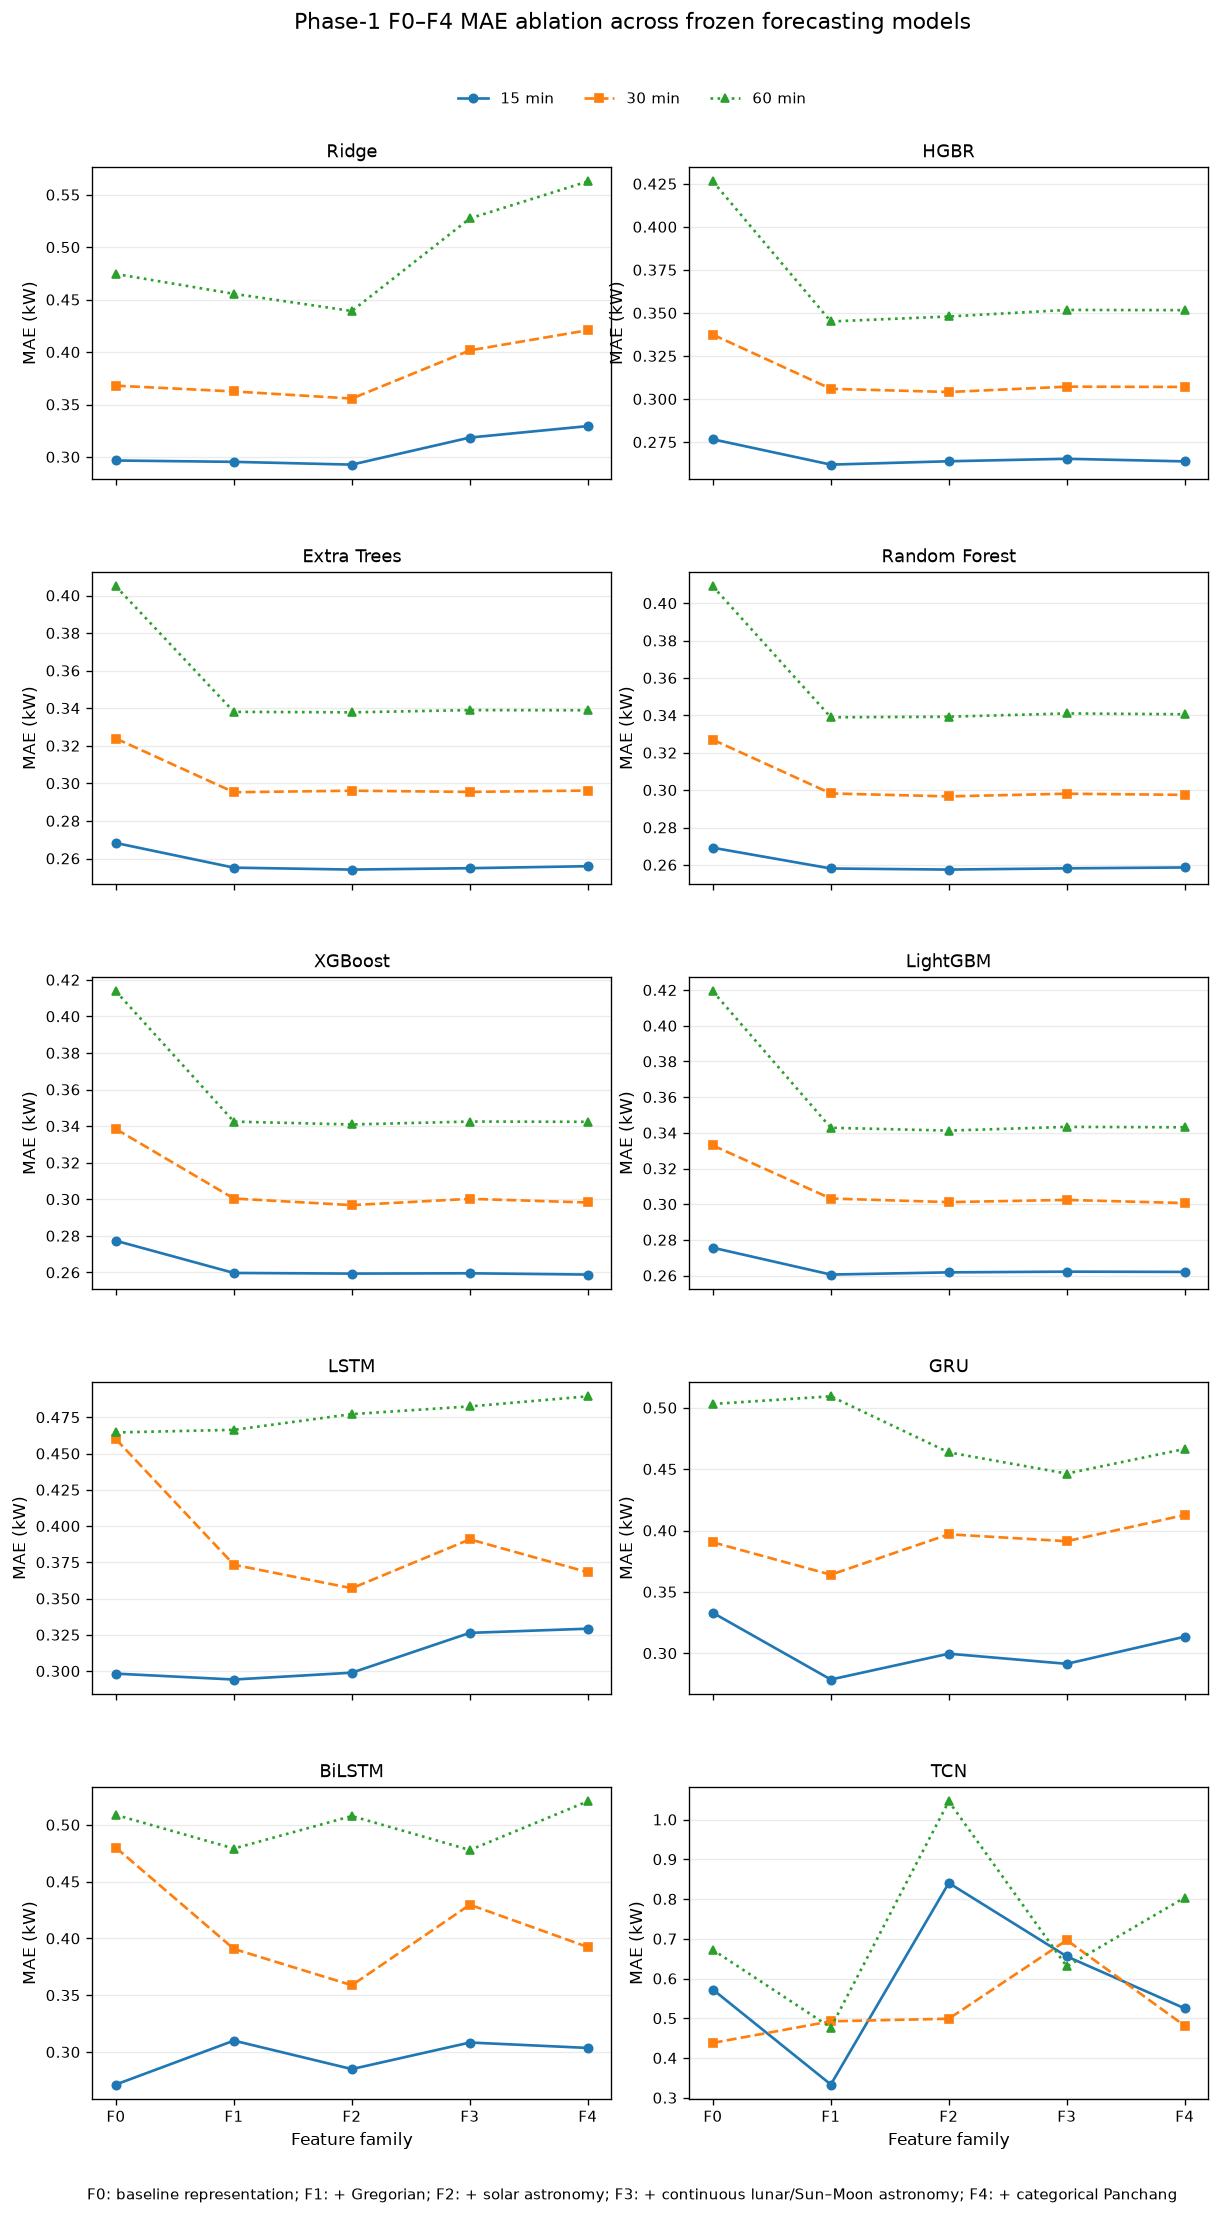

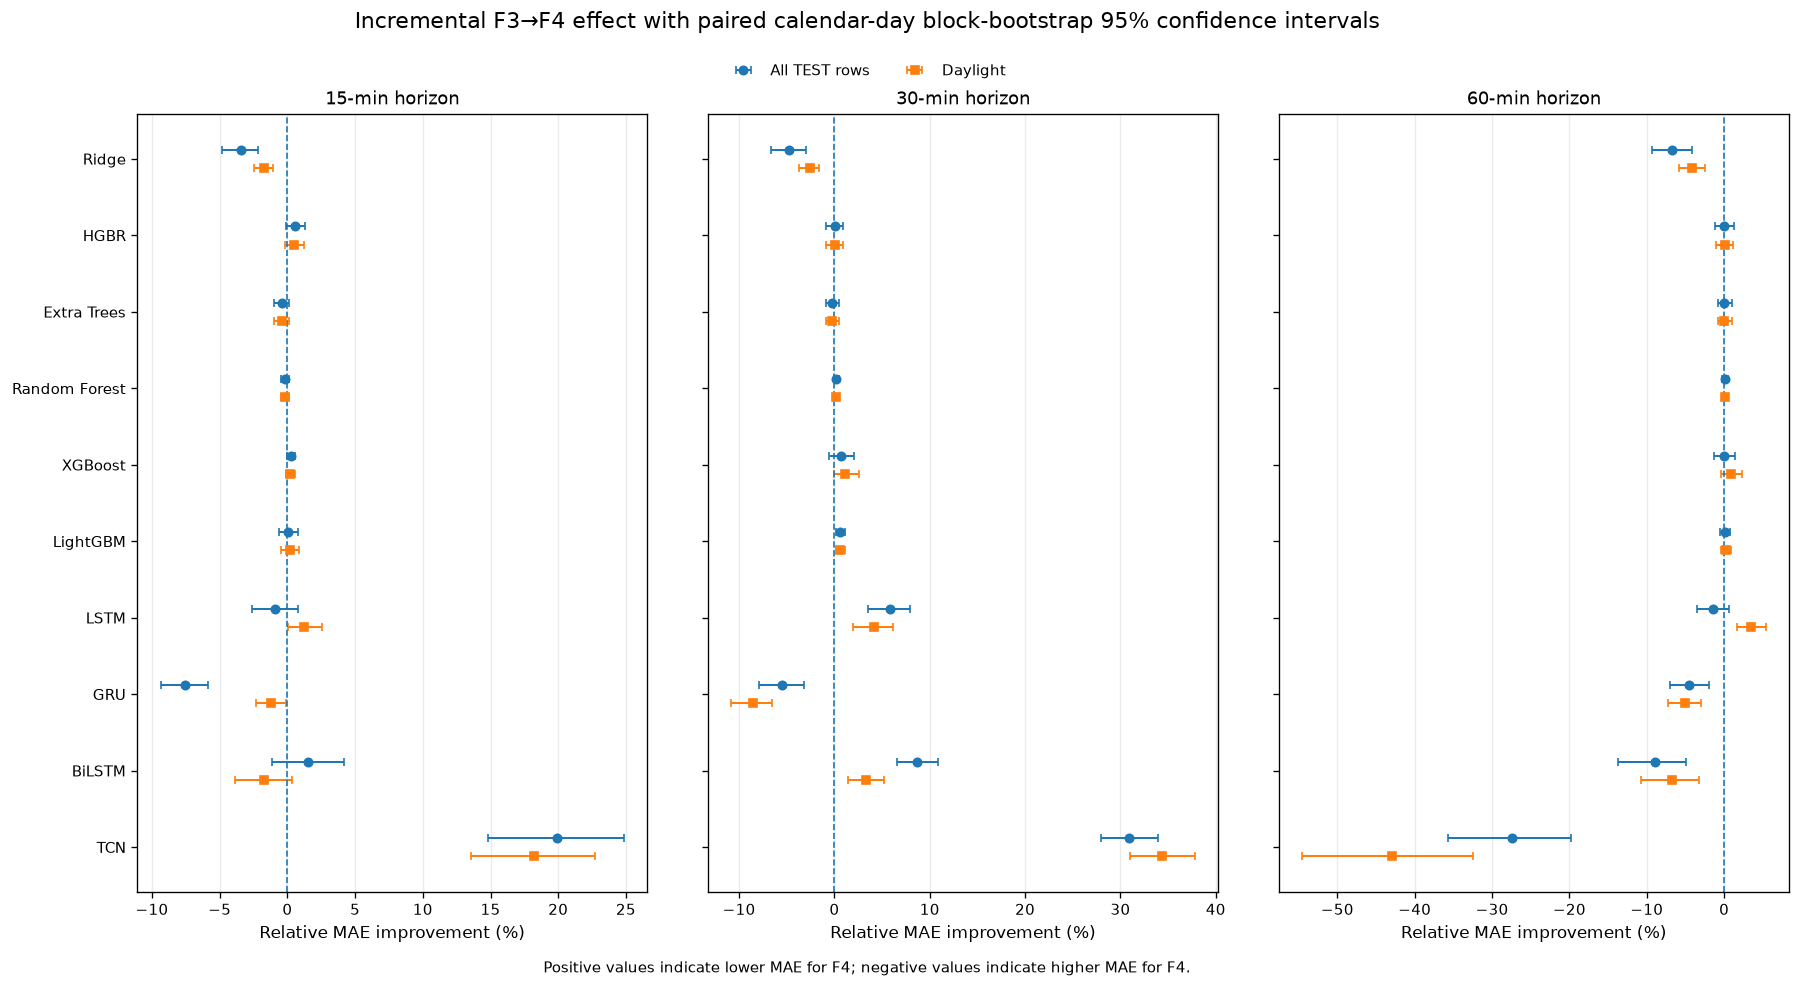

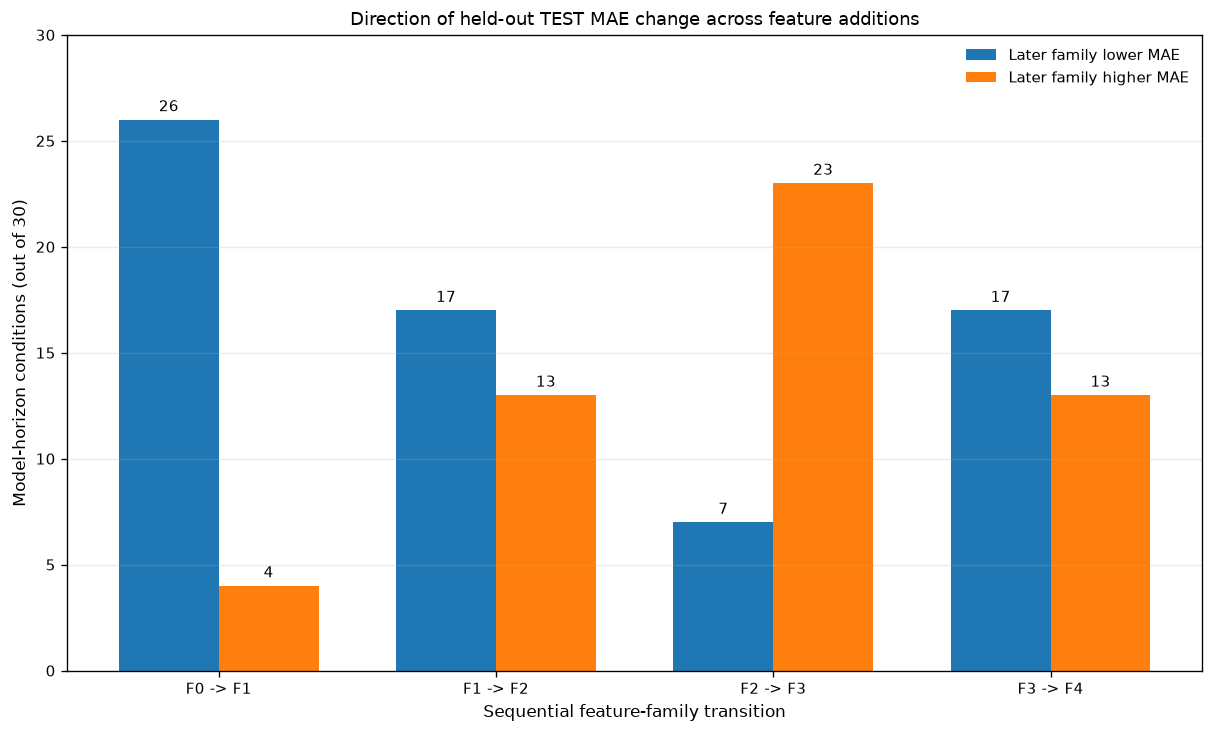

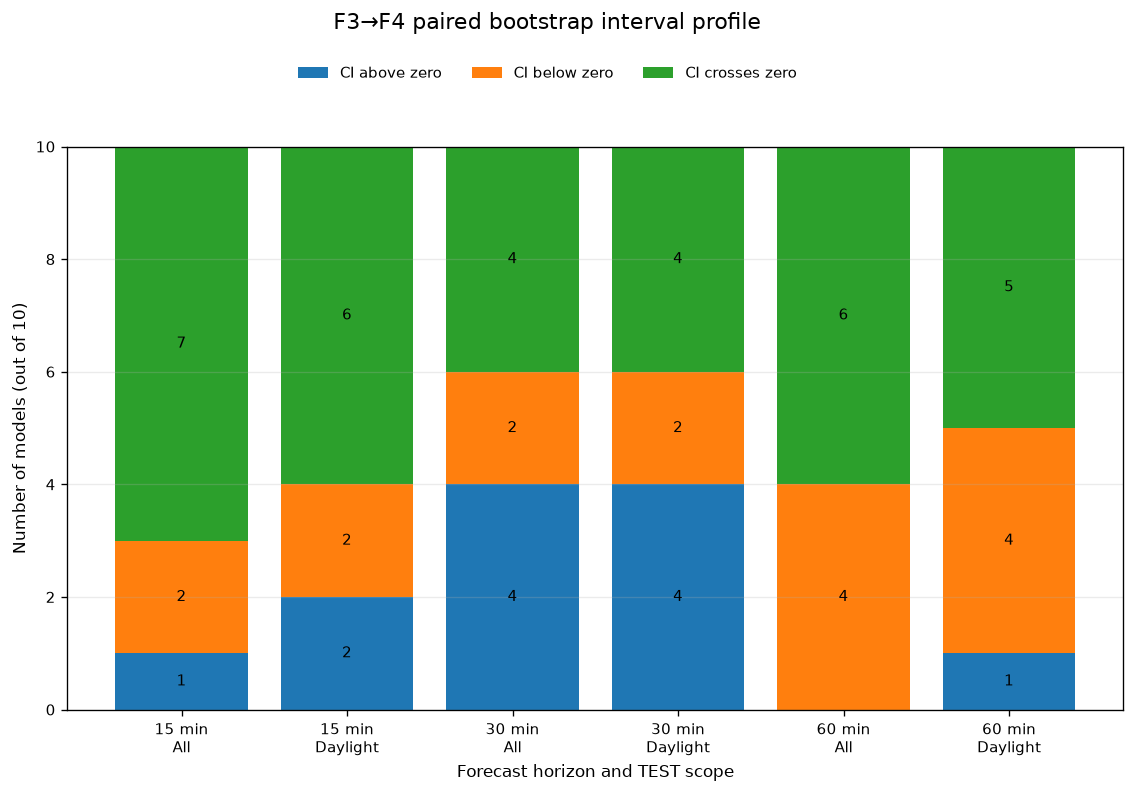


Figure-data read-back verification: PASSED
Figure numerical integrity checks: PASSED

PUBLICATION FIGURE ARTIFACT INVENTORY


,artifact_type,figure_stem,filename,format,bytes
0,figure,figure_phase1_f3_f4_ci_profile,figure_phase1_f3_f4_ci_profile.pdf,pdf,18779
1,figure,figure_phase1_f3_f4_ci_profile,figure_phase1_f3_f4_ci_profile.png,png,118220
2,figure,figure_phase1_f3_f4_ci_profile,figure_phase1_f3_f4_ci_profile.svg,svg,48583
3,figure,figure_phase1_f3_f4_forest,figure_phase1_f3_f4_forest.pdf,pdf,29412
4,figure,figure_phase1_f3_f4_forest,figure_phase1_f3_f4_forest.png,png,212118
5,figure,figure_phase1_f3_f4_forest,figure_phase1_f3_f4_forest.svg,svg,111798
6,figure,figure_phase1_feature_transition_direction_counts,figure_phase1_feature_transition_direction_cou...,pdf,14185
7,figure,figure_phase1_feature_transition_direction_counts,figure_phase1_feature_transition_direction_cou...,png,107529
8,figure,figure_phase1_feature_transition_direction_counts,figure_phase1_feature_transition_direction_cou...,svg,43650
9,figure,figure_phase1_full_f0_f4_mae_ablation,figure_phase1_full_f0_f4_mae_ablation.pdf,pdf,30769



PHASE-1 PUBLICATION FIGURES: COMPLETE
Publication figures: 4
Render formats per figure: 3
Rendered figure files: 12 / 12
Figure-data CSVs: 4 / 4

Figures created:
  1. Full F0-F4 MAE ablation
  2. F3-F4 paired-bootstrap forest plot
  3. Sequential feature-transition direction counts
  4. F3-F4 CI evidence profile by horizon / scope

Visual-layout polish applied: YES
Figure-data identity verification: PASSED
Numerical figure-source audits: PASSED
Cross-model effect-size averaging performed: NO
TEST-driven model ranking performed: NO
Model order based on TEST performance: NO
Causal claim introduced: NO

Next step:
Perform the final Notebook 12 synthesis audit, generate the paper-ready Phase-1 narrative summary, and freeze the Notebook 12 artifact manifest.


In [16]:
# ============================================================
# Notebook 12
# Step 10 — FINAL POLISHED VERSION
#
# Generate final Phase-1 publication figures
#
# PURPOSE
# -------
#
# Create paper-quality figures directly from the frozen
# Notebook 12 publication tables.
#
#
# FIGURES
# -------
#
# Figure 1
#   Full F0-F4 MAE ablation across all 10 models
#
# Figure 2
#   F3 -> F4 relative-MAE forest plot with paired
#   calendar-day block-bootstrap 95% confidence intervals
#
# Figure 3
#   Sequential feature-transition direction counts
#
# Figure 4
#   F3 -> F4 interval evidence by horizon and TEST scope
#
#
# VISUAL-POLISH REVISION
# ----------------------
#
# This final version improves:
#
#   - Figure 1 title / legend separation
#   - Figure 1 bottom x-label spacing
#   - overall subplot spacing
#   - Figure 2 shared legend placement
#   - Figure 4 legend placement outside plotting area
#
#
# SCIENTIFIC CONTENT IS UNCHANGED.
#
# NO:
#
#   - model training
#   - metric recomputation from predictions
#   - TEST-driven model selection
#   - model ranking
#   - cross-architecture effect-size averaging
#   - causal interpretation
# ============================================================


from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


print(
    "=" * 92
)

print(
    "NOTEBOOK 12 — STEP 10"
)

print(
    "FINAL PHASE-1 PUBLICATION FIGURES — POLISHED"
)

print(
    "=" * 92
)


# ============================================================
# 1. Publication plotting defaults
# ============================================================

plt.rcParams.update(
    {
        "figure.dpi":
            120,

        "savefig.dpi":
            300,

        "font.size":
            10,

        "axes.titlesize":
            11,

        "axes.labelsize":
            10,

        "xtick.labelsize":
            9,

        "ytick.labelsize":
            9,

        "legend.fontsize":
            9,

        "figure.titlesize":
            13,

        "pdf.fonttype":
            42,

        "ps.fonttype":
            42,
    }
)


FIGURE_FORMATS = [
    "png",
    "pdf",
    "svg",
]


# ============================================================
# 2. Save helpers
# ============================================================

figure_artifact_rows = []


def save_publication_figure(
    figure,
    stem,
):
    """
    Save one Matplotlib figure as PNG, PDF, and SVG.
    """

    saved_paths = []


    for suffix in (
        FIGURE_FORMATS
    ):

        output_path = (
            NOTEBOOK12_RESULTS_DIR
            /
            f"{stem}.{suffix}"
        )


        figure.savefig(
            output_path,
            bbox_inches="tight",
        )


        assert (
            output_path.exists()
        )


        assert (
            output_path.stat().st_size
            >
            0
        )


        figure_artifact_rows.append(
            {
                "artifact_type":
                    "figure",

                "figure_stem":
                    stem,

                "filename":
                    output_path.name,

                "format":
                    suffix,

                "bytes":
                    int(
                        output_path.stat().st_size
                    ),
            }
        )


        saved_paths.append(
            output_path
        )


    return saved_paths


def save_figure_data(
    dataframe,
    filename,
):
    """
    Persist the exact numerical table used by one figure.
    """

    output_path = (
        NOTEBOOK12_RESULTS_DIR
        /
        filename
    )


    dataframe.to_csv(
        output_path,
        index=False,
    )


    assert (
        output_path.exists()
    )


    assert (
        output_path.stat().st_size
        >
        0
    )


    figure_artifact_rows.append(
        {
            "artifact_type":
                "figure_data",

            "figure_stem":
                filename.replace(
                    ".csv",
                    "",
                ),

            "filename":
                output_path.name,

            "format":
                "csv",

            "bytes":
                int(
                    output_path.stat().st_size
                ),
        }
    )


    return output_path


# ============================================================
# 3. FIGURE 1
#
# Full F0-F4 MAE ablation
#
# One panel per model.
#
# Three lines:
#
#       15 min
#       30 min
#       60 min
#
# The y-axis is intentionally independent across models.
#
# This figure emphasizes WITHIN-MODEL feature-family behavior.
# ============================================================

figure1_data = (
    publication_mae_ablation
    .copy()
)


assert (
    len(
        figure1_data
    )
    ==
    30
)


figure1_data_path = save_figure_data(
    figure1_data,
    "figure_full_f0_f4_mae_ablation_data.csv",
)


fig1, axes1 = plt.subplots(
    nrows=5,
    ncols=2,
    figsize=(12, 18.5),
    sharex=True,
)


axes1 = (
    axes1.flatten()
)


HORIZON_LINESTYLES = {
    15: "-",
    30: "--",
    60: ":",
}


HORIZON_MARKERS = {
    15: "o",
    30: "s",
    60: "^",
}


feature_positions = np.arange(
    len(
        PUBLICATION_FEATURE_ORDER
    )
)


for (
    axis,
    model_name,
) in zip(
    axes1,
    PUBLICATION_MODEL_ORDER,
):

    model_subset = (
        figure1_data.loc[
            figure1_data[
                "model"
            ]
            ==
            model_name
        ]
        .copy()
    )


    assert (
        len(
            model_subset
        )
        ==
        3
    )


    for horizon_minutes in (
        PUBLICATION_HORIZON_ORDER
    ):

        horizon_row = (
            model_subset.loc[
                model_subset[
                    "horizon_minutes"
                ]
                ==
                horizon_minutes
            ]
        )


        assert (
            len(
                horizon_row
            )
            ==
            1
        )


        horizon_row = (
            horizon_row.iloc[
                0
            ]
        )


        y_values = np.array(
            [
                float(
                    horizon_row[
                        feature_family
                    ]
                )

                for feature_family in (
                    PUBLICATION_FEATURE_ORDER
                )
            ]
        )


        axis.plot(
            feature_positions,
            y_values,
            marker=
                HORIZON_MARKERS[
                    horizon_minutes
                ],
            linestyle=
                HORIZON_LINESTYLES[
                    horizon_minutes
                ],
            linewidth=1.6,
            markersize=5,
            label=
                f"{horizon_minutes} min",
        )


    axis.set_title(
        model_name,
        pad=6,
    )


    axis.set_xticks(
        feature_positions
    )


    axis.set_xticklabels(
        PUBLICATION_FEATURE_ORDER
    )


    axis.grid(
        axis="y",
        alpha=0.25,
    )


    axis.set_ylabel(
        "MAE (kW)"
    )


# ------------------------------------------------------------
# Add x-axis label only to bottom-row axes.
#
# This avoids collision with the bottom of the overall figure.
# ------------------------------------------------------------

axes1[
    -2
].set_xlabel(
    "Feature family"
)


axes1[
    -1
].set_xlabel(
    "Feature family"
)


# ------------------------------------------------------------
# Shared legend placed between title and panels.
# ------------------------------------------------------------

legend_handles, legend_labels = (
    axes1[
        0
    ]
    .get_legend_handles_labels()
)


fig1.legend(
    legend_handles,
    legend_labels,
    loc=
        "upper center",
    bbox_to_anchor=
        (
            0.5,
            0.965,
        ),
    ncol=
        3,
    frameon=
        False,
)


fig1.suptitle(
    (
        "Phase-1 F0–F4 MAE ablation across frozen "
        "forecasting models"
    ),
    y=
        0.995,
)


fig1.text(
    0.5,
    0.008,
    (
        "F0: baseline representation; "
        "F1: + Gregorian; "
        "F2: + solar astronomy; "
        "F3: + continuous lunar/Sun–Moon astronomy; "
        "F4: + categorical Panchang"
    ),
    ha=
        "center",
    va=
        "bottom",
    fontsize=
        9,
)


# ------------------------------------------------------------
# Explicit margins are more reliable here than relying only on
# constrained_layout for a tall multi-panel publication figure.
# ------------------------------------------------------------

fig1.subplots_adjust(
    top=
        0.925,
    bottom=
        0.055,
    hspace=
        0.30,
    wspace=
        0.15,
)


figure1_paths = save_publication_figure(
    fig1,
    "figure_phase1_full_f0_f4_mae_ablation",
)


plt.show()


plt.close(
    fig1
)


# ============================================================
# 4. FIGURE 2
#
# Central F3 -> F4 forest plot
#
# Three horizon panels.
#
# Each model:
#
#       circle = all TEST rows
#       square = daylight rows
#
# Positive:
#
#       F4 lower MAE
#
# Negative:
#
#       F4 higher MAE
# ============================================================

figure2_data = (
    publication_f3_f4_numeric[
        [
            "model",
            "horizon_minutes",
            "scope",
            "F3_to_F4_MAE_improvement_percent",
            "CI95_low_percent",
            "CI95_high_percent",
            "CI_zero_status",
        ]
    ]
    .copy()
)


assert (
    len(
        figure2_data
    )
    ==
    60
)


figure2_data_path = save_figure_data(
    figure2_data,
    "figure_f3_f4_forest_data.csv",
)


fig2, axes2 = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(16, 8.2),
    sharey=True,
)


scope_marker = {
    "all": "o",
    "daylight": "s",
}


scope_offset = {
    "all": -0.12,
    "daylight": 0.12,
}


model_y = {
    model_name:
        position

    for (
        position,
        model_name,
    ) in enumerate(
        PUBLICATION_MODEL_ORDER
    )
}


for (
    axis,
    horizon_minutes,
) in zip(
    axes2,
    PUBLICATION_HORIZON_ORDER,
):

    horizon_subset = (
        figure2_data.loc[
            figure2_data[
                "horizon_minutes"
            ]
            ==
            horizon_minutes
        ]
        .copy()
    )


    assert (
        len(
            horizon_subset
        )
        ==
        20
    )


    for scope in [
        "all",
        "daylight",
    ]:

        scope_subset = (
            horizon_subset.loc[
                horizon_subset[
                    "scope"
                ]
                ==
                scope
            ]
            .copy()
        )


        scope_subset[
            "_model_order"
        ] = (
            scope_subset[
                "model"
            ]
            .map(
                model_order_lookup
            )
        )


        scope_subset = (
            scope_subset
            .sort_values(
                "_model_order"
            )
        )


        assert (
            len(
                scope_subset
            )
            ==
            10
        )


        effects = (
            scope_subset[
                "F3_to_F4_MAE_improvement_percent"
            ]
            .to_numpy(
                dtype=float
            )
        )


        ci_low = (
            scope_subset[
                "CI95_low_percent"
            ]
            .to_numpy(
                dtype=float
            )
        )


        ci_high = (
            scope_subset[
                "CI95_high_percent"
            ]
            .to_numpy(
                dtype=float
            )
        )


        lower_error = (
            effects
            -
            ci_low
        )


        upper_error = (
            ci_high
            -
            effects
        )


        assert (
            lower_error
            >=
            0.0
        ).all()


        assert (
            upper_error
            >=
            0.0
        ).all()


        y_positions = np.array(
            [
                model_y[
                    model_name
                ]
                +
                scope_offset[
                    scope
                ]

                for model_name in (
                    scope_subset[
                        "model"
                    ]
                )
            ]
        )


        axis.errorbar(
            effects,
            y_positions,
            xerr=np.vstack(
                [
                    lower_error,
                    upper_error,
                ]
            ),
            fmt=
                scope_marker[
                    scope
                ],
            markersize=
                5,
            linewidth=
                1.2,
            capsize=
                2.5,
            label=(
                "All TEST rows"
                if (
                    scope
                    ==
                    "all"
                )
                else
                "Daylight"
            ),
        )


    axis.axvline(
        0.0,
        linestyle=
            "--",
        linewidth=
            1.0,
    )


    axis.set_title(
        f"{horizon_minutes}-min horizon"
    )


    axis.set_xlabel(
        "Relative MAE improvement (%)"
    )


    axis.grid(
        axis=
            "x",
        alpha=
            0.25,
    )


axes2[
    0
].set_yticks(
    np.arange(
        len(
            PUBLICATION_MODEL_ORDER
        )
    )
)


axes2[
    0
].set_yticklabels(
    PUBLICATION_MODEL_ORDER
)


axes2[
    0
].invert_yaxis()


# ------------------------------------------------------------
# One shared legend above all three panels.
# ------------------------------------------------------------

forest_handles, forest_labels = (
    axes2[
        0
    ]
    .get_legend_handles_labels()
)


fig2.legend(
    forest_handles,
    forest_labels,
    loc=
        "upper center",
    bbox_to_anchor=
        (
            0.5,
            0.955,
        ),
    ncol=
        2,
    frameon=
        False,
)


fig2.suptitle(
    (
        "Incremental F3→F4 effect with paired "
        "calendar-day block-bootstrap 95% confidence intervals"
    ),
    y=
        0.995,
)


fig2.text(
    0.5,
    0.018,
    (
        "Positive values indicate lower MAE for F4; "
        "negative values indicate higher MAE for F4."
    ),
    ha=
        "center",
    fontsize=
        9,
)


fig2.subplots_adjust(
    top=
        0.89,
    bottom=
        0.10,
    left=
        0.12,
    right=
        0.98,
    wspace=
        0.12,
)


figure2_paths = save_publication_figure(
    fig2,
    "figure_phase1_f3_f4_forest",
)


plt.show()


plt.close(
    fig2
)


# ============================================================
# 5. FIGURE 3
#
# Sequential feature-transition direction counts
# ============================================================

figure3_data = (
    publication_transition_counts[
        [
            "transition",
            "increment",
            "conditions_compared",
            "later_family_lower_MAE_count",
            "later_family_higher_MAE_count",
            "equal_MAE_count",
        ]
    ]
    .copy()
)


assert (
    len(
        figure3_data
    )
    ==
    4
)


figure3_data_path = save_figure_data(
    figure3_data,
    "figure_feature_transition_direction_counts_data.csv",
)


fig3, ax3 = plt.subplots(
    figsize=(10, 6),
    constrained_layout=True,
)


transition_positions = np.arange(
    len(
        figure3_data
    )
)


bar_width = 0.36


lower_bars = ax3.bar(
    transition_positions
    -
    bar_width
    /
    2,
    figure3_data[
        "later_family_lower_MAE_count"
    ],
    width=
        bar_width,
    label=
        "Later family lower MAE",
)


higher_bars = ax3.bar(
    transition_positions
    +
    bar_width
    /
    2,
    figure3_data[
        "later_family_higher_MAE_count"
    ],
    width=
        bar_width,
    label=
        "Later family higher MAE",
)


ax3.set_xticks(
    transition_positions
)


ax3.set_xticklabels(
    figure3_data[
        "transition"
    ]
)


ax3.set_ylabel(
    "Model-horizon conditions (out of 30)"
)


ax3.set_xlabel(
    "Sequential feature-family transition"
)


ax3.set_title(
    "Direction of held-out TEST MAE change across feature additions"
)


ax3.set_ylim(
    0,
    30,
)


ax3.grid(
    axis="y",
    alpha=0.25,
)


ax3.legend(
    frameon=False
)


for bars in [
    lower_bars,
    higher_bars,
]:

    ax3.bar_label(
        bars,
        padding=3,
        fontsize=9,
    )


figure3_paths = save_publication_figure(
    fig3,
    "figure_phase1_feature_transition_direction_counts",
)


plt.show()


plt.close(
    fig3
)


# ============================================================
# 6. FIGURE 4
#
# F3 -> F4 interval-evidence profile by horizon and scope
#
# Each bar contains 10 models:
#
#       CI above zero
#       CI below zero
#       CI crosses zero
#
# FINAL LAYOUT
# ------------
#
# The title and legend use separate figure-level vertical
# regions so that they cannot overlap.
# ============================================================

figure4_data = (
    publication_f3_f4_condition_counts[
        [
            "horizon_minutes",
            "scope",
            "models_compared",
            "CI_above_zero_count",
            "CI_below_zero_count",
            "CI_crosses_zero_count",
        ]
    ]
    .copy()
)


assert (
    len(
        figure4_data
    )
    ==
    6
)


figure4_data_path = save_figure_data(
    figure4_data,
    "figure_f3_f4_ci_profile_data.csv",
)


# ------------------------------------------------------------
# Human-readable x-axis labels
# ------------------------------------------------------------

figure4_data[
    "condition_label"
] = (
    figure4_data[
        "horizon_minutes"
    ]
    .astype(str)
    +
    " min\n"
    +
    figure4_data[
        "scope"
    ]
    .map(
        {
            "all":
                "All",

            "daylight":
                "Daylight",
        }
    )
)


fig4, ax4 = plt.subplots(
    figsize=(10, 6.8),
)


condition_positions = np.arange(
    len(
        figure4_data
    )
)


above_values = (
    figure4_data[
        "CI_above_zero_count"
    ]
    .to_numpy(
        dtype=int
    )
)


below_values = (
    figure4_data[
        "CI_below_zero_count"
    ]
    .to_numpy(
        dtype=int
    )
)


cross_values = (
    figure4_data[
        "CI_crosses_zero_count"
    ]
    .to_numpy(
        dtype=int
    )
)


# ------------------------------------------------------------
# Stacked bars
# ------------------------------------------------------------

above_bars = ax4.bar(
    condition_positions,
    above_values,
    label=
        "CI above zero",
)


below_bars = ax4.bar(
    condition_positions,
    below_values,
    bottom=
        above_values,
    label=
        "CI below zero",
)


cross_bottom = (
    above_values
    +
    below_values
)


cross_bars = ax4.bar(
    condition_positions,
    cross_values,
    bottom=
        cross_bottom,
    label=
        "CI crosses zero",
)


# ------------------------------------------------------------
# Axes
# ------------------------------------------------------------

ax4.set_xticks(
    condition_positions
)


ax4.set_xticklabels(
    figure4_data[
        "condition_label"
    ]
)


ax4.set_ylabel(
    "Number of models (out of 10)"
)


ax4.set_xlabel(
    "Forecast horizon and TEST scope"
)


ax4.set_ylim(
    0,
    10,
)


ax4.grid(
    axis=
        "y",
    alpha=
        0.25,
)


# ------------------------------------------------------------
# Figure-level title
#
# Putting the title at the FIGURE level rather than the AXES
# level gives us an independent vertical region.
# ------------------------------------------------------------

fig4.suptitle(
    "F3→F4 paired bootstrap interval profile",
    y=
        0.985,
    fontsize=
        13,
)


# ------------------------------------------------------------
# Figure-level legend
#
# This sits below the title but above the plotting panel.
# ------------------------------------------------------------

legend_handles, legend_labels = (
    ax4.get_legend_handles_labels()
)


fig4.legend(
    legend_handles,
    legend_labels,
    loc=
        "upper center",
    bbox_to_anchor=
        (
            0.5,
            0.935,
        ),
    ncol=
        3,
    frameon=
        False,
)


# ------------------------------------------------------------
# Segment count labels
# ------------------------------------------------------------

for position in range(
    len(
        figure4_data
    )
):

    if (
        above_values[
            position
        ]
        >
        0
    ):

        ax4.text(
            position,
            above_values[
                position
            ]
            /
            2,
            str(
                above_values[
                    position
                ]
            ),
            ha=
                "center",
            va=
                "center",
            fontsize=
                9,
        )


    if (
        below_values[
            position
        ]
        >
        0
    ):

        ax4.text(
            position,
            (
                above_values[
                    position
                ]
                +
                below_values[
                    position
                ]
                /
                2
            ),
            str(
                below_values[
                    position
                ]
            ),
            ha=
                "center",
            va=
                "center",
            fontsize=
                9,
        )


    if (
        cross_values[
            position
        ]
        >
        0
    ):

        ax4.text(
            position,
            (
                cross_bottom[
                    position
                ]
                +
                cross_values[
                    position
                ]
                /
                2
            ),
            str(
                cross_values[
                    position
                ]
            ),
            ha=
                "center",
            va=
                "center",
            fontsize=
                9,
        )


# ------------------------------------------------------------
# Explicitly reserve:
#
#       top ~2%      title
#       next ~6%     legend
#       remaining    axes
# ------------------------------------------------------------

fig4.subplots_adjust(
    top=
        0.82,
    bottom=
        0.13,
    left=
        0.10,
    right=
        0.98,
)


figure4_paths = save_publication_figure(
    fig4,
    "figure_phase1_f3_f4_ci_profile",
)


plt.show()


plt.close(
    fig4
)

# ============================================================
# 7. Figure-data read-back verification
# ============================================================

figure1_data_readback = pd.read_csv(
    figure1_data_path
)


figure2_data_readback = pd.read_csv(
    figure2_data_path
)


figure3_data_readback = pd.read_csv(
    figure3_data_path
)


figure4_data_readback = pd.read_csv(
    figure4_data_path
)


pd.testing.assert_frame_equal(
    figure1_data_readback,
    figure1_data,
    check_dtype=False,
    rtol=0.0,
    atol=1e-12,
)


pd.testing.assert_frame_equal(
    figure2_data_readback,
    figure2_data,
    check_dtype=False,
    rtol=0.0,
    atol=1e-12,
)


pd.testing.assert_frame_equal(
    figure3_data_readback,
    figure3_data,
    check_dtype=False,
    rtol=0.0,
    atol=1e-12,
)


pd.testing.assert_frame_equal(
    figure4_data_readback,
    figure4_data[
        [
            "horizon_minutes",
            "scope",
            "models_compared",
            "CI_above_zero_count",
            "CI_below_zero_count",
            "CI_crosses_zero_count",
        ]
    ],
    check_dtype=False,
    rtol=0.0,
    atol=1e-12,
)


print(
    "\nFigure-data read-back verification: PASSED"
)


# ============================================================
# 8. Numerical figure-source audits
# ============================================================

assert (
    len(
        figure1_data
    )
    ==
    30
)


assert (
    figure1_data[
        "model"
    ]
    .nunique()
    ==
    10
)


assert (
    len(
        figure2_data
    )
    ==
    60
)


assert (
    (
        figure2_data[
            "CI95_low_percent"
        ]
        <=
        figure2_data[
            "F3_to_F4_MAE_improvement_percent"
        ]
    )
    .all()
)


assert (
    (
        figure2_data[
            "F3_to_F4_MAE_improvement_percent"
        ]
        <=
        figure2_data[
            "CI95_high_percent"
        ]
    )
    .all()
)


assert (
    (
        figure3_data[
            "later_family_lower_MAE_count"
        ]
        +
        figure3_data[
            "later_family_higher_MAE_count"
        ]
        +
        figure3_data[
            "equal_MAE_count"
        ]
        ==
        30
    )
    .all()
)


assert (
    (
        figure4_data[
            "CI_above_zero_count"
        ]
        +
        figure4_data[
            "CI_below_zero_count"
        ]
        +
        figure4_data[
            "CI_crosses_zero_count"
        ]
        ==
        10
    )
    .all()
)


print(
    "Figure numerical integrity checks: PASSED"
)


# ============================================================
# 9. Create final figure artifact inventory
# ============================================================

publication_figure_inventory = pd.DataFrame(
    figure_artifact_rows
)


publication_figure_inventory = (
    publication_figure_inventory
    .sort_values(
        [
            "artifact_type",
            "figure_stem",
            "format",
        ]
    )
    .reset_index(
        drop=True
    )
)


publication_figure_inventory_path = (
    NOTEBOOK12_RESULTS_DIR
    /
    "publication_figure_inventory.csv"
)


publication_figure_inventory.to_csv(
    publication_figure_inventory_path,
    index=False,
)


assert (
    publication_figure_inventory_path.exists()
)


assert (
    publication_figure_inventory_path.stat().st_size
    >
    0
)


# ============================================================
# 10. Verify expected artifacts
# ============================================================

figure_files_only = (
    publication_figure_inventory.loc[
        publication_figure_inventory[
            "artifact_type"
        ]
        ==
        "figure"
    ]
)


figure_data_files_only = (
    publication_figure_inventory.loc[
        publication_figure_inventory[
            "artifact_type"
        ]
        ==
        "figure_data"
    ]
)


assert (
    len(
        figure_files_only
    )
    ==
    12
)


assert (
    len(
        figure_data_files_only
    )
    ==
    4
)


assert (
    set(
        figure_files_only[
            "format"
        ]
    )
    ==
    {
        "png",
        "pdf",
        "svg",
    }
)


# ============================================================
# 11. Display final inventory
# ============================================================

print(
    "\n"
    +
    "=" * 92
)

print(
    "PUBLICATION FIGURE ARTIFACT INVENTORY"
)

print(
    "=" * 92
)


display(
    publication_figure_inventory
)


# ============================================================
# 12. Final checkpoint
# ============================================================

print(
    "\n"
    +
    "=" * 92
)

print(
    "PHASE-1 PUBLICATION FIGURES: COMPLETE"
)

print(
    "=" * 92
)


print(
    "Publication figures:",
    4,
)


print(
    "Render formats per figure:",
    len(
        FIGURE_FORMATS
    ),
)


print(
    "Rendered figure files:",
    len(
        figure_files_only
    ),
    "/ 12",
)


print(
    "Figure-data CSVs:",
    len(
        figure_data_files_only
    ),
    "/ 4",
)


print(
    "\nFigures created:"
)


print(
    "  1. Full F0-F4 MAE ablation"
)


print(
    "  2. F3-F4 paired-bootstrap forest plot"
)


print(
    "  3. Sequential feature-transition direction counts"
)


print(
    "  4. F3-F4 CI evidence profile by horizon / scope"
)


print(
    "\nVisual-layout polish applied: YES"
)


print(
    "Figure-data identity verification: PASSED"
)


print(
    "Numerical figure-source audits: PASSED"
)


print(
    "Cross-model effect-size averaging performed: NO"
)


print(
    "TEST-driven model ranking performed: NO"
)


print(
    "Model order based on TEST performance: NO"
)


print(
    "Causal claim introduced: NO"
)


print(
    "\nNext step:"
)


print(
    "Perform the final Notebook 12 synthesis audit, generate "
    "the paper-ready Phase-1 narrative summary, and freeze "
    "the Notebook 12 artifact manifest."
)

In [17]:
# ============================================================
# Notebook 12
# Step 11: FINAL Phase-1 synthesis / reproducibility audit
#
# PURPOSE
# -------
#
# This is the closing scientific and reproducibility checkpoint
# for Notebook 12.
#
# It:
#
#   1. audits the complete frozen Phase-1 synthesis
#   2. verifies the major numerical identities
#   3. verifies publication tables and figures
#   4. writes a paper-ready narrative summary
#   5. writes a machine-readable final audit JSON
#   6. creates a SHA256 manifest for Notebook 12 artifacts
#
#
# IT DOES NOT:
#
#   - train models
#   - tune models
#   - select architectures
#   - alter TEST predictions
#   - recompute bootstrap replicates
#   - average effects across architectures
#   - introduce causal claims
#
#
# FINAL PHASE-1 INTERPRETATION
# ----------------------------
#
# The primary scientific conclusion is heterogeneous:
#
#   The incremental predictive value of categorical Panchang
#   features beyond continuous solar/lunar astronomical
#   controls is model- and horizon-dependent.
#
# It is neither universally beneficial nor universally harmful.
#
# ============================================================


from pathlib import Path
import hashlib
import json
import platform
import sys

import numpy as np
import pandas as pd


print(
    "=" * 94
)

print(
    "NOTEBOOK 12 — STEP 11"
)

print(
    "FINAL PHASE-1 SYNTHESIS + REPRODUCIBILITY AUDIT"
)

print(
    "=" * 94
)


# ============================================================
# 1. Final protocol constants
# ============================================================

FINAL_PHASE1_PROTOCOL = {
    "phase":
        "Phase 1",

    "target":
        "P_Solar",

    "forecast_horizons_minutes":
        [
            15,
            30,
            60,
        ],

    "feature_families":
        [
            "F0",
            "F1",
            "F2",
            "F3",
            "F4",
        ],

    "core_incremental_comparison":
        "F3 -> F4",

    "core_interpretation":
        (
            "Categorical Panchang representation beyond "
            "continuous lunar / Sun-Moon astronomical controls"
        ),

    "test_scope_primary":
        "all",

    "test_scope_secondary":
        "daylight",

    "daylight_definition":
        (
            "Valid-time solar elevation > 0 degrees"
        ),

    "test_rows_all":
        26496,

    "test_rows_daylight":
        17851,

    "test_calendar_day_blocks":
        92,

    "bootstrap_replicates":
        10000,

    "bootstrap_seed":
        42,

    "bootstrap_interval":
        "percentile 95%",

    "bootstrap_statistic":
        "MAE_F3 - MAE_F4",

    "positive_effect_meaning":
        "F4 lower MAE than F3",

    "prediction_clipping":
        False,

    "causal_claim":
        False,

    "cross_architecture_effect_size_averaging":
        False,

    "test_driven_model_selection":
        False,

    "frozen_notebook11_tag":
        "phase1-notebook11-final",
}


# ============================================================
# 2. Core structural audit
# ============================================================

assert (
    len(
        phase1_master_test_results
    )
    ==
    150
)


assert (
    phase1_master_test_results[
        "model"
    ]
    .nunique()
    ==
    10
)


assert (
    set(
        phase1_master_test_results[
            "horizon_minutes"
        ]
        .unique()
    )
    ==
    {
        15,
        30,
        60,
    }
)


assert (
    set(
        phase1_master_test_results[
            "feature_family"
        ]
        .unique()
    )
    ==
    {
        "F0",
        "F1",
        "F2",
        "F3",
        "F4",
    }
)


assert (
    len(
        phase1_baseline_test_results
    )
    ==
    9
)


assert (
    len(
        phase1_feature_transition_results
    )
    ==
    120
)


assert (
    len(
        phase1_f3_f4_point_estimates
    )
    ==
    30
)


assert (
    len(
        phase1_f3_f4_bootstrap
    )
    ==
    60
)


assert (
    len(
        phase1_f3_f4_interval_resolved
    )
    ==
    28
)


print(
    "Core structural audit: PASSED"
)


# ============================================================
# 3. Final F0 -> F4 feature-transition counts
# ============================================================

expected_transition_counts = {
    "F0 -> F1":
        (
            26,
            4,
        ),

    "F1 -> F2":
        (
            17,
            13,
        ),

    "F2 -> F3":
        (
            7,
            23,
        ),

    "F3 -> F4":
        (
            17,
            13,
        ),
}


for (
    transition_name,
    expected_counts,
) in (
    expected_transition_counts.items()
):

    transition_row = (
        phase1_transition_direction_summary.loc[
            phase1_transition_direction_summary[
                "transition"
            ]
            ==
            transition_name
        ]
    )


    assert (
        len(
            transition_row
        )
        ==
        1
    )


    transition_row = (
        transition_row.iloc[
            0
        ]
    )


    assert (
        int(
            transition_row[
                "later_family_lower_MAE_count"
            ]
        )
        ==
        expected_counts[
            0
        ]
    )


    assert (
        int(
            transition_row[
                "later_family_higher_MAE_count"
            ]
        )
        ==
        expected_counts[
            1
        ]
    )


print(
    "Sequential feature-transition count audit: PASSED"
)


# ============================================================
# 4. Final unified F3 -> F4 bootstrap counts
# ============================================================

final_point_lower = int(
    (
        phase1_f3_f4_evidence[
            "point_direction"
        ]
        ==
        "F4_lower_MAE"
    )
    .sum()
)


final_point_higher = int(
    (
        phase1_f3_f4_evidence[
            "point_direction"
        ]
        ==
        "F4_higher_MAE"
    )
    .sum()
)


final_ci_above = int(
    (
        phase1_f3_f4_evidence[
            "CI_zero_status"
        ]
        ==
        "above_zero"
    )
    .sum()
)


final_ci_below = int(
    (
        phase1_f3_f4_evidence[
            "CI_zero_status"
        ]
        ==
        "below_zero"
    )
    .sum()
)


final_ci_cross = int(
    (
        phase1_f3_f4_evidence[
            "CI_zero_status"
        ]
        ==
        "crosses_zero"
    )
    .sum()
)


assert (
    final_point_lower
    ==
    35
)


assert (
    final_point_higher
    ==
    25
)


assert (
    final_ci_above
    ==
    12
)


assert (
    final_ci_below
    ==
    16
)


assert (
    final_ci_cross
    ==
    32
)


assert (
    final_ci_above
    +
    final_ci_below
    +
    final_ci_cross
    ==
    60
)


print(
    "Unified F3 -> F4 evidence-count audit: PASSED"
)


# ============================================================
# 5. Horizon × scope audit
# ============================================================

expected_condition_counts = {

    (
        15,
        "all",
    ):
        (
            5,
            5,
            1,
            2,
            7,
        ),

    (
        15,
        "daylight",
    ):
        (
            5,
            5,
            2,
            2,
            6,
        ),

    (
        30,
        "all",
    ):
        (
            7,
            3,
            4,
            2,
            4,
        ),

    (
        30,
        "daylight",
    ):
        (
            7,
            3,
            4,
            2,
            4,
        ),

    (
        60,
        "all",
    ):
        (
            5,
            5,
            0,
            4,
            6,
        ),

    (
        60,
        "daylight",
    ):
        (
            6,
            4,
            1,
            4,
            5,
        ),
}


for (
    condition_key,
    expected_values,
) in (
    expected_condition_counts.items()
):

    (
        horizon_minutes,
        scope,
    ) = condition_key


    condition_row = (
        phase1_f3_f4_condition_profile.loc[
            (
                phase1_f3_f4_condition_profile[
                    "horizon_minutes"
                ]
                ==
                horizon_minutes
            )
            &
            (
                phase1_f3_f4_condition_profile[
                    "scope"
                ]
                ==
                scope
            )
        ]
    )


    assert (
        len(
            condition_row
        )
        ==
        1
    )


    condition_row = (
        condition_row.iloc[
            0
        ]
    )


    observed_values = (
        int(
            condition_row[
                "F4_lower_MAE_point_count"
            ]
        ),

        int(
            condition_row[
                "F4_higher_MAE_point_count"
            ]
        ),

        int(
            condition_row[
                "CI_above_zero_count"
            ]
        ),

        int(
            condition_row[
                "CI_below_zero_count"
            ]
        ),

        int(
            condition_row[
                "CI_crosses_zero_count"
            ]
        ),
    )


    assert (
        observed_values
        ==
        expected_values
    )


print(
    "Horizon × scope evidence audit: PASSED"
)


# ============================================================
# 6. Model-pattern audit
# ============================================================

expected_model_patterns = {
    "Ridge":
        "consistent_CI_below_zero",

    "HGBR":
        "all_positive_points_all_CIs_cross_zero",

    "Extra Trees":
        "mixed_points_all_CIs_cross_zero",

    "Random Forest":
        "mixed_points_all_CIs_cross_zero",

    "XGBoost":
        "all_positive_points_all_CIs_cross_zero",

    "LightGBM":
        "positive_resolved_plus_unresolved",

    "LSTM":
        "positive_resolved_plus_unresolved",

    "GRU":
        "consistent_CI_below_zero",

    "BiLSTM":
        "resolved_bidirectional_pattern",

    "TCN":
        "resolved_bidirectional_pattern",
}


for (
    model_name,
    expected_pattern,
) in (
    expected_model_patterns.items()
):

    pattern_rows = (
        phase1_f3_f4_model_pattern_summary.loc[
            phase1_f3_f4_model_pattern_summary[
                "model"
            ]
            ==
            model_name
        ]
    )


    assert (
        len(
            pattern_rows
        )
        ==
        1
    )


    assert (
        pattern_rows.iloc[
            0
        ][
            "model_pattern"
        ]
        ==
        expected_pattern
    )


print(
    "Model-level evidence-pattern audit: PASSED"
)


# ============================================================
# 7. All-row versus daylight agreement audit
# ============================================================

assert (
    len(
        phase1_scope_agreement
    )
    ==
    30
)


same_point_direction_count = int(
    phase1_scope_agreement[
        "point_direction_same"
    ]
    .sum()
)


different_point_direction_count = (
    30
    -
    same_point_direction_count
)


same_ci_status_count = int(
    phase1_scope_agreement[
        "CI_zero_status_same"
    ]
    .sum()
)


different_ci_status_count = (
    30
    -
    same_ci_status_count
)


assert (
    same_point_direction_count
    ==
    27
)


assert (
    different_point_direction_count
    ==
    3
)


assert (
    same_ci_status_count
    ==
    28
)


assert (
    different_ci_status_count
    ==
    2
)


print(
    "All-row versus daylight agreement audit: PASSED"
)


# ============================================================
# 8. Publication table audit
# ============================================================

publication_table_expected_rows = {
    "publication_master_long":
        150,

    "publication_mae_ablation":
        30,

    "publication_rmse_ablation":
        30,

    "publication_r2_ablation":
        30,

    "publication_baseline_table":
        9,

    "publication_f3_f4_numeric":
        60,

    "publication_f3_f4_wide":
        6,

    "publication_transition_counts":
        4,

    "publication_f3_f4_condition_counts":
        6,

    "publication_model_patterns":
        10,

    "publication_key_results":
        10,
}


publication_table_objects = {
    "publication_master_long":
        publication_master_long,

    "publication_mae_ablation":
        publication_mae_ablation,

    "publication_rmse_ablation":
        publication_rmse_ablation,

    "publication_r2_ablation":
        publication_r2_ablation,

    "publication_baseline_table":
        publication_baseline_table,

    "publication_f3_f4_numeric":
        publication_f3_f4_numeric,

    "publication_f3_f4_wide":
        publication_f3_f4_wide,

    "publication_transition_counts":
        publication_transition_counts,

    "publication_f3_f4_condition_counts":
        publication_f3_f4_condition_counts,

    "publication_model_patterns":
        publication_model_patterns,

    "publication_key_results":
        publication_key_results,
}


for (
    table_name,
    expected_rows,
) in (
    publication_table_expected_rows.items()
):

    assert (
        len(
            publication_table_objects[
                table_name
            ]
        )
        ==
        expected_rows
    )


print(
    "Publication-table audit: PASSED"
)


# ============================================================
# 9. Publication figure audit
# ============================================================

assert (
    len(
        figure_files_only
    )
    ==
    12
)


assert (
    len(
        figure_data_files_only
    )
    ==
    4
)


assert (
    set(
        figure_files_only[
            "format"
        ]
    )
    ==
    {
        "png",
        "pdf",
        "svg",
    }
)


EXPECTED_FINAL_FIGURE_STEMS = {
    "figure_phase1_full_f0_f4_mae_ablation",
    "figure_phase1_f3_f4_forest",
    "figure_phase1_feature_transition_direction_counts",
    "figure_phase1_f3_f4_ci_profile",
}


assert (
    set(
        figure_files_only[
            "figure_stem"
        ]
        .unique()
    )
    ==
    EXPECTED_FINAL_FIGURE_STEMS
)


print(
    "Publication-figure artifact audit: PASSED"
)


# ============================================================
# 10. Critical source-file presence audit
# ============================================================

critical_source_paths = [
    NB09_DIR
    /
    "baseline_results.csv",

    NB09_DIR
    /
    "final_test_results.csv",

    NB09_DIR
    /
    "paired_block_bootstrap_summary.csv",

    NB10_DIR
    /
    "extra_trees_final_test_results.csv",

    NB10_DIR
    /
    "extra_trees_bootstrap_summary.csv",

    NB10_DIR
    /
    "random_forest_final_test_results.csv",

    NB10_DIR
    /
    "random_forest_bootstrap_summary.csv",

    NB10_DIR
    /
    "xgboost_final_test_results.csv",

    NB10_DIR
    /
    "xgboost_bootstrap_summary.csv",

    NB10_DIR
    /
    "lightgbm_final_test_results.csv",

    NB10_DIR
    /
    "lightgbm_bootstrap_summary.csv",

    NB11_DIR
    /
    "notebook11_final_result_matrix.csv",

    NB11_DIR
    /
    "lstm_gru_bilstm_tcn_f3_f4_comparison.csv",
]


for source_path in (
    critical_source_paths
):

    assert (
        source_path.exists()
    )


    assert (
        source_path.stat().st_size
        >
        0
    )


print(
    "Critical frozen source-artifact audit: PASSED"
)


# ============================================================
# 11. Construct final paper-ready Phase-1 narrative
#
# This is intentionally careful:
#
# - predictive, not causal
# - heterogeneous, not universal
# - no architecture averaging
# - no TEST-driven winner declaration
# ============================================================

phase1_narrative = """# Phase-1 Final Synthesis

## Experimental scope

Phase 1 evaluated ten frozen forecasting models across three forecast horizons (15, 30, and 60 minutes) and five nested feature families (F0-F4). The held-out TEST period contained 26,496 samples per model-horizon-feature experiment. The central novelty comparison was F3 -> F4: the addition of categorical Panchang features after continuous solar, lunar, and Sun-Moon astronomical controls had already been included.

The five feature families were interpreted as follows:

- F0: forecast-history / meteorological baseline representation.
- F1: F0 plus Gregorian calendar features.
- F2: F1 plus solar astronomical features.
- F3: F2 plus continuous lunar / Sun-Moon astronomical features.
- F4: F3 plus categorical Panchang representation.

All analyses were chronological and the final TEST set was not used for new model selection or hyperparameter tuning in Notebook 12.

## Full feature-ablation pattern

Across the 30 model-horizon conditions, the F0 -> F1 Gregorian increment reduced TEST MAE in 26 conditions and increased it in 4. The F1 -> F2 solar-astronomy increment reduced MAE in 17 conditions and increased it in 13. The F2 -> F3 continuous lunar / Sun-Moon increment reduced MAE in 7 conditions and increased it in 23. The final F3 -> F4 categorical Panchang increment reduced MAE in 17 conditions and increased it in 13.

These counts describe the direction of the within-model ablation changes. They are not pooled effect-size estimates and are not used to rank models.

## Core F3 -> F4 result

The F3 -> F4 comparison was evaluated for both all TEST rows and daylight-only TEST rows, producing 60 model-horizon-scope comparisons. Positive values denote lower MAE for F4 relative to F3.

Across the 60 comparisons, 35 point estimates favored F4 and 25 favored F3. Paired UTC calendar-day block bootstrap intervals were constructed using 92 daily blocks and 10,000 bootstrap replicates. Twelve 95% intervals lay entirely above zero, sixteen lay entirely below zero, and thirty-two crossed zero.

The result therefore does not support a universal F4 benefit, a universal F4 degradation, or a claim that F3 and F4 are indistinguishable in every evaluated condition. Instead, the incremental effect is heterogeneous.

## Horizon dependence

The 30-minute horizon showed the most consistently favorable F3 -> F4 profile among the evaluated horizons. In both all-row and daylight evaluation, seven of ten point estimates favored F4; four confidence intervals lay entirely above zero, two lay entirely below zero, and four crossed zero.

At 60 minutes, the resolved pattern shifted in the opposite direction. In all-row evaluation, no confidence interval lay entirely above zero while four lay entirely below zero. In daylight evaluation, one interval lay above zero and four lay below zero.

This demonstrates that the incremental F3 -> F4 behavior cannot be summarized independently of forecast horizon.

## Model and architecture dependence

Substantial model dependence was observed.

Ridge and GRU produced negative F3 -> F4 point estimates in all six horizon-scope conditions, and all six of their corresponding confidence intervals lay below zero.

HGBR and XGBoost produced positive F3 -> F4 point estimates in all six conditions, but all six confidence intervals crossed zero.

LightGBM produced positive point estimates in all six conditions, with resolved positive intervals at the 30-minute horizon in both evaluation scopes.

LSTM contained resolved positive F3 -> F4 effects, particularly in daylight evaluation, but did not show the same direction in every condition.

BiLSTM exhibited resolved positive effects at 30 minutes and resolved negative effects at 60 minutes.

TCN showed the strongest horizon reversal: F4 reduced MAE relative to F3 at 15 and 30 minutes in both scopes, while F4 increased MAE relative to F3 at 60 minutes in both scopes.

These results demonstrate that the predictive consequence of adding the categorical Panchang representation depends strongly on the forecasting architecture and horizon.

## All-row versus daylight evaluation

The qualitative F3 -> F4 point-estimate direction agreed between all-row and daylight evaluation in 27 of 30 model-horizon pairs. Confidence-interval zero classification agreed in 28 of 30 pairs.

Daylight restriction therefore did not eliminate the heterogeneous pattern. It modified several architecture-specific results but preserved the broader conclusion that both favorable and unfavorable F3 -> F4 effects occur.

## Scientific interpretation

The Phase-1 evidence supports a predictive-representation interpretation only. It shows that categorical Panchang variables can alter out-of-sample forecasting behavior after continuous astronomical controls are included, but the direction and magnitude are model- and horizon-dependent.

The experiment does not establish that Panchang categories physically cause changes in photovoltaic generation. It also does not justify treating F4 as the globally superior feature representation whenever F4 improves over F3, because the F3 -> F4 comparison is incremental and other feature families or persistence baselines may still have lower absolute error.

No cross-architecture effect-size average is used as the main scientific conclusion. The central finding is the structured heterogeneity of the F3 -> F4 effect.

## Phase-1 conclusion

Phase 1 establishes that the categorical Panchang increment is neither universally beneficial nor universally detrimental beyond continuous solar/lunar astronomical controls. Instead, its predictive contribution is conditional on model architecture, forecast horizon, and, in a smaller number of cases, evaluation scope.

This architecture- and horizon-dependent behavior is the principal empirical result to carry forward into the manuscript and any future Phase-2 validation.
"""


narrative_path = (
    NOTEBOOK12_RESULTS_DIR
    /
    "phase1_final_narrative_summary.md"
)


with open(
    narrative_path,
    "w",
    encoding="utf-8",
) as output_file:

    output_file.write(
        phase1_narrative
    )


assert (
    narrative_path.exists()
)


assert (
    narrative_path.stat().st_size
    >
    0
)


print(
    "Paper-ready Phase-1 narrative written: PASSED"
)


# ============================================================
# 12. Build final audit object
# ============================================================

final_audit = {
    "notebook":
        "12_phase1_final_synthesis.ipynb",

    "phase":
        "Phase 1 final synthesis",

    "status":
        "PASSED",

    "protocol":
        FINAL_PHASE1_PROTOCOL,

    "master_result_matrix": {
        "trained_models":
            int(
                phase1_master_test_results[
                    "model"
                ]
                .nunique()
            ),

        "horizons":
            int(
                phase1_master_test_results[
                    "horizon_minutes"
                ]
                .nunique()
            ),

        "feature_families":
            int(
                phase1_master_test_results[
                    "feature_family"
                ]
                .nunique()
            ),

        "trained_model_test_rows":
            int(
                len(
                    phase1_master_test_results
                )
            ),

        "expected_rows":
            150,

        "baseline_rows":
            int(
                len(
                    phase1_baseline_test_results
                )
            ),
    },

    "feature_transition_summary": {
        "F0_to_F1_lower_MAE":
            26,

        "F0_to_F1_higher_MAE":
            4,

        "F1_to_F2_lower_MAE":
            17,

        "F1_to_F2_higher_MAE":
            13,

        "F2_to_F3_lower_MAE":
            7,

        "F2_to_F3_higher_MAE":
            23,

        "F3_to_F4_all_row_lower_MAE":
            17,

        "F3_to_F4_all_row_higher_MAE":
            13,
    },

    "f3_f4_unified_bootstrap": {
        "comparisons":
            60,

        "F4_lower_MAE_point_estimates":
            final_point_lower,

        "F4_higher_MAE_point_estimates":
            final_point_higher,

        "CI_above_zero":
            final_ci_above,

        "CI_below_zero":
            final_ci_below,

        "CI_crosses_zero":
            final_ci_cross,

        "interval_resolved_comparisons":
            int(
                len(
                    phase1_f3_f4_interval_resolved
                )
            ),
    },

    "scope_agreement": {
        "model_horizon_pairs":
            30,

        "same_point_direction":
            same_point_direction_count,

        "different_point_direction":
            different_point_direction_count,

        "same_CI_zero_status":
            same_ci_status_count,

        "different_CI_zero_status":
            different_ci_status_count,
    },

    "publication_outputs": {
        "publication_table_objects":
            int(
                len(
                    publication_table_objects
                )
            ),

        "publication_figures":
            4,

        "rendered_figure_files":
            int(
                len(
                    figure_files_only
                )
            ),

        "figure_data_csvs":
            int(
                len(
                    figure_data_files_only
                )
            ),

        "figure_render_formats":
            sorted(
                figure_files_only[
                    "format"
                ]
                .unique()
                .tolist()
            ),
    },

    "scientific_guardrails": {
        "model_training_performed_in_notebook12":
            False,

        "hyperparameter_tuning_performed_in_notebook12":
            False,

        "test_driven_model_selection":
            False,

        "prediction_clipping":
            False,

        "bootstrap_recomputed":
            False,

        "cross_architecture_effect_size_averaging":
            False,

        "causal_claim":
            False,
    },

    "scientific_conclusion": (
        "The incremental predictive effect of categorical "
        "Panchang features beyond continuous solar/lunar "
        "astronomical controls is model- and horizon-dependent; "
        "both favorable and unfavorable resolved effects occur."
    ),

    "environment": {
        "python":
            sys.version.split()[0],

        "platform":
            platform.platform(),

        "numpy":
            np.__version__,

        "pandas":
            pd.__version__,
    },
}


final_audit_path = (
    NOTEBOOK12_RESULTS_DIR
    /
    "notebook12_final_synthesis_audit.json"
)


with open(
    final_audit_path,
    "w",
    encoding="utf-8",
) as output_file:

    json.dump(
        final_audit,
        output_file,
        indent=2,
    )


assert (
    final_audit_path.exists()
)


assert (
    final_audit_path.stat().st_size
    >
    0
)


with open(
    final_audit_path,
    "r",
    encoding="utf-8",
) as input_file:

    final_audit_readback = json.load(
        input_file
    )


assert (
    final_audit_readback[
        "status"
    ]
    ==
    "PASSED"
)


print(
    "Final machine-readable synthesis audit written: PASSED"
)


# ============================================================
# 13. Create complete Notebook 12 artifact inventory
#
# We enumerate every regular file currently in the Notebook 12
# results directory except the SHA256 manifest itself.
#
# The final audit JSON and narrative ARE included.
# ============================================================

manifest_path = (
    NOTEBOOK12_RESULTS_DIR
    /
    "notebook12_artifact_sha256_manifest.csv"
)


artifact_paths = sorted(
    [
        file_path

        for file_path in (
            NOTEBOOK12_RESULTS_DIR.rglob(
                "*"
            )
        )

        if (
            file_path.is_file()
            and
            file_path
            !=
            manifest_path
        )
    ],
    key=lambda path:
        str(
            path.relative_to(
                NOTEBOOK12_RESULTS_DIR
            )
        ),
)


assert (
    len(
        artifact_paths
    )
    >
    0
)


# ============================================================
# 14. SHA256 helper
# ============================================================

def sha256_file(
    file_path,
    chunk_size=
        1024
        *
        1024,
):
    """
    Compute SHA256 without loading the whole file into memory.
    """

    digest = hashlib.sha256()


    with open(
        file_path,
        "rb",
    ) as input_file:

        while True:

            chunk = input_file.read(
                chunk_size
            )


            if (
                not
                chunk
            ):

                break


            digest.update(
                chunk
            )


    return digest.hexdigest()


# ============================================================
# 15. Build SHA256 manifest
# ============================================================

manifest_rows = []


for file_path in (
    artifact_paths
):

    relative_path = (
        file_path.relative_to(
            NOTEBOOK12_RESULTS_DIR
        )
    )


    manifest_rows.append(
        {
            "relative_path":
                str(
                    relative_path
                ),

            "bytes":
                int(
                    file_path.stat().st_size
                ),

            "sha256":
                sha256_file(
                    file_path
                ),
        }
    )


notebook12_artifact_manifest = pd.DataFrame(
    manifest_rows
)


assert (
    len(
        notebook12_artifact_manifest
    )
    ==
    len(
        artifact_paths
    )
)


assert (
    notebook12_artifact_manifest[
        "relative_path"
    ]
    .is_unique
)


assert (
    notebook12_artifact_manifest[
        "sha256"
    ]
    .str.len()
    .eq(
        64
    )
    .all()
)


notebook12_artifact_manifest.to_csv(
    manifest_path,
    index=False,
)


assert (
    manifest_path.exists()
)


assert (
    manifest_path.stat().st_size
    >
    0
)


# ============================================================
# 16. Manifest read-back + re-hash verification
#
# Every manifest entry is independently re-hashed from disk.
# ============================================================

manifest_readback = pd.read_csv(
    manifest_path
)


pd.testing.assert_frame_equal(
    manifest_readback,
    notebook12_artifact_manifest,
    check_dtype=False,
)


for _, manifest_row in (
    manifest_readback.iterrows()
):

    artifact_path = (
        NOTEBOOK12_RESULTS_DIR
        /
        manifest_row[
            "relative_path"
        ]
    )


    assert (
        artifact_path.exists()
    )


    assert (
        int(
            artifact_path.stat().st_size
        )
        ==
        int(
            manifest_row[
                "bytes"
            ]
        )
    )


    assert (
        sha256_file(
            artifact_path
        )
        ==
        manifest_row[
            "sha256"
        ]
    )


print(
    "Notebook 12 SHA256 manifest verification: PASSED"
)


# ============================================================
# 17. Required final artifact audit
#
# These are the core files required to reconstruct the main
# Notebook 12 scientific synthesis.
# ============================================================

REQUIRED_FINAL_ARTIFACTS = [

    # --------------------------------------------------------
    # Master experiment representation
    # --------------------------------------------------------

    "phase1_master_test_results_all.csv",

    "phase1_baseline_test_results_all.csv",

    "phase1_master_model_coverage.csv",

    # --------------------------------------------------------
    # Full ablation synthesis
    # --------------------------------------------------------

    "phase1_feature_transition_results_all.csv",

    "phase1_feature_transition_direction_summary.csv",

    "phase1_feature_transition_horizon_summary.csv",

    "phase1_f3_f4_point_estimates_all.csv",

    # --------------------------------------------------------
    # Unified bootstrap synthesis
    # --------------------------------------------------------

    "phase1_f3_f4_bootstrap_master.csv",

    "phase1_f3_f4_bootstrap_overall_summary.csv",

    "phase1_f3_f4_bootstrap_scope_summary.csv",

    "phase1_f3_f4_bootstrap_condition_summary.csv",

    "phase1_f3_f4_bootstrap_model_summary.csv",

    # --------------------------------------------------------
    # Scientific interpretation
    # --------------------------------------------------------

    "phase1_f3_f4_evidence_classification.csv",

    "phase1_f3_f4_interval_resolved_comparisons.csv",

    "phase1_f3_f4_model_pattern_summary.csv",

    "phase1_f3_f4_condition_profile.csv",

    "phase1_scientific_claim_audit.csv",

    "phase1_key_evidence_statements.csv",

    # --------------------------------------------------------
    # Publication tables
    # --------------------------------------------------------

    "publication_master_test_results_long.csv",

    "publication_mae_f0_f4_ablation.csv",

    "publication_rmse_f0_f4_ablation.csv",

    "publication_r2_f0_f4_ablation.csv",

    "publication_baseline_benchmarks.csv",

    "publication_f3_f4_effects_numeric.csv",

    "publication_f3_f4_effects_wide.csv",

    "publication_feature_transition_counts.csv",

    "publication_f3_f4_condition_counts.csv",

    "publication_f3_f4_model_patterns.csv",

    "publication_phase1_key_results.csv",

    # --------------------------------------------------------
    # Publication figures
    # --------------------------------------------------------

    "figure_phase1_full_f0_f4_mae_ablation.png",

    "figure_phase1_full_f0_f4_mae_ablation.pdf",

    "figure_phase1_full_f0_f4_mae_ablation.svg",

    "figure_phase1_f3_f4_forest.png",

    "figure_phase1_f3_f4_forest.pdf",

    "figure_phase1_f3_f4_forest.svg",

    "figure_phase1_feature_transition_direction_counts.png",

    "figure_phase1_feature_transition_direction_counts.pdf",

    "figure_phase1_feature_transition_direction_counts.svg",

    "figure_phase1_f3_f4_ci_profile.png",

    "figure_phase1_f3_f4_ci_profile.pdf",

    "figure_phase1_f3_f4_ci_profile.svg",

    # --------------------------------------------------------
    # Final closure artifacts
    # --------------------------------------------------------

    "phase1_final_narrative_summary.md",

    "notebook12_final_synthesis_audit.json",

    "notebook12_artifact_sha256_manifest.csv",
]


required_artifact_rows = []


for filename in (
    REQUIRED_FINAL_ARTIFACTS
):

    file_path = (
        NOTEBOOK12_RESULTS_DIR
        /
        filename
    )


    required_artifact_rows.append(
        {
            "filename":
                filename,

            "exists":
                file_path.exists(),

            "nonempty":
                (
                    file_path.exists()
                    and
                    file_path.stat().st_size
                    >
                    0
                ),

            "bytes":
                (
                    int(
                        file_path.stat().st_size
                    )
                    if (
                        file_path.exists()
                    )
                    else
                    0
                ),
        }
    )


notebook12_required_artifact_audit = pd.DataFrame(
    required_artifact_rows
)


assert (
    notebook12_required_artifact_audit[
        "exists"
    ]
    .all()
)


assert (
    notebook12_required_artifact_audit[
        "nonempty"
    ]
    .all()
)


required_artifact_audit_path = (
    NOTEBOOK12_RESULTS_DIR
    /
    "notebook12_required_artifact_audit.csv"
)


notebook12_required_artifact_audit.to_csv(
    required_artifact_audit_path,
    index=False,
)


print(
    "Required final-artifact audit: PASSED"
)


# ============================================================
# 18. NOTE ABOUT MANIFEST ORDER
#
# The required-artifact audit was intentionally created AFTER
# the SHA256 manifest.
#
# Therefore it is not inside the current manifest.
#
# To make the manifest definitive, regenerate it one final time
# now that the required-artifact audit exists.
# ============================================================

artifact_paths = sorted(
    [
        file_path

        for file_path in (
            NOTEBOOK12_RESULTS_DIR.rglob(
                "*"
            )
        )

        if (
            file_path.is_file()
            and
            file_path
            !=
            manifest_path
        )
    ],
    key=lambda path:
        str(
            path.relative_to(
                NOTEBOOK12_RESULTS_DIR
            )
        ),
)


manifest_rows = []


for file_path in (
    artifact_paths
):

    relative_path = (
        file_path.relative_to(
            NOTEBOOK12_RESULTS_DIR
        )
    )


    manifest_rows.append(
        {
            "relative_path":
                str(
                    relative_path
                ),

            "bytes":
                int(
                    file_path.stat().st_size
                ),

            "sha256":
                sha256_file(
                    file_path
                ),
        }
    )


notebook12_artifact_manifest = pd.DataFrame(
    manifest_rows
)


notebook12_artifact_manifest.to_csv(
    manifest_path,
    index=False,
)


# ------------------------------------------------------------
# Final manifest verification
# ------------------------------------------------------------

manifest_readback = pd.read_csv(
    manifest_path
)


assert (
    len(
        manifest_readback
    )
    ==
    len(
        artifact_paths
    )
)


for _, manifest_row in (
    manifest_readback.iterrows()
):

    artifact_path = (
        NOTEBOOK12_RESULTS_DIR
        /
        manifest_row[
            "relative_path"
        ]
    )


    assert (
        artifact_path.exists()
    )


    assert (
        sha256_file(
            artifact_path
        )
        ==
        manifest_row[
            "sha256"
        ]
    )


print(
    "Definitive Notebook 12 SHA256 manifest: PASSED"
)


# ============================================================
# 19. Display final required-artifact audit
# ============================================================

print(
    "\n"
    +
    "=" * 94
)

print(
    "REQUIRED FINAL ARTIFACT AUDIT"
)

print(
    "=" * 94
)


display(
    notebook12_required_artifact_audit
)


# ============================================================
# 20. Display compact final scientific summary
# ============================================================

final_scientific_summary = pd.DataFrame(
    [
        {
            "quantity":
                "Trained models",

            "value":
                10,
        },

        {
            "quantity":
                "Forecast horizons",

            "value":
                3,
        },

        {
            "quantity":
                "Feature families",

            "value":
                5,
        },

        {
            "quantity":
                "Canonical trained-model TEST results",

            "value":
                150,
        },

        {
            "quantity":
                "Sequential ablation comparisons",

            "value":
                120,
        },

        {
            "quantity":
                "Unified F3 -> F4 comparisons",

            "value":
                60,
        },

        {
            "quantity":
                "F4 lower-MAE point estimates",

            "value":
                35,
        },

        {
            "quantity":
                "F4 higher-MAE point estimates",

            "value":
                25,
        },

        {
            "quantity":
                "Bootstrap CIs above zero",

            "value":
                12,
        },

        {
            "quantity":
                "Bootstrap CIs below zero",

            "value":
                16,
        },

        {
            "quantity":
                "Bootstrap CIs crossing zero",

            "value":
                32,
        },

        {
            "quantity":
                "All/daylight point-direction agreement",

            "value":
                "27 / 30 pairs",
        },

        {
            "quantity":
                "Publication figures",

            "value":
                4,
        },

        {
            "quantity":
                "Publication figure render files",

            "value":
                12,
        },

        {
            "quantity":
                "SHA256-manifested Notebook 12 artifacts",

            "value":
                len(
                    notebook12_artifact_manifest
                ),
        },
    ]
)


print(
    "\n"
    +
    "=" * 94
)

print(
    "FINAL PHASE-1 SCIENTIFIC SUMMARY"
)

print(
    "=" * 94
)


display(
    final_scientific_summary
)


# ============================================================
# 21. Final checkpoint
# ============================================================

print(
    "\n"
    +
    "=" * 94
)

print(
    "NOTEBOOK 12 FINAL SYNTHESIS AUDIT: PASSED"
)

print(
    "=" * 94
)


print(
    "Master trained-model TEST matrix: 150 / 150"
)


print(
    "Baseline TEST rows: 9 / 9"
)


print(
    "Sequential feature-transition comparisons: 120 / 120"
)


print(
    "Unified F3 -> F4 bootstrap comparisons: 60 / 60"
)


print(
    "Interval-resolved F3 -> F4 comparisons: 28 / 60"
)


print(
    "\nF3 -> F4 point estimates:"
)


print(
    "  F4 lower MAE: 35"
)


print(
    "  F4 higher MAE: 25"
)


print(
    "\nF3 -> F4 paired bootstrap 95% CIs:"
)


print(
    "  above zero: 12"
)


print(
    "  below zero: 16"
)


print(
    "  cross zero: 32"
)


print(
    "\nAll/daylight point-direction agreement: 27 / 30"
)


print(
    "All/daylight CI-status agreement: 28 / 30"
)


print(
    "\nPublication figures visually frozen: YES"
)


print(
    "Publication tables verified: YES"
)


print(
    "Paper-ready narrative written: YES"
)


print(
    "Required final artifacts present: YES"
)


print(
    "SHA256 artifact manifest verified: YES"
)


print(
    "Model training performed in Notebook 12: NO"
)


print(
    "Hyperparameter tuning performed in Notebook 12: NO"
)


print(
    "TEST-driven model selection performed: NO"
)


print(
    "Bootstrap replicates recomputed: NO"
)


print(
    "Cross-architecture effect-size averaging performed: NO"
)


print(
    "Causal physical claim made: NO"
)


print(
    "\nFINAL PHASE-1 CONCLUSION:"
)


print(
    "The incremental predictive effect of categorical Panchang "
    "features beyond continuous solar/lunar astronomical "
    "controls is model- and horizon-dependent. Both favorable "
    "and unfavorable resolved effects occur; therefore the "
    "evidence supports neither a universal F4 benefit nor a "
    "universal F4 degradation."
)


print(
    "\nNotebook 12 scientific synthesis is ready to freeze."
)

NOTEBOOK 12 — STEP 11
FINAL PHASE-1 SYNTHESIS + REPRODUCIBILITY AUDIT
Core structural audit: PASSED
Sequential feature-transition count audit: PASSED
Unified F3 -> F4 evidence-count audit: PASSED
Horizon × scope evidence audit: PASSED
Model-level evidence-pattern audit: PASSED
All-row versus daylight agreement audit: PASSED
Publication-table audit: PASSED
Publication-figure artifact audit: PASSED
Critical frozen source-artifact audit: PASSED
Paper-ready Phase-1 narrative written: PASSED
Final machine-readable synthesis audit written: PASSED
Notebook 12 SHA256 manifest verification: PASSED
Required final-artifact audit: PASSED
Definitive Notebook 12 SHA256 manifest: PASSED

REQUIRED FINAL ARTIFACT AUDIT


,filename,exists,nonempty,bytes
0,phase1_master_test_results_all.csv,True,True,23525
1,phase1_baseline_test_results_all.csv,True,True,778
2,phase1_master_model_coverage.csv,True,True,630
3,phase1_feature_transition_results_all.csv,True,True,37089
4,phase1_feature_transition_direction_summary.csv,True,True,303
5,phase1_feature_transition_horizon_summary.csv,True,True,707
6,phase1_f3_f4_point_estimates_all.csv,True,True,9766
7,phase1_f3_f4_bootstrap_master.csv,True,True,14045
8,phase1_f3_f4_bootstrap_overall_summary.csv,True,True,143
9,phase1_f3_f4_bootstrap_scope_summary.csv,True,True,176



FINAL PHASE-1 SCIENTIFIC SUMMARY


,quantity,value
0,Trained models,10
1,Forecast horizons,3
2,Feature families,5
3,Canonical trained-model TEST results,150
4,Sequential ablation comparisons,120
5,Unified F3 -> F4 comparisons,60
6,F4 lower-MAE point estimates,35
7,F4 higher-MAE point estimates,25
8,Bootstrap CIs above zero,12
9,Bootstrap CIs below zero,16



NOTEBOOK 12 FINAL SYNTHESIS AUDIT: PASSED
Master trained-model TEST matrix: 150 / 150
Baseline TEST rows: 9 / 9
Sequential feature-transition comparisons: 120 / 120
Unified F3 -> F4 bootstrap comparisons: 60 / 60
Interval-resolved F3 -> F4 comparisons: 28 / 60

F3 -> F4 point estimates:
  F4 lower MAE: 35
  F4 higher MAE: 25

F3 -> F4 paired bootstrap 95% CIs:
  above zero: 12
  below zero: 16
  cross zero: 32

All/daylight point-direction agreement: 27 / 30
All/daylight CI-status agreement: 28 / 30

Publication figures visually frozen: YES
Publication tables verified: YES
Paper-ready narrative written: YES
Required final artifacts present: YES
SHA256 artifact manifest verified: YES
Model training performed in Notebook 12: NO
Hyperparameter tuning performed in Notebook 12: NO
TEST-driven model selection performed: NO
Bootstrap replicates recomputed: NO
Cross-architecture effect-size averaging performed: NO
Causal physical claim made: NO

FINAL PHASE-1 CONCLUSION:
The incremental predi